# LINEARITY ANALYSIS

In [1]:
import sys
sys.path.insert(0, '/Users/jlheller/home/Technical/repos/linearity_analysis')

from src.system_discovery import SystemDiscovery, discoverNetwork
from src.simulator import Simulator
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.score import Score
from src.model import Model
from src.timecourse import Timecourse
from src.timecourse_iterator import TimecourseIterator

from src.model import Model

import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import sbmlnetwork as sb # type: ignore
import tellurium as te  # type: ignore
from typing import Optional

# Helpers

In [2]:
def checkFit(model_num: int, poly_degree=1, threshold=cn.SYSTEM_DISCOVERY_THRESHOLD, 
        end_time: Optional[float]=None, num_point:int=100, frac_value: float=0.0,
            start_time: float=0):
    print(F"Poly_degree: {poly_degree}, threshold: {threshold}")
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, start_time=start_time, end_time=end_time, num_point=num_point)
    timecourse.plot()
    timecourse.timecourse_df
    return discoverNetwork(timecourse.timecourse_df, poly_degree=poly_degree, threshold=threshold,
            is_plot_heatmap=False, is_print_equations=False, is_plot_comparisons=True, is_print_r_squared=False)

In [3]:
def plotValueCDF(values, title: str="", xlabel: str = "ordinate", is_plot: bool = True):
    sorted = np.sort(values)
    length = len(sorted)
    yv = np.array(range(length))/length
    plt.plot(sorted, yv)
    plt.xlabel(xlabel)
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()


In [4]:
def plotCDF(evaluate_df: pd.DataFrame, column: str, title: str = "", is_plot: bool = True):
    list_strs = [v for v in evaluate_df[column] if isinstance(v, str)]
    value_arr: np.ndarray
    if len(list_strs) > 0:
        values = []
        [values.extend(eval(v)) for v in list_strs]
        value_arr = np.array(values)
    else:
        value_arr = evaluate_df[column].values  # type: ignore
    sorted_r2 = np.sort(value_arr)
    length = len(sorted_r2)
    yv = np.array(range(length))/length
    plt.plot(sorted_r2, yv)
    plt.xlabel("r-squared")
    plt.ylabel("fraction")
    plt.title(title)
    if not is_plot:
        plt.close()

#plotCDF("deg1_values", is_plot=False)
print("OK!")

OK!


# Basic Simulation

# Detailed Analysis

## BioModels 278

Poly_degree: 1, threshold: 0.01


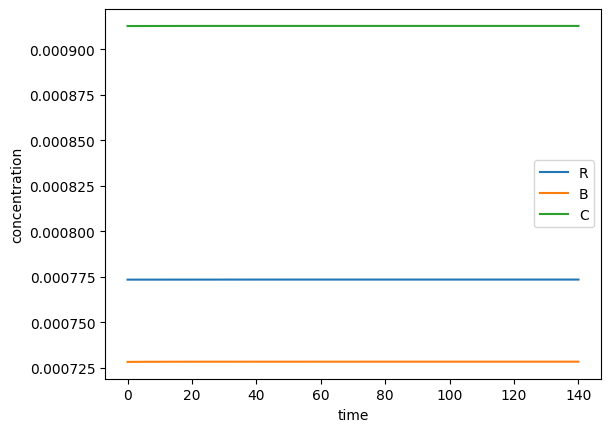

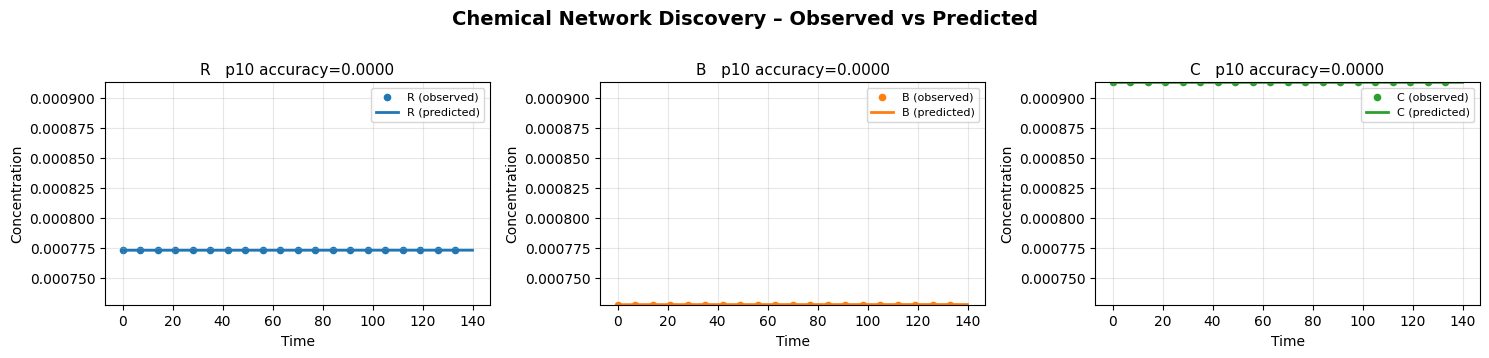

In [5]:
result = checkFit(278, num_point=1000)

## BioModels 538

Poly_degree: 1, threshold: 0.01


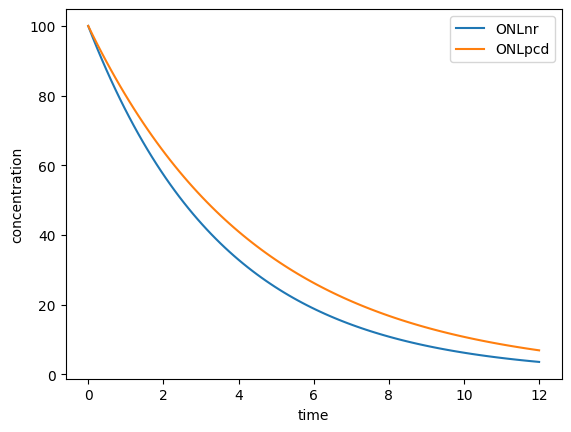

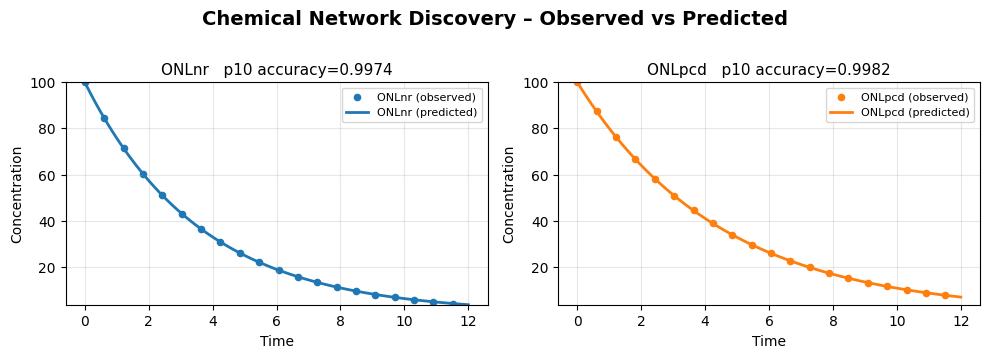

In [6]:
checkFit(538, threshold=0.01)

## BioModels 677

Poly_degree: 1, threshold: 0.001


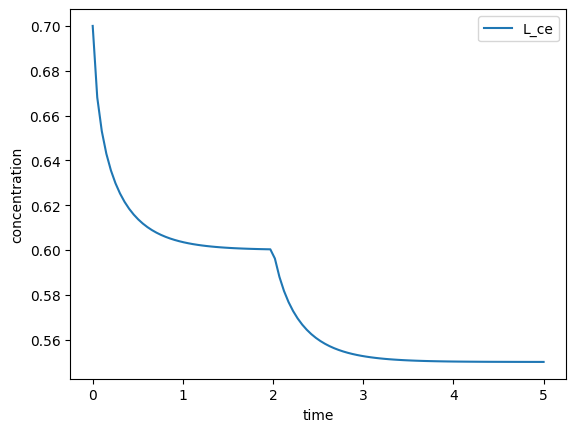

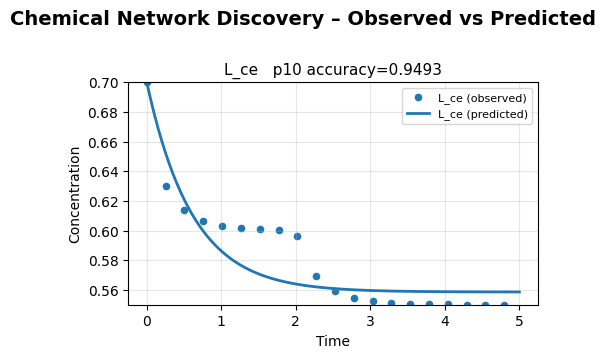

In [7]:
checkFit(677, threshold=0.001)

# Analysis of fits

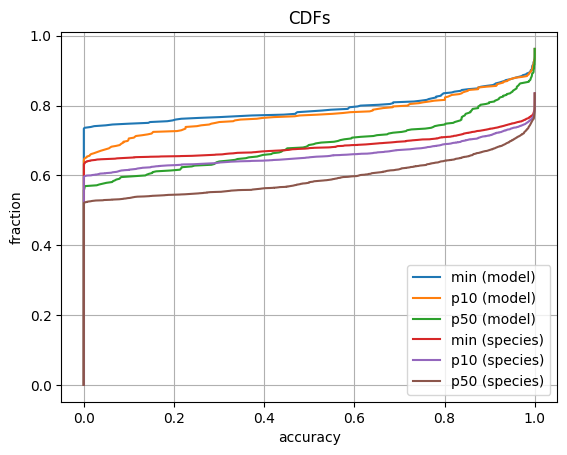

In [12]:
PATH = os.path.join(cn.DATA_DIR, "linear_predictor_scores-0.001.csv")
#PATH = os.path.join(cn.DATA_DIR, "linear_predictor_scores_1" + ".csv")
score = Score.deserialize(PATH)
SCORE_DF = score.score_df
score.plotCDF(["min", "p10", "p50"])

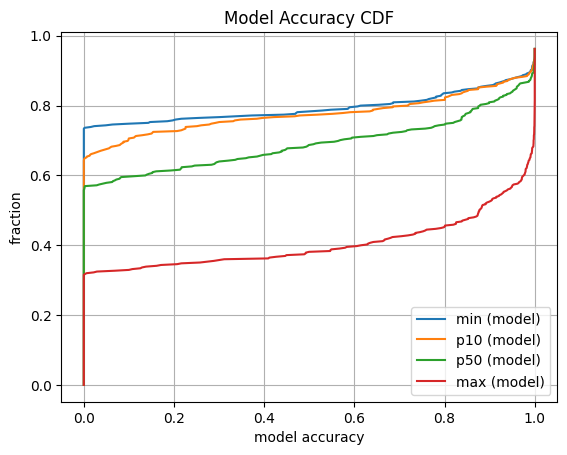

In [9]:
np.sum(score.score_df['aggregation_type'] == "model"), np.sum(score.score_df['aggregation_type'] != "model")
# atol = 1e-2
_ = score.plotCDF(["min", "p10", "p50", "max"], xlabel= "model accuracy", title="Model Accuracy CDF", is_plot_species=False)

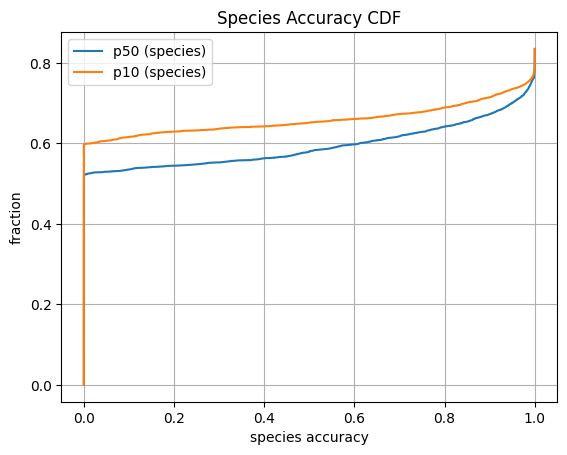

In [10]:
_ = score.plotCDF(["p50", "p10"], xlabel="species accuracy", title="Species Accuracy CDF", is_plot_model=False)

**Doesn't make sense**
* Not sure that I know how to interpret this plot in terms of accuracy of predictions

### Analysis of more accurate models

BIOMD0000000279

Poly_degree: 1, threshold: 0.001


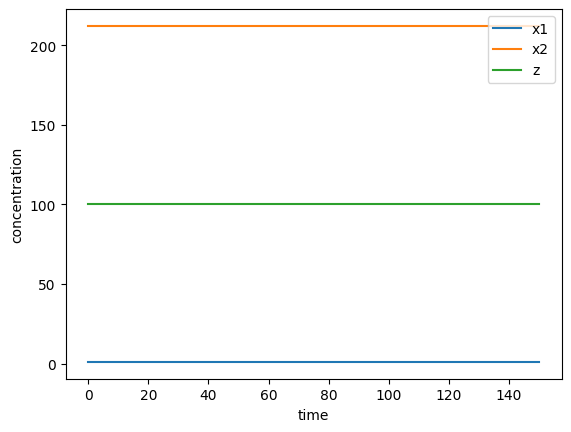

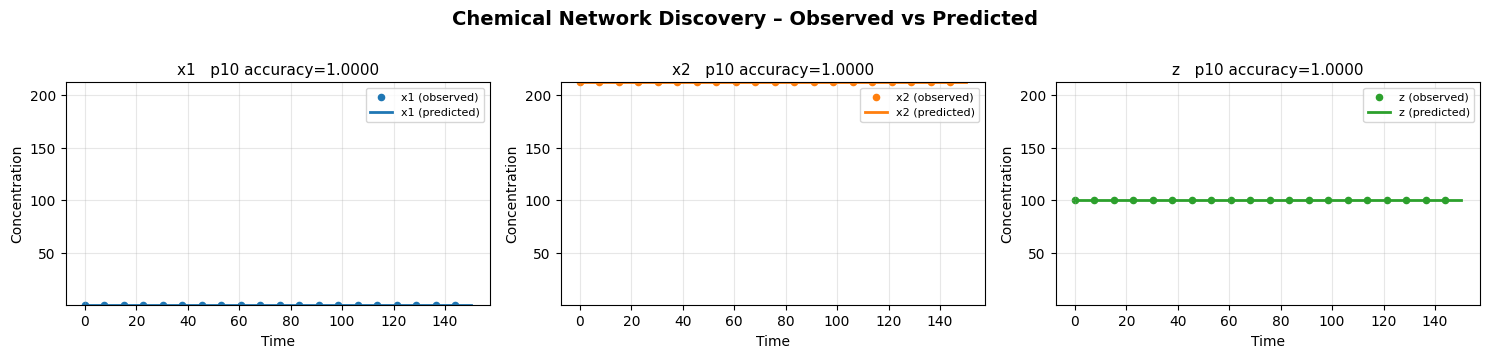

BIOMD0000000342

Poly_degree: 1, threshold: 0.001


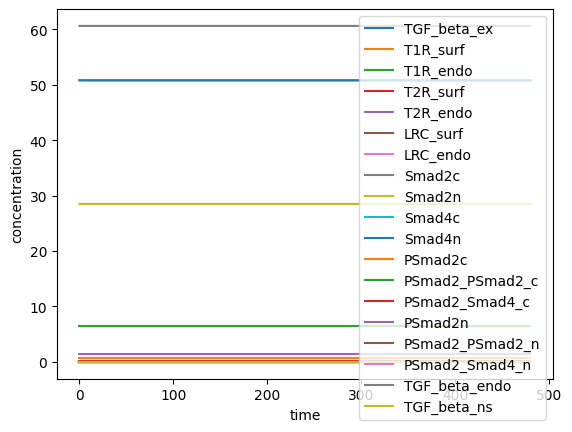

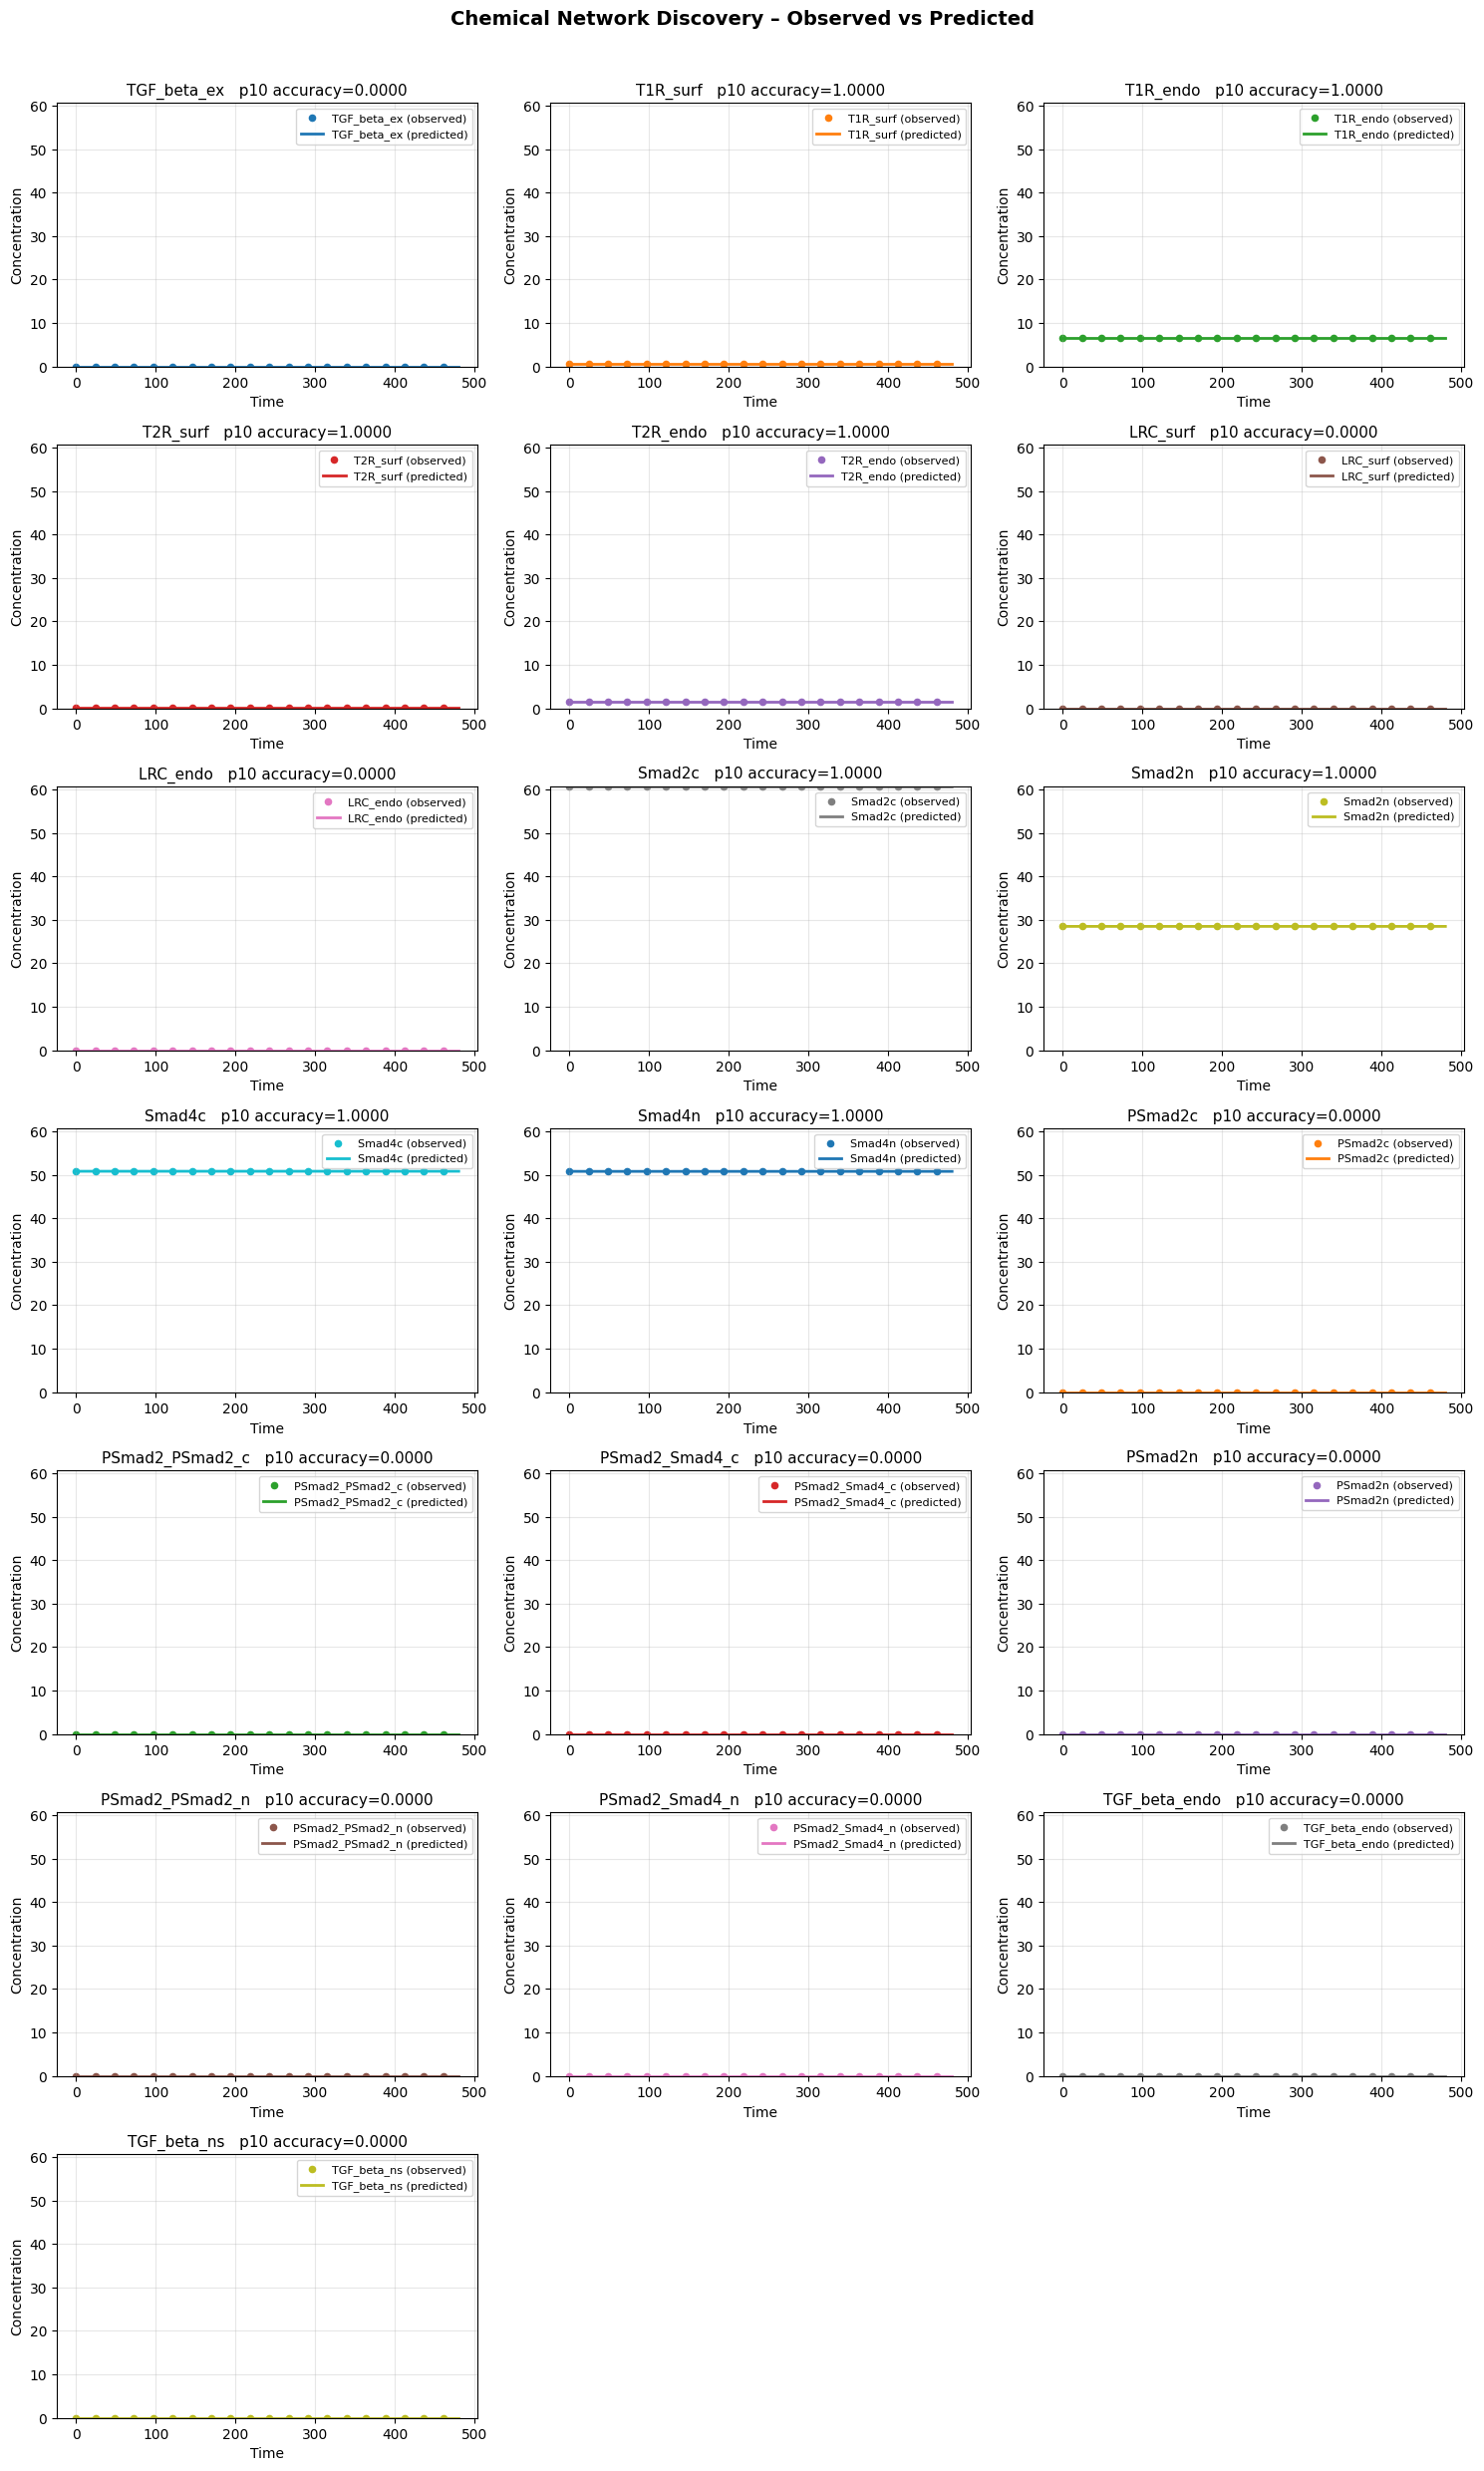

BIOMD0000000538

Poly_degree: 1, threshold: 0.001


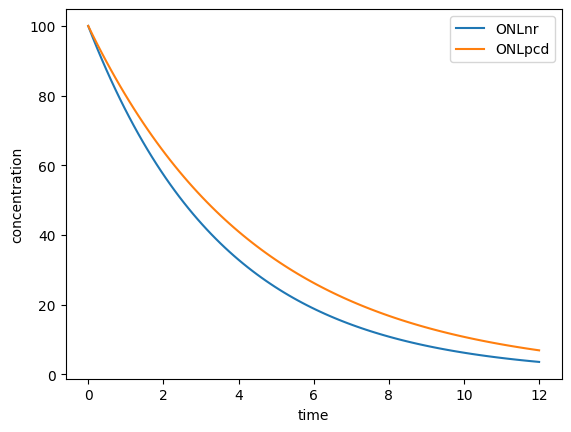

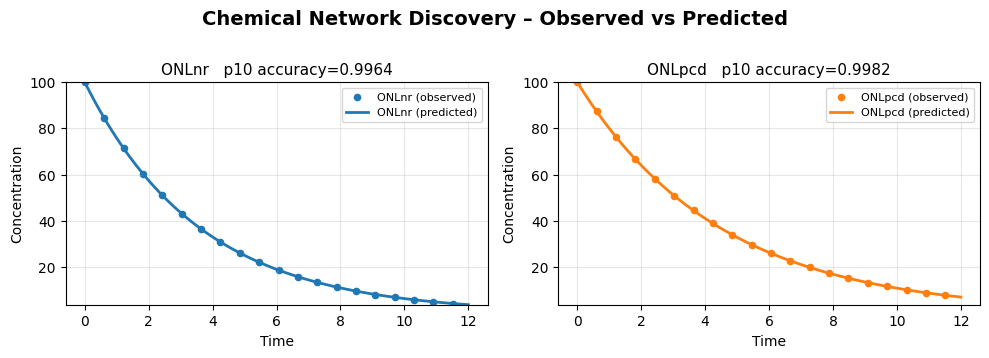

BIOMD0000000670

Poly_degree: 1, threshold: 0.001


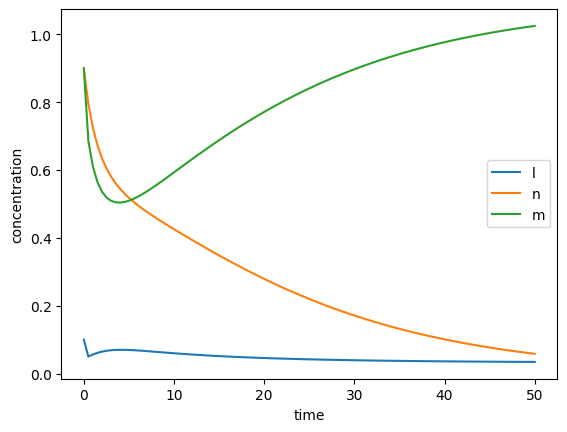

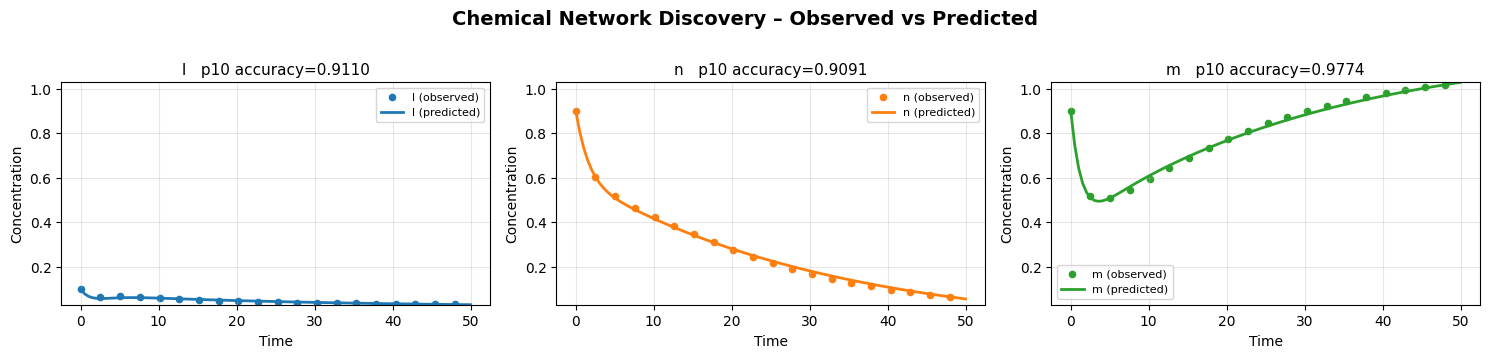

BIOMD0000000676

Poly_degree: 1, threshold: 0.001


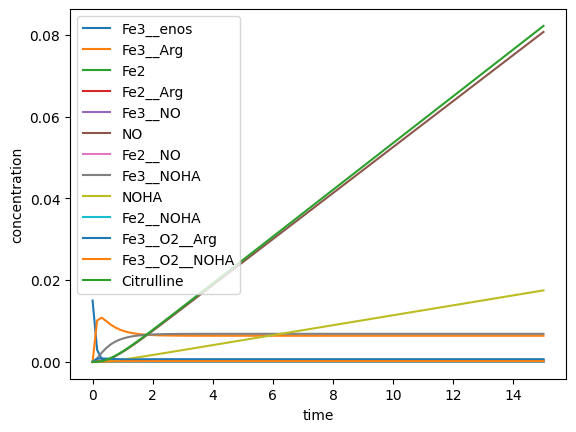

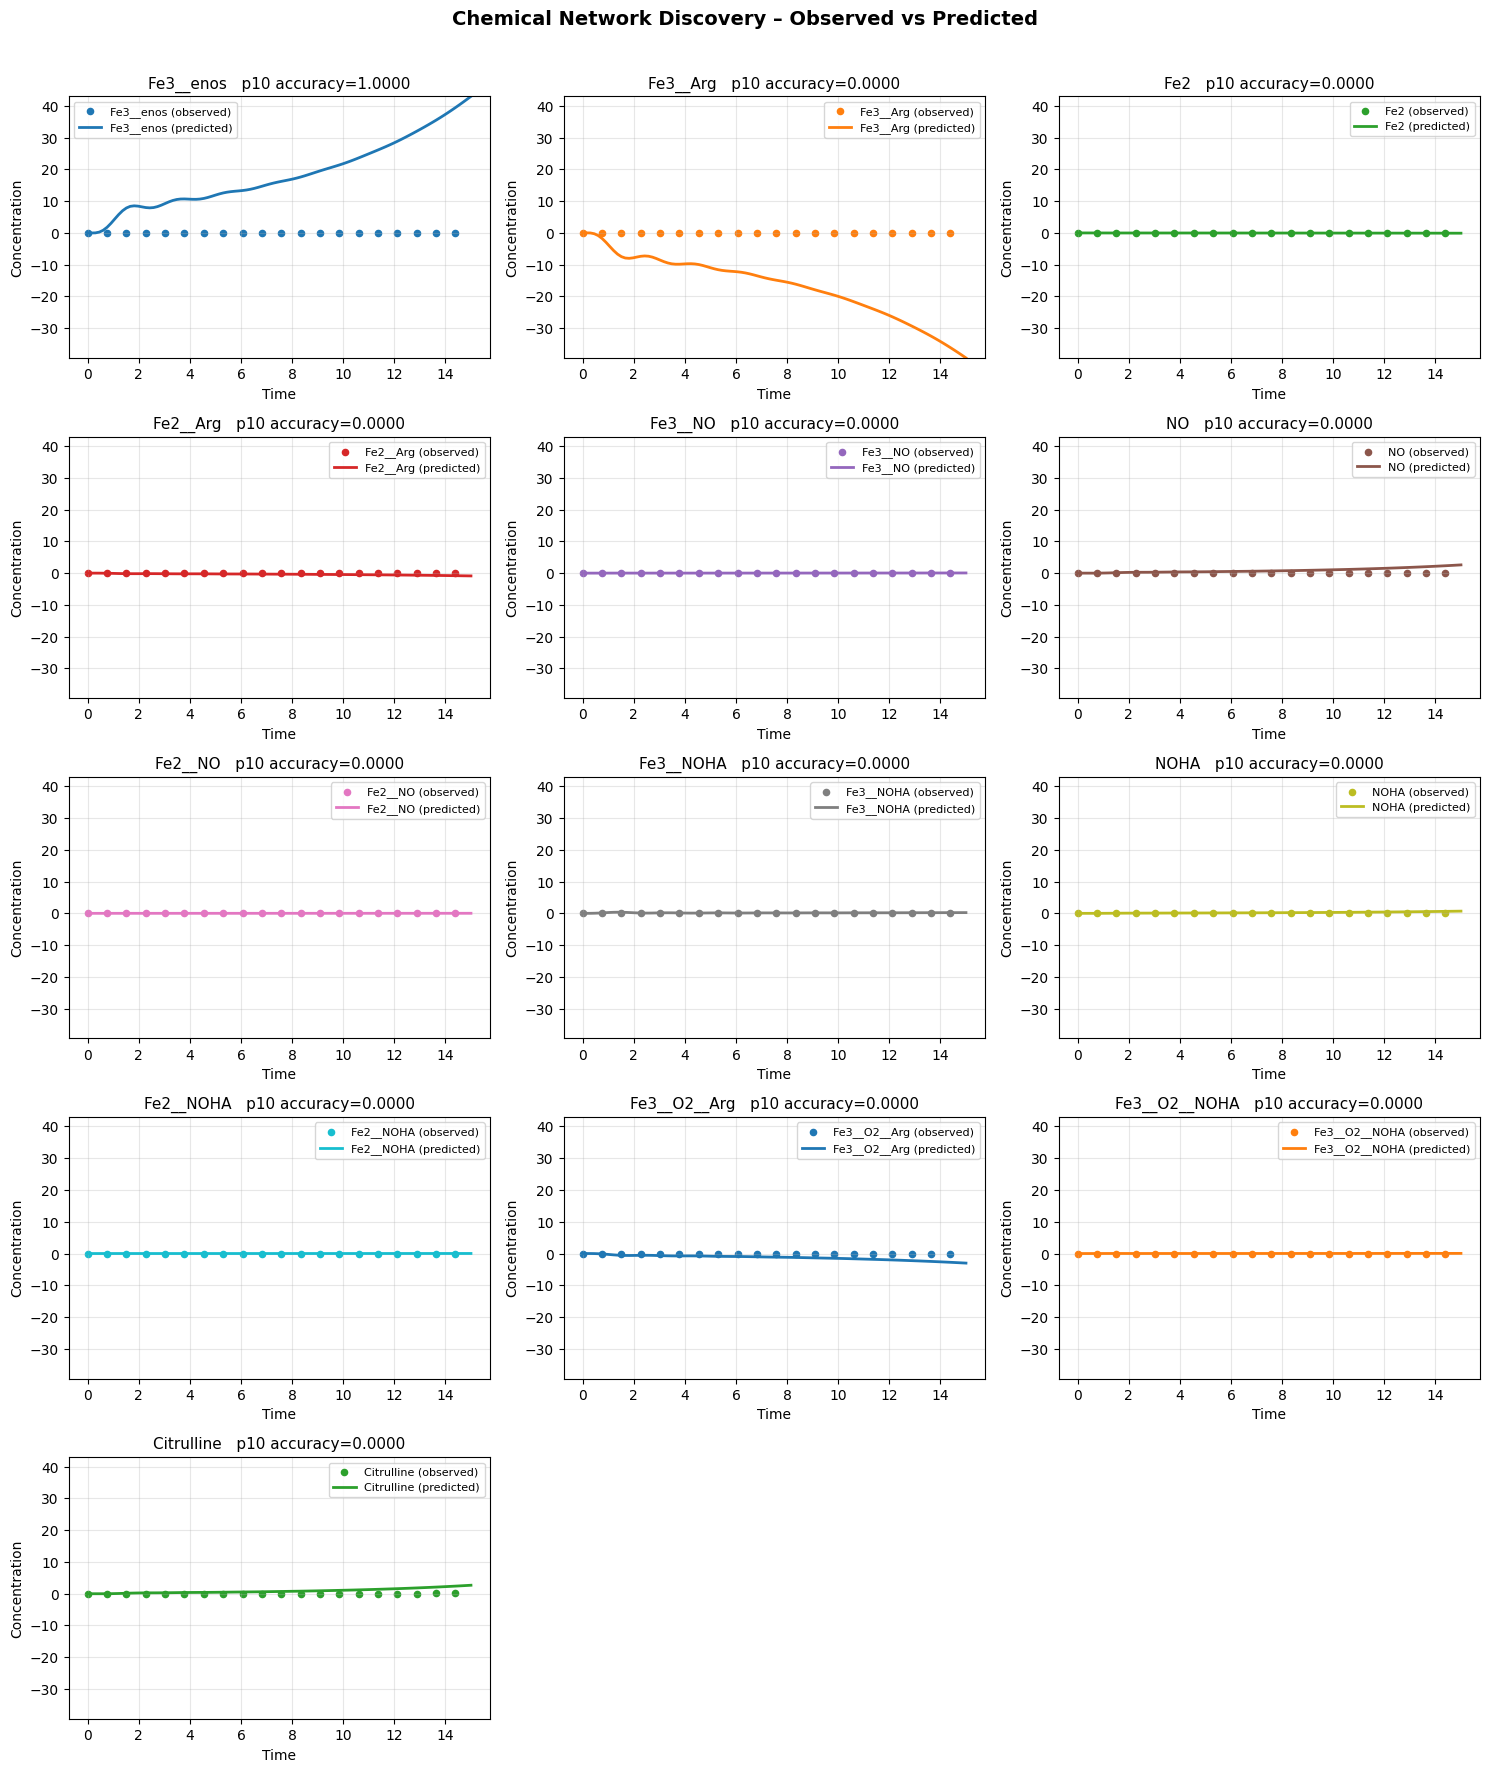

BIOMD0000000677

Poly_degree: 1, threshold: 0.001


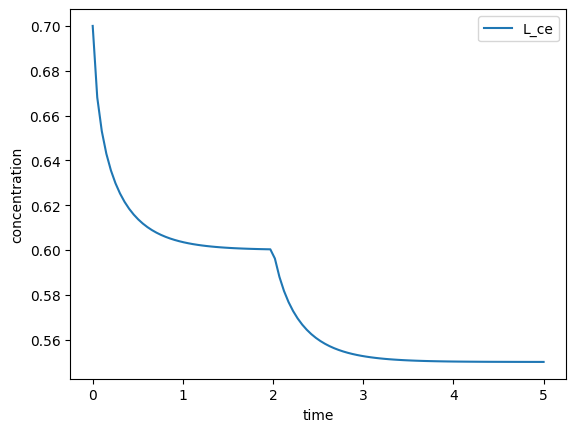

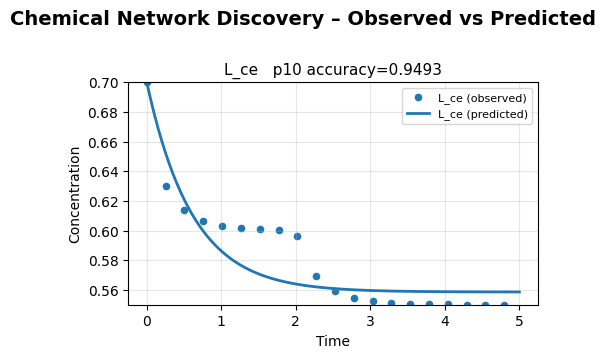

BIOMD0000000692

Poly_degree: 1, threshold: 0.001


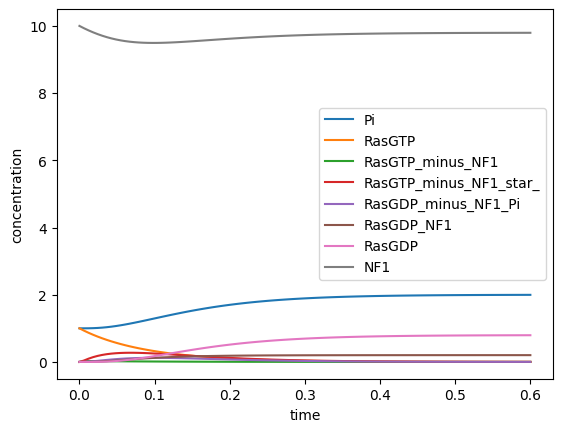

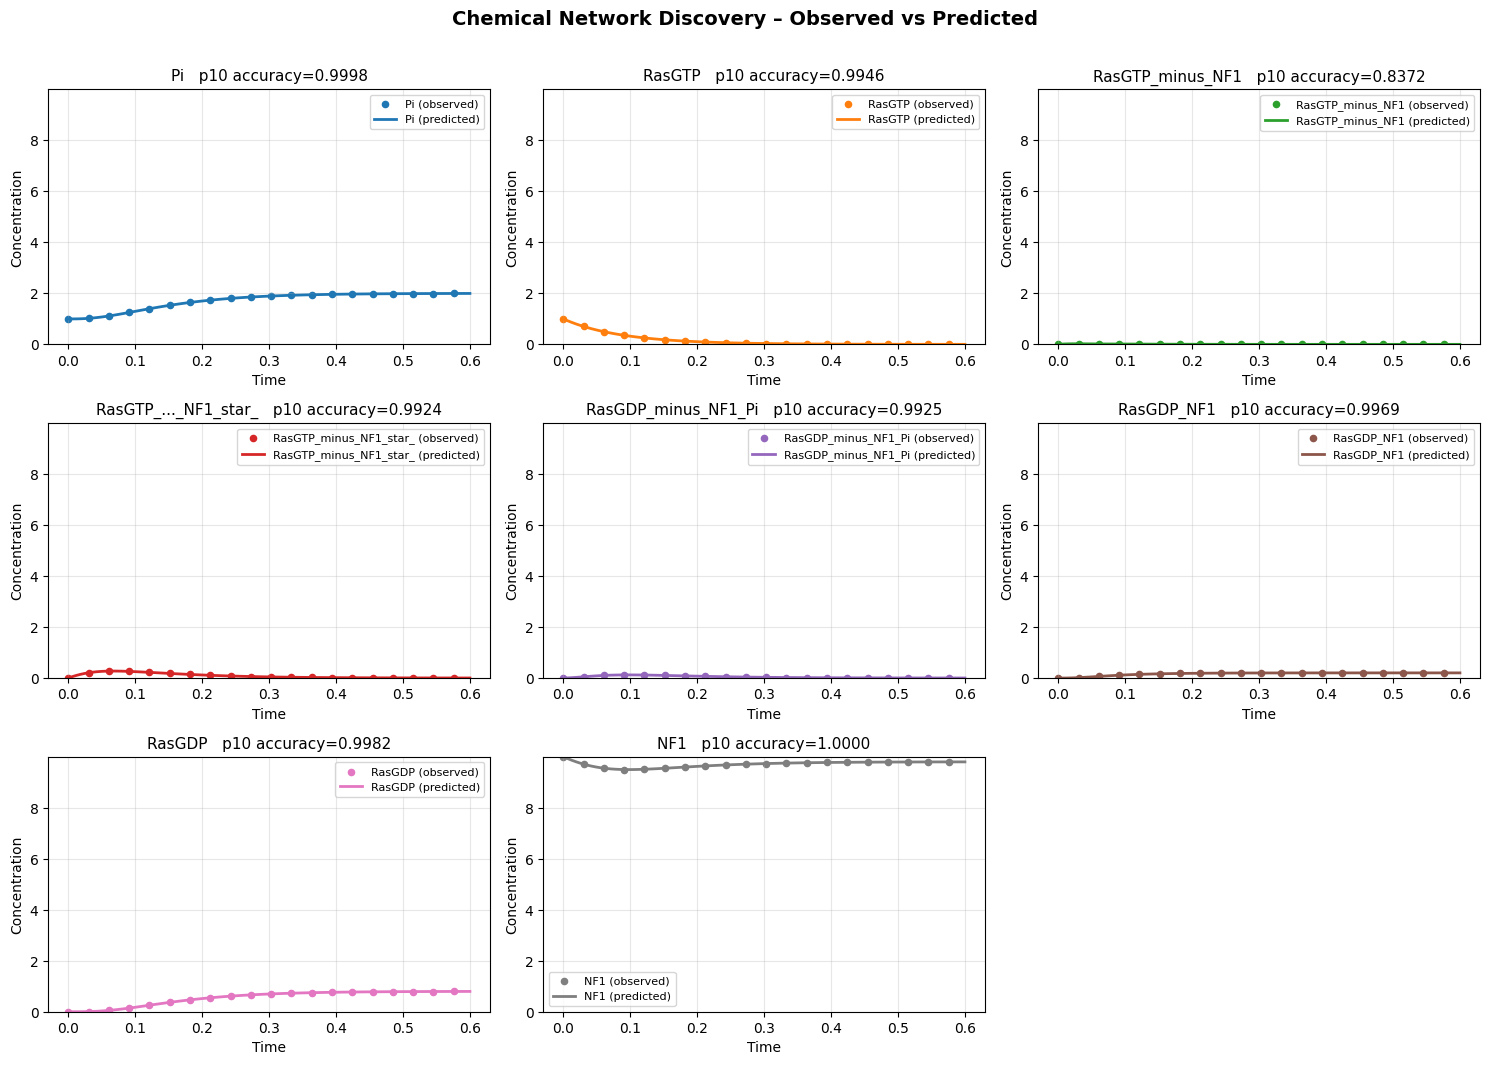

BIOMD0000000715

Poly_degree: 1, threshold: 0.001


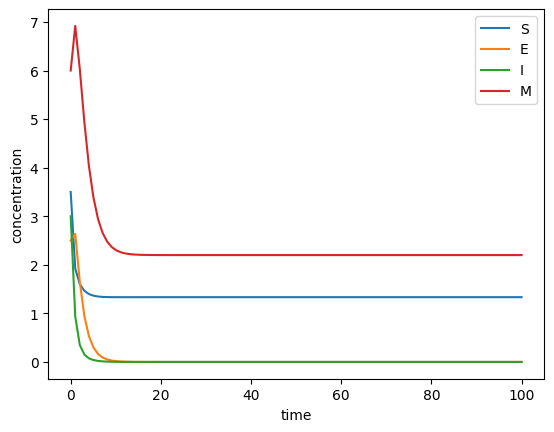

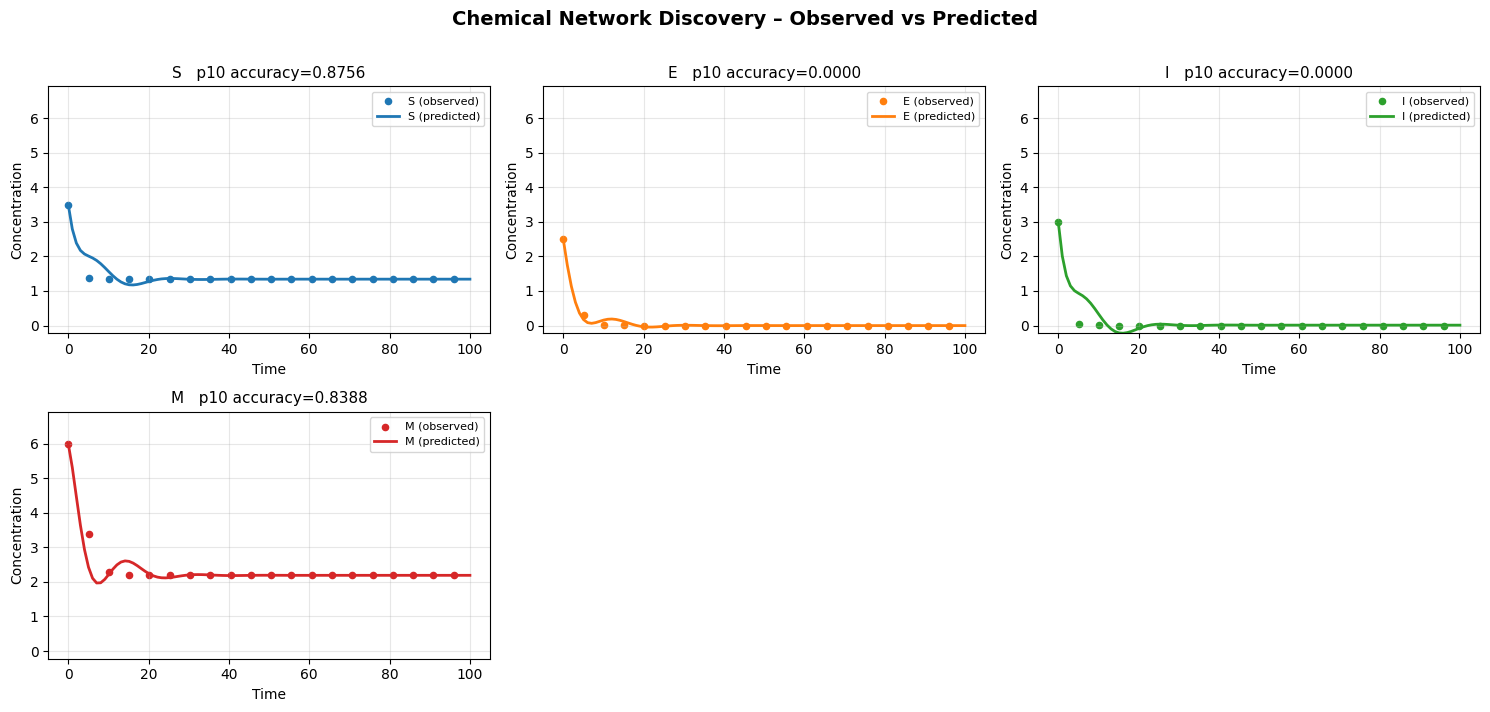

BIOMD0000000734

Poly_degree: 1, threshold: 0.001


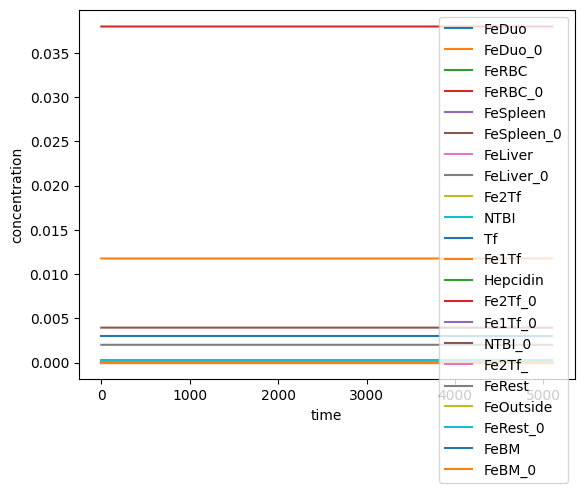

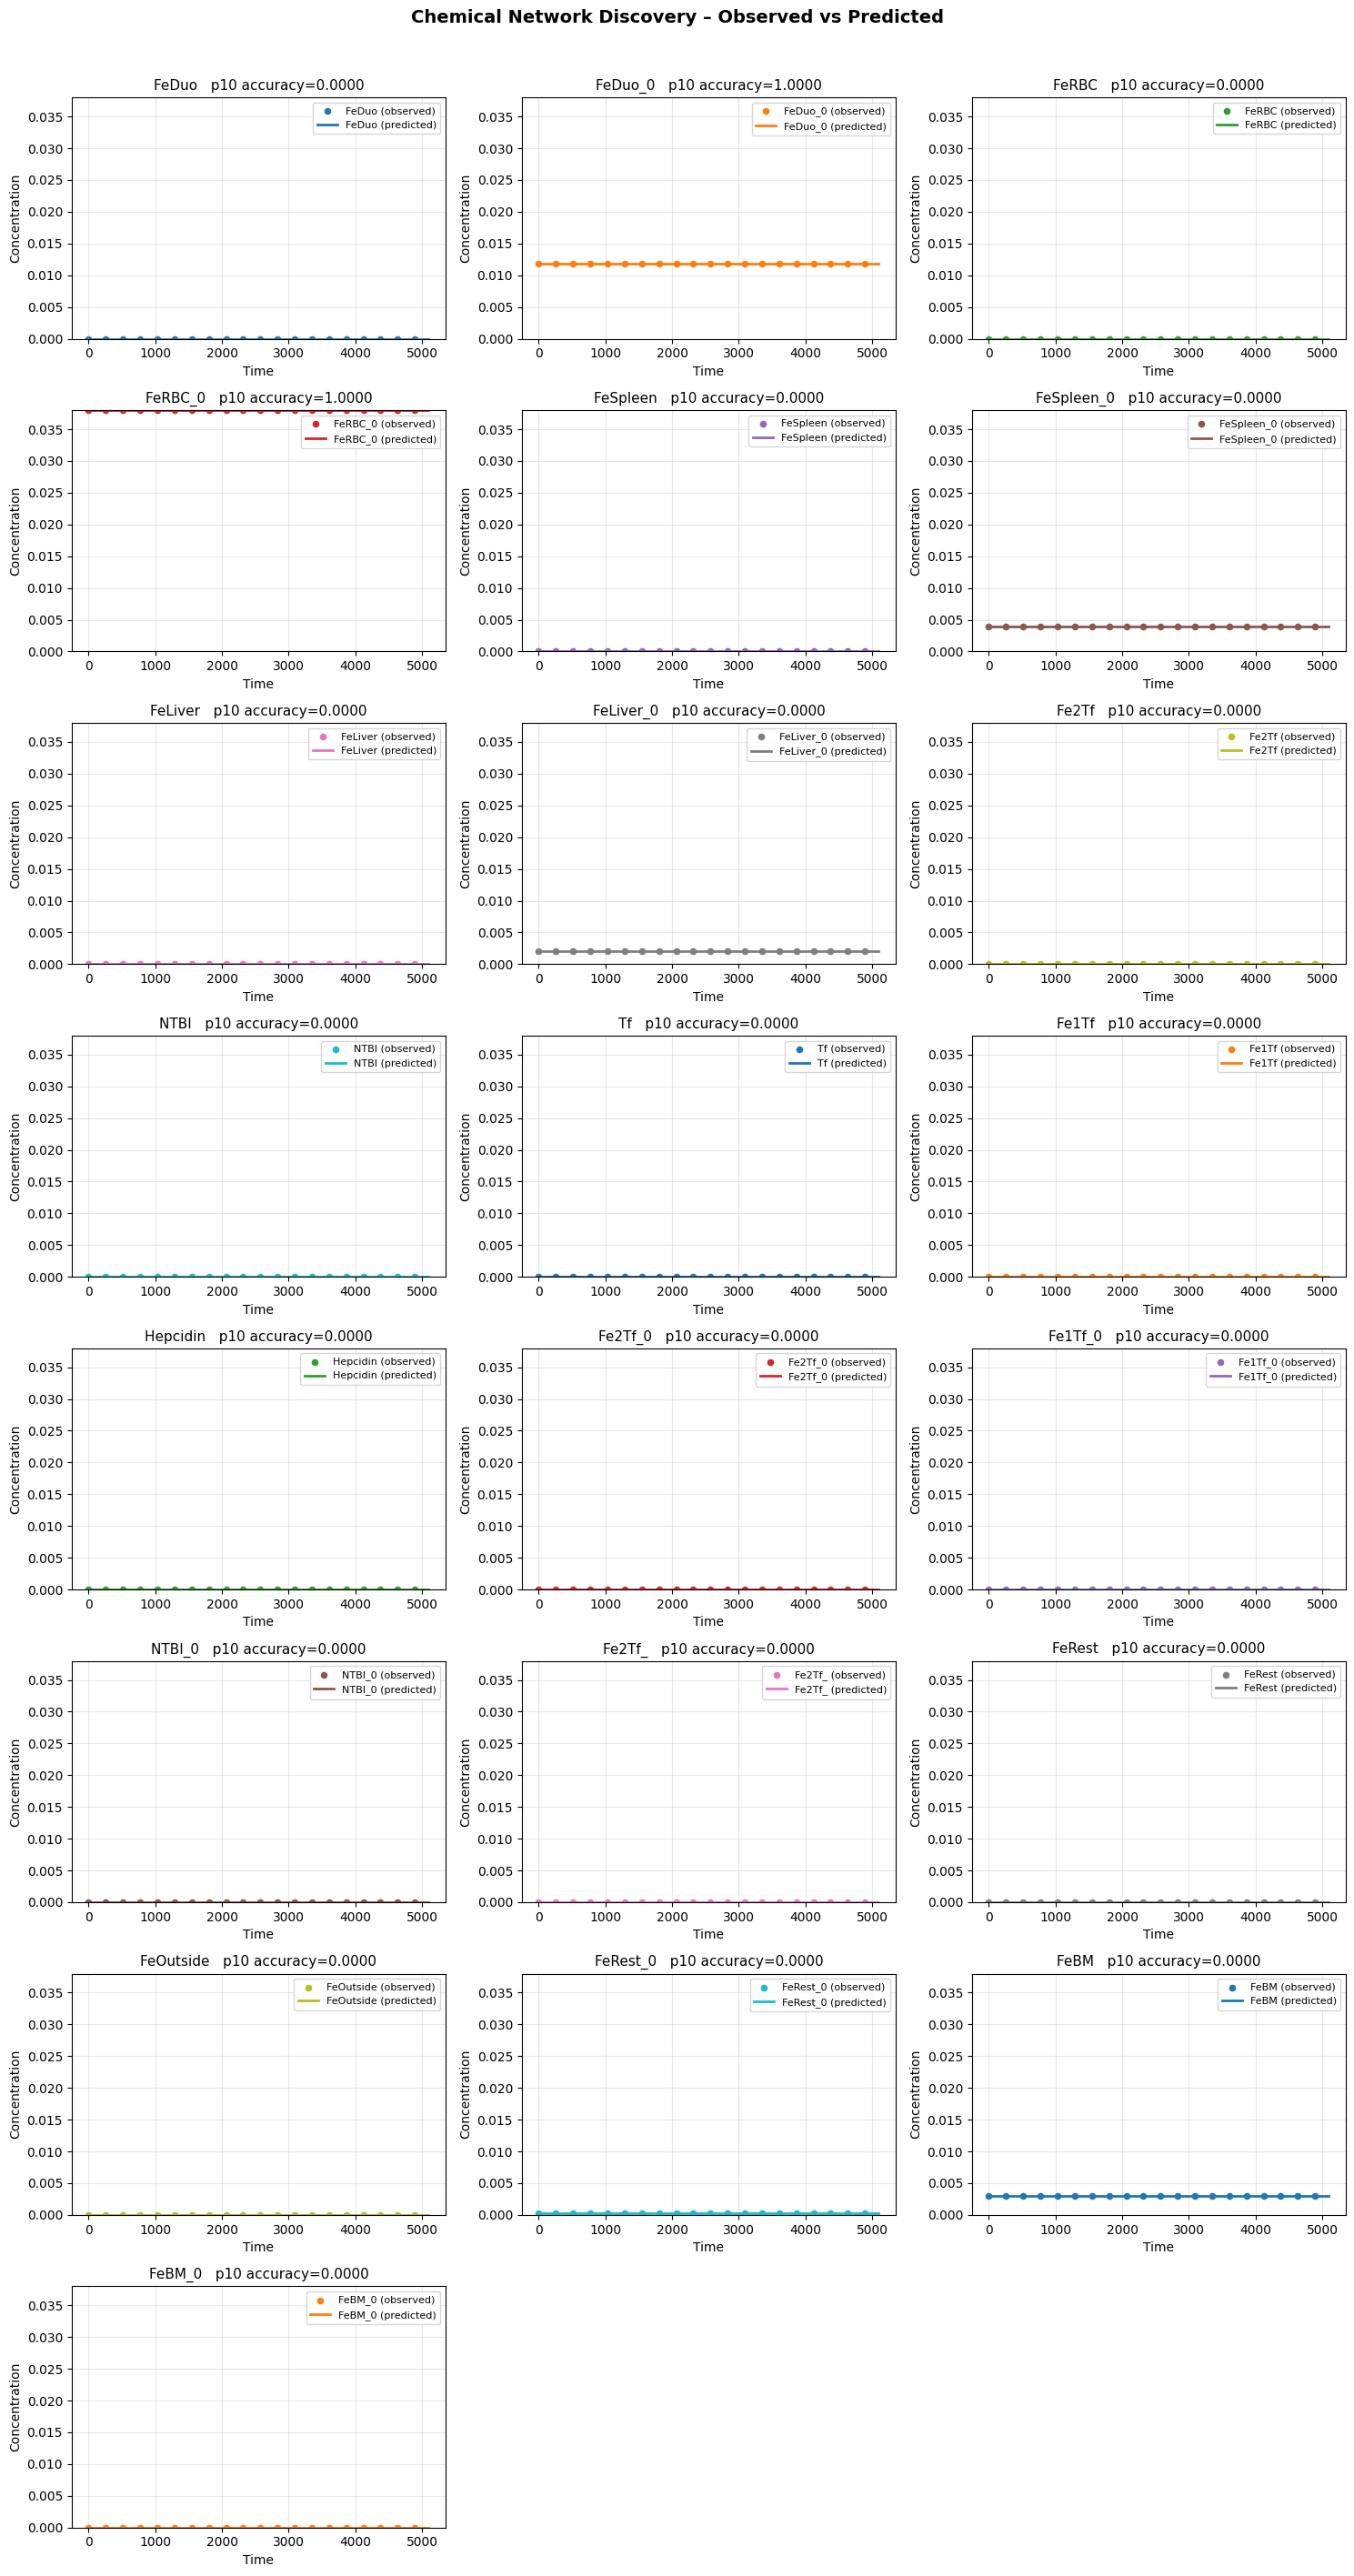

BIOMD0000000736

Poly_degree: 1, threshold: 0.001


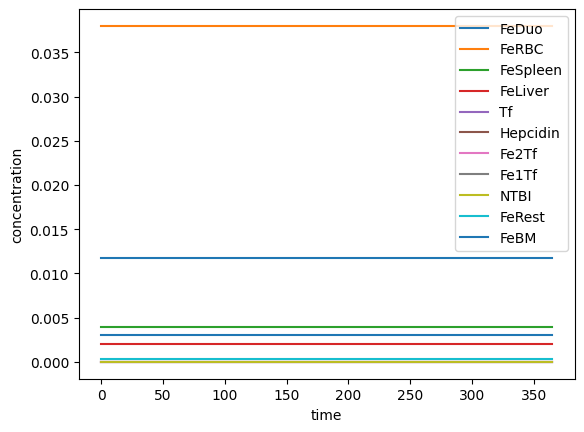

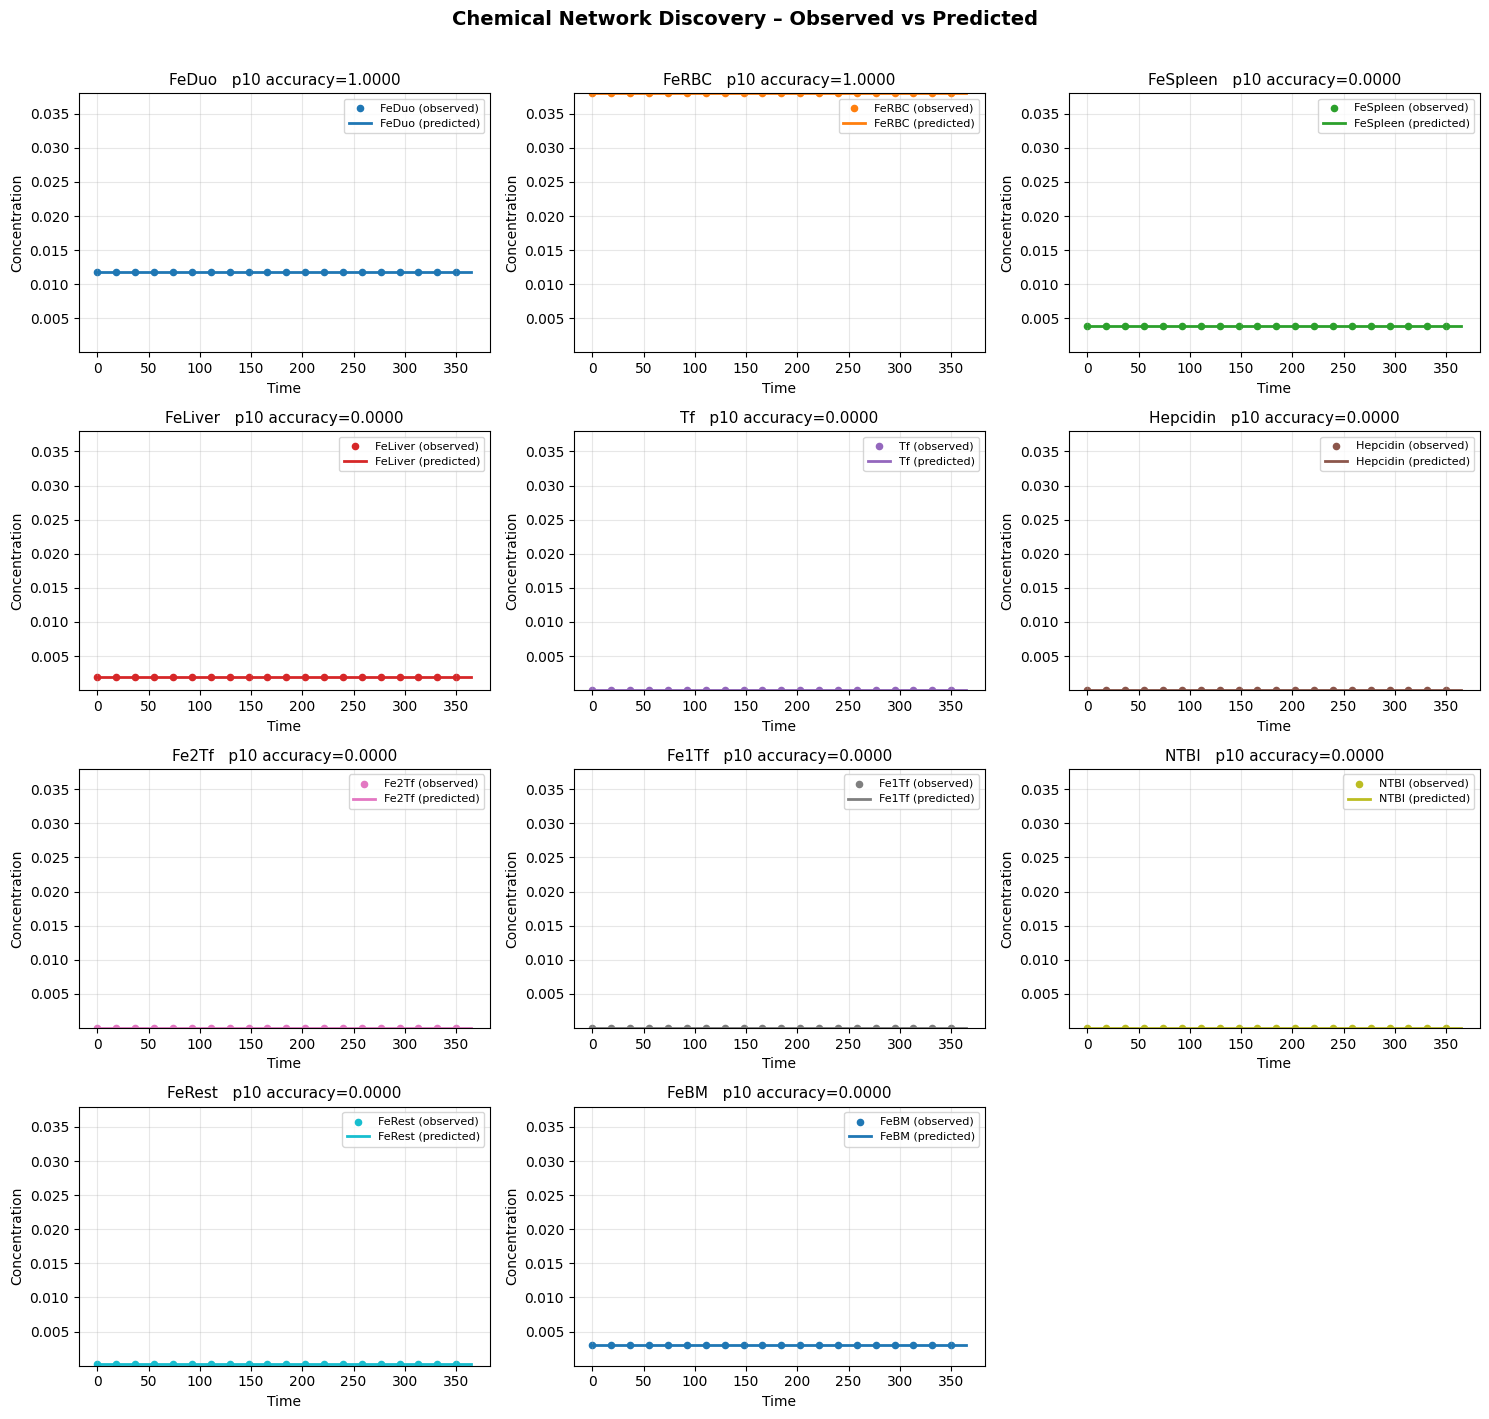

BIOMD0000000745

Poly_degree: 1, threshold: 0.001


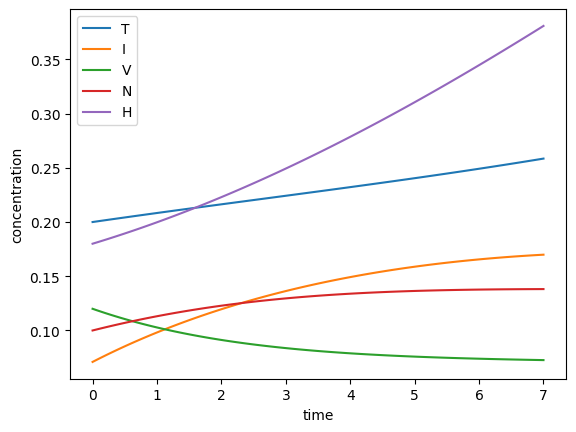

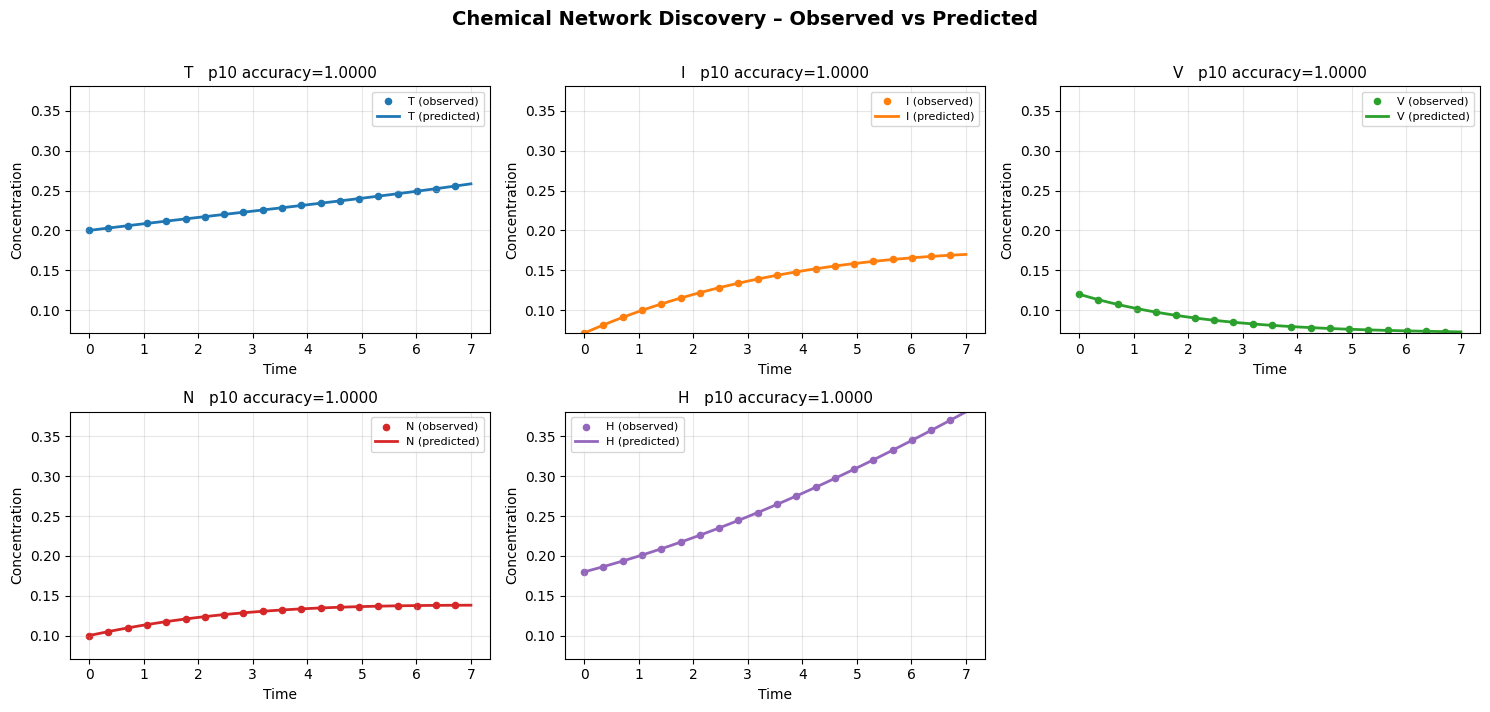

BIOMD0000000753

Poly_degree: 1, threshold: 0.001


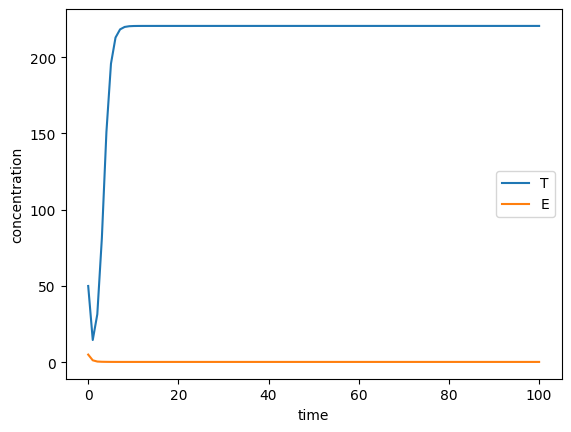

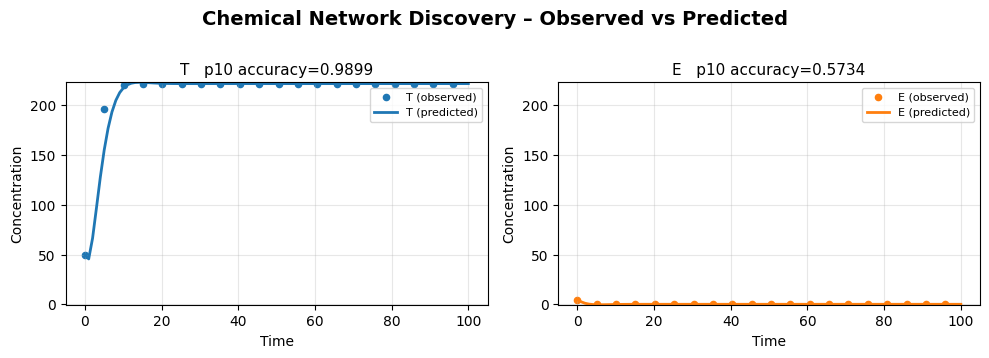

BIOMD0000000775

Poly_degree: 1, threshold: 0.001


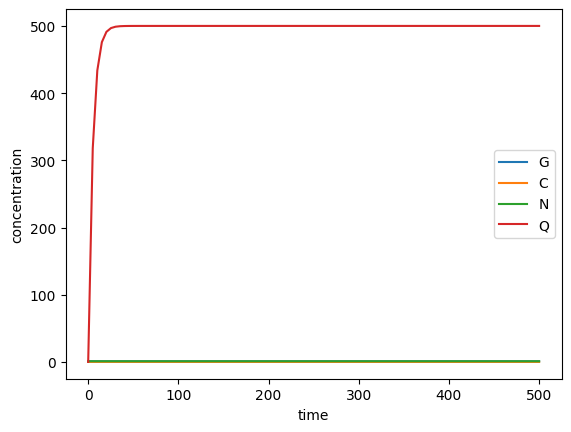

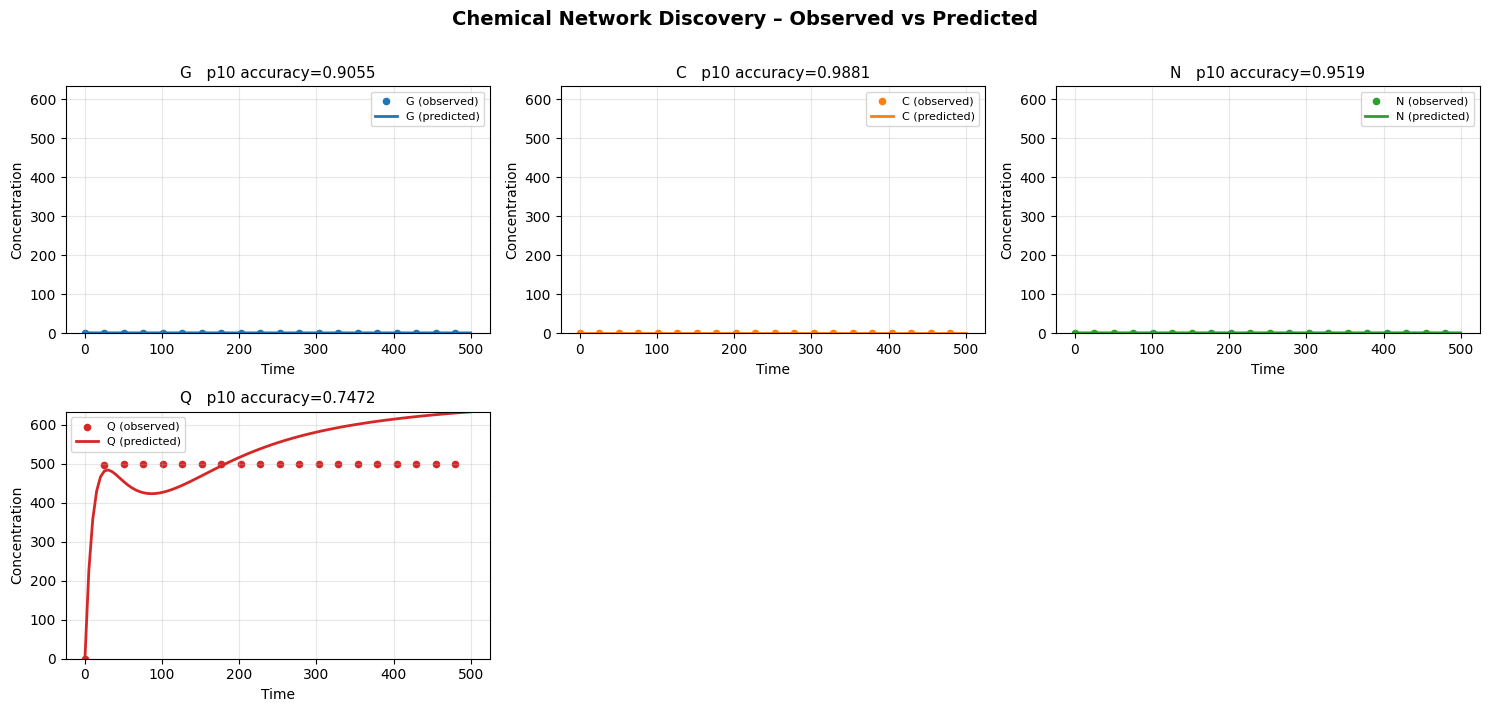

BIOMD0000000782

Poly_degree: 1, threshold: 0.001


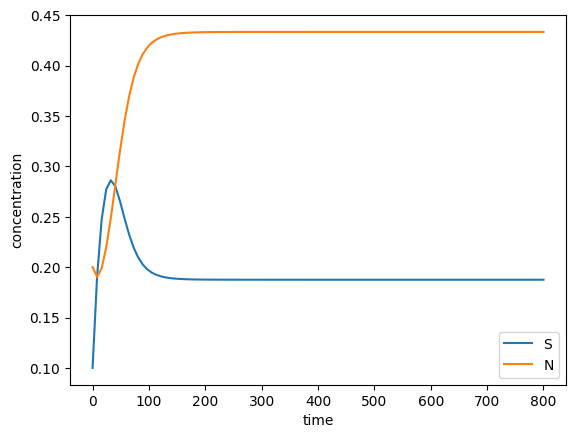

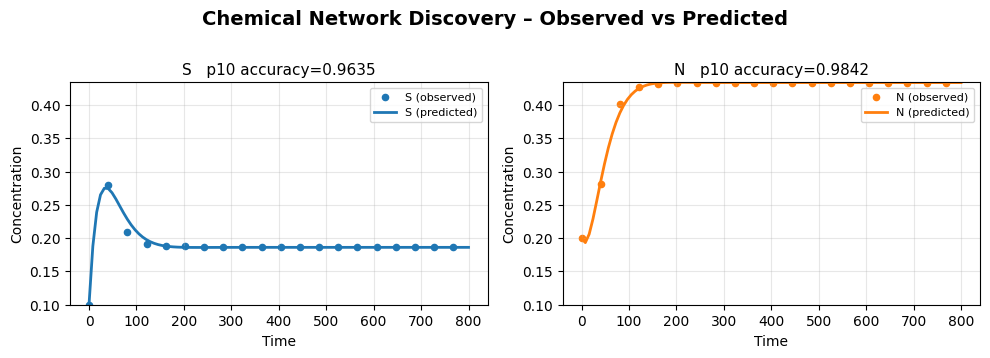

BIOMD0000000799

Poly_degree: 1, threshold: 0.001


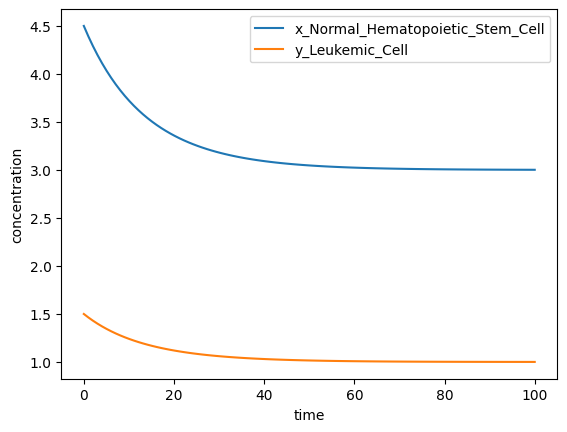

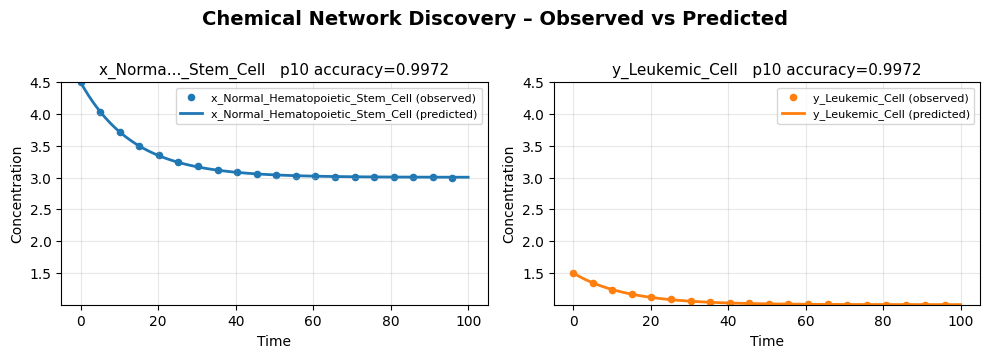

BIOMD0000000802

Poly_degree: 1, threshold: 0.001


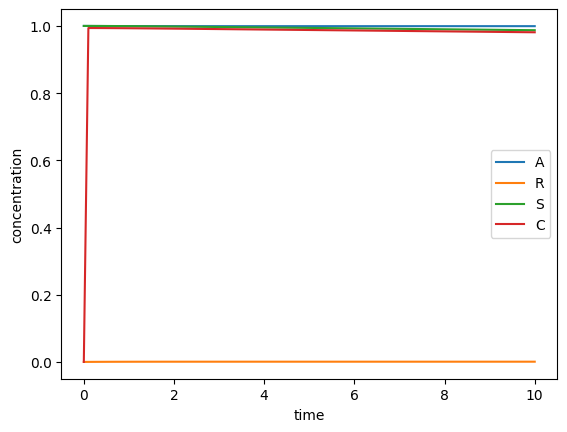

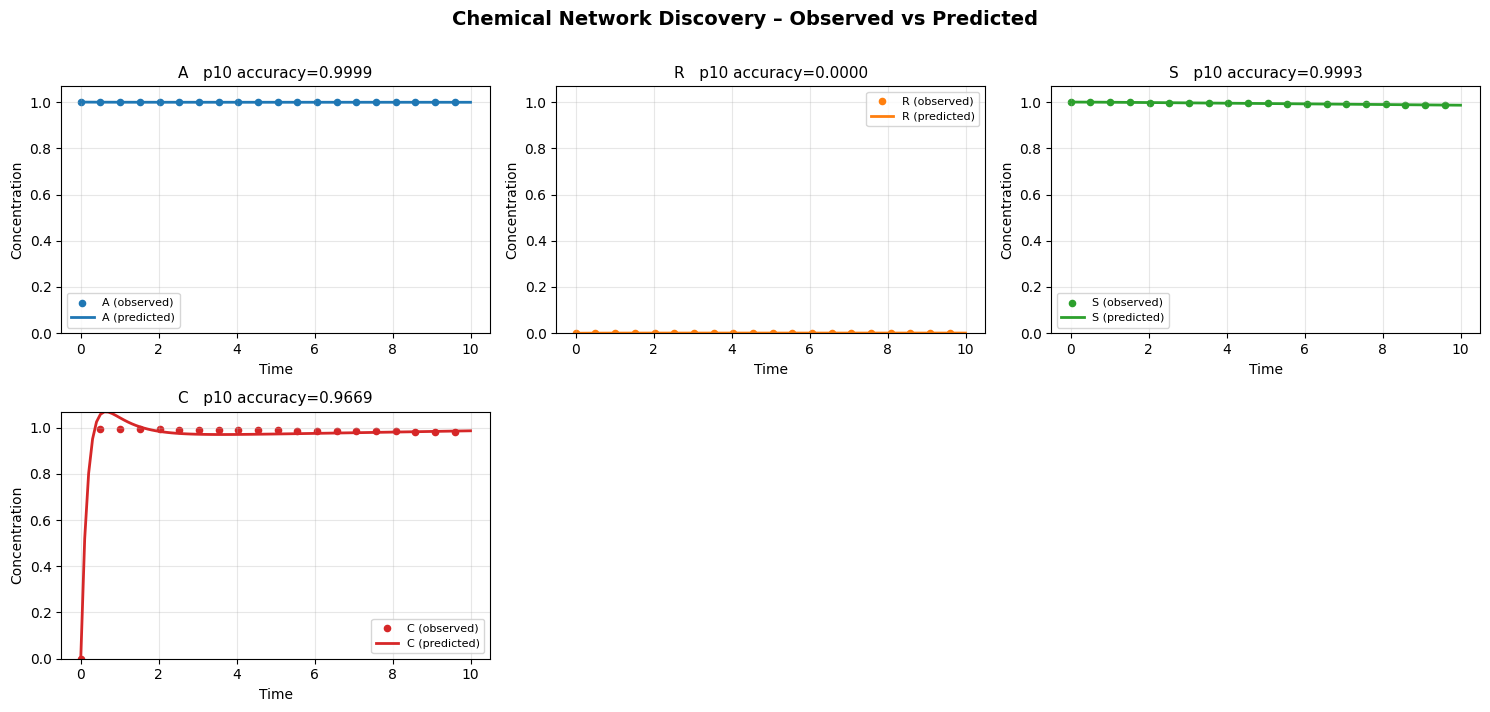

BIOMD0000000805

Poly_degree: 1, threshold: 0.001


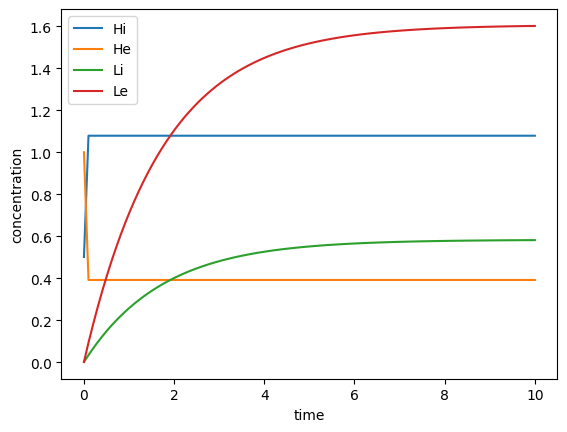

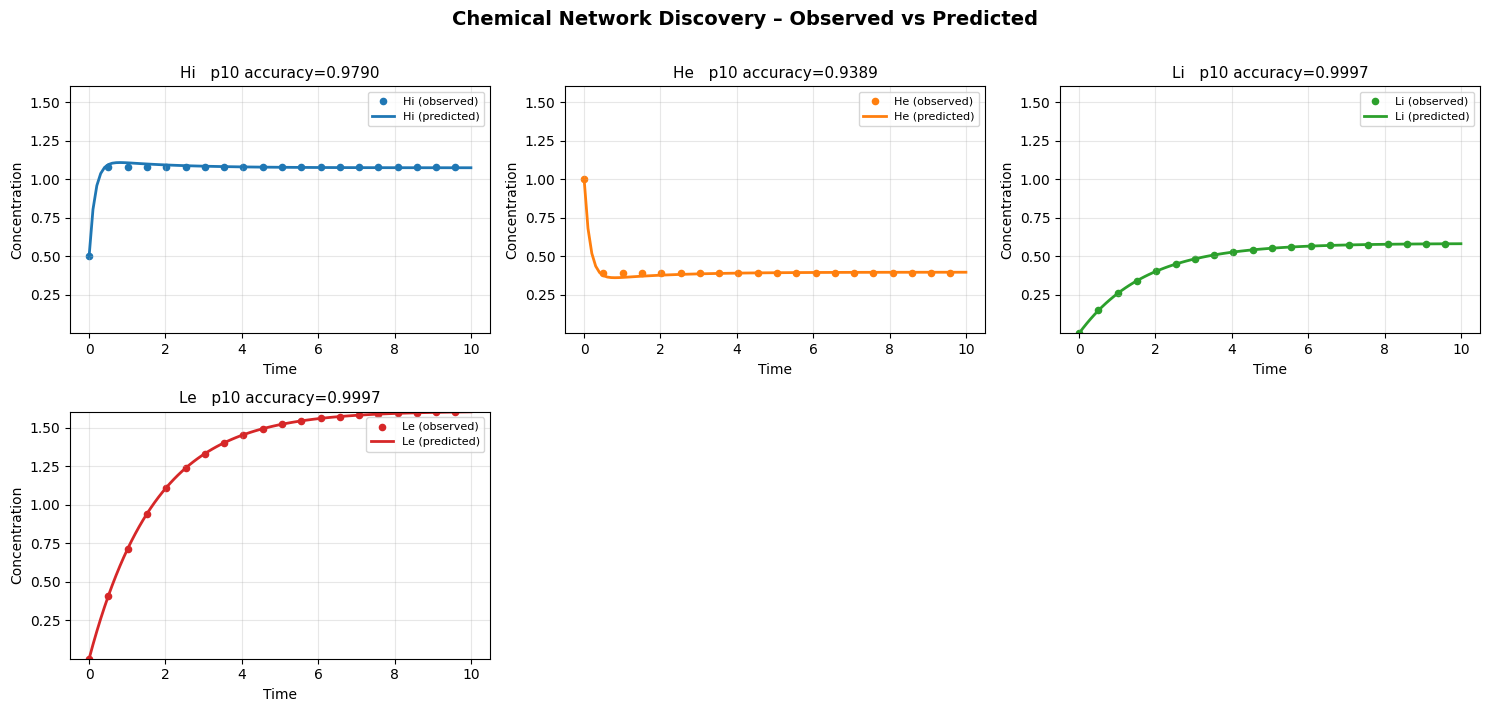

BIOMD0000000807

Poly_degree: 1, threshold: 0.001


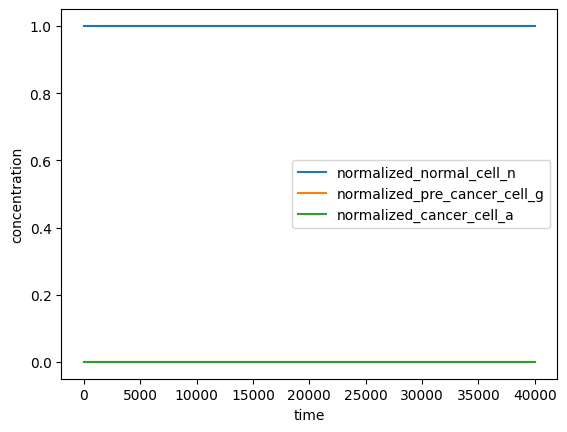

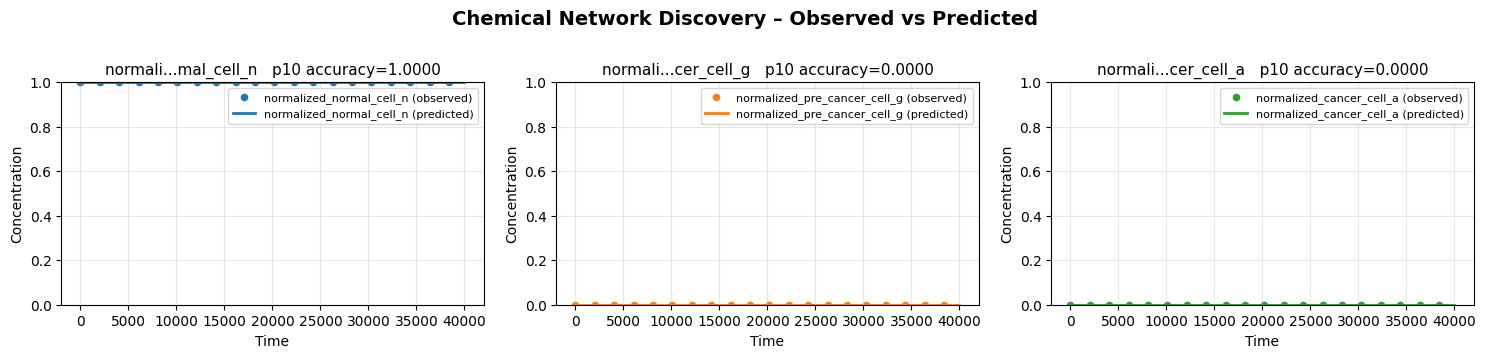

BIOMD0000000814

Poly_degree: 1, threshold: 0.001


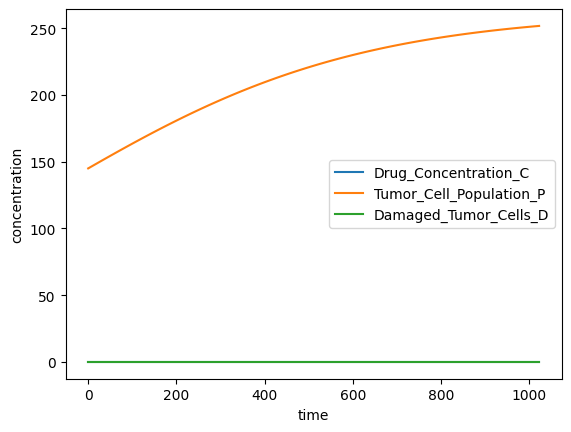

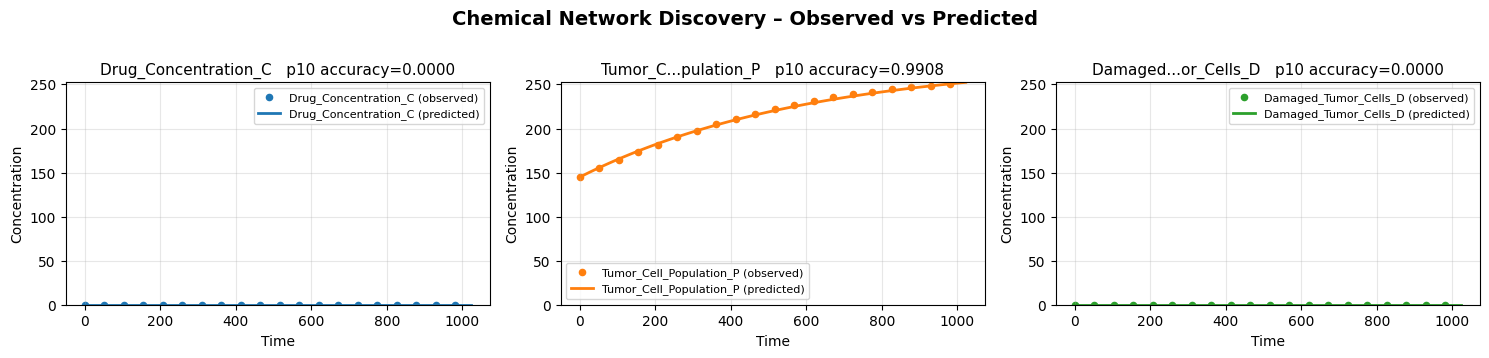

BIOMD0000000816

Poly_degree: 1, threshold: 0.001


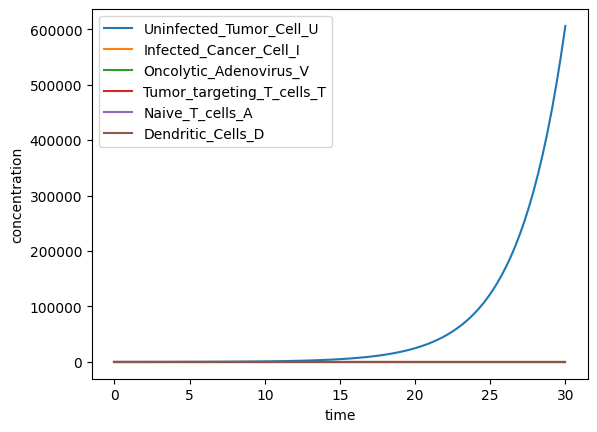

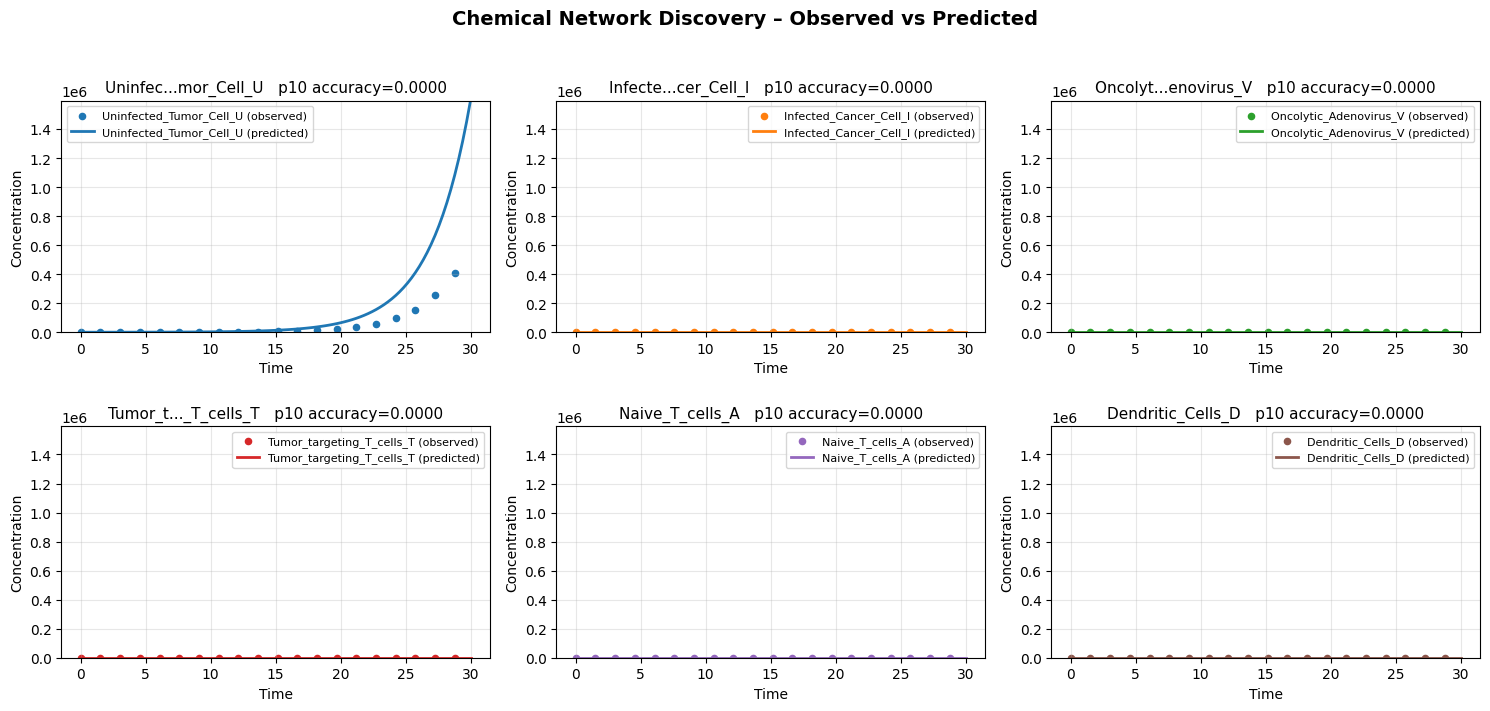

BIOMD0000000817

Poly_degree: 1, threshold: 0.001


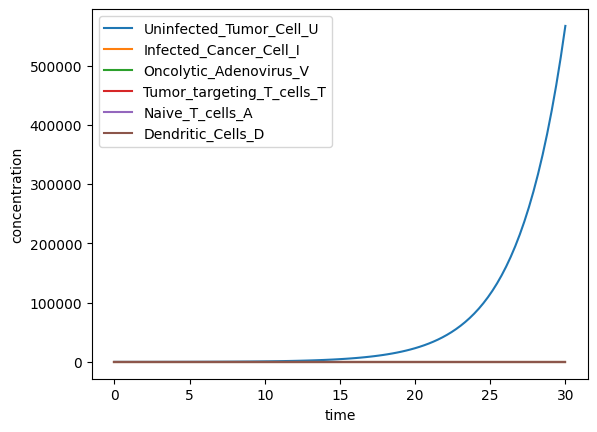

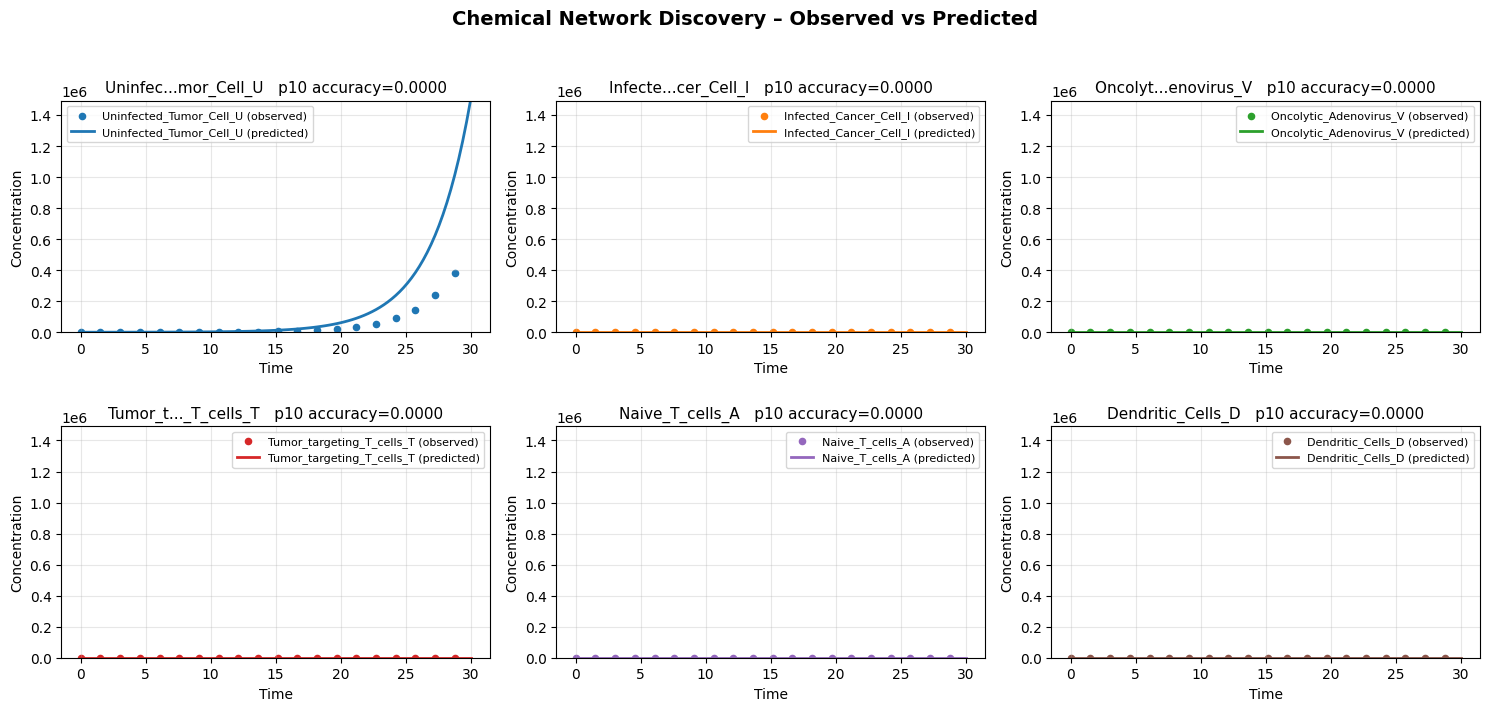

BIOMD0000000828

Poly_degree: 1, threshold: 0.001


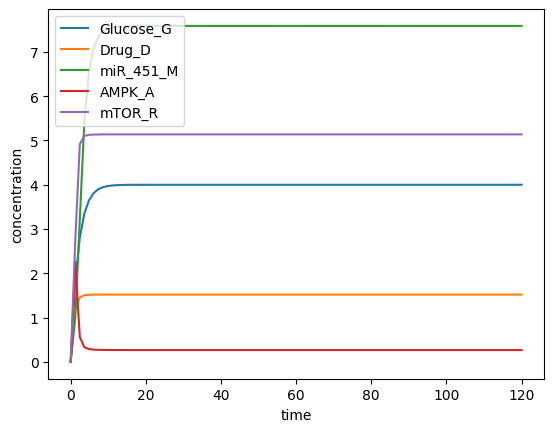

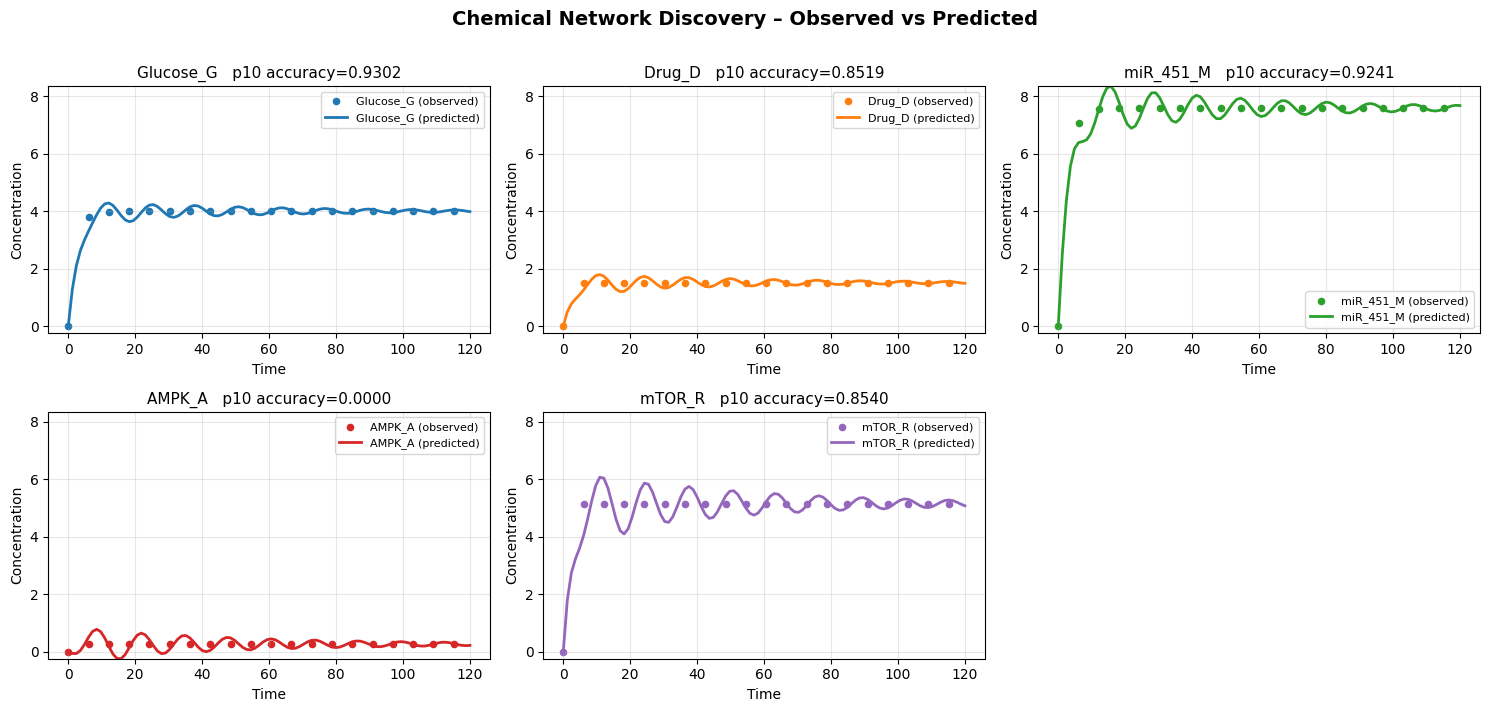

BIOMD0000000830

Poly_degree: 1, threshold: 0.001


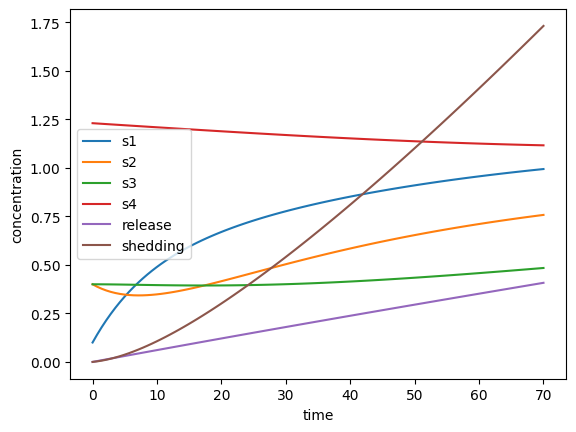

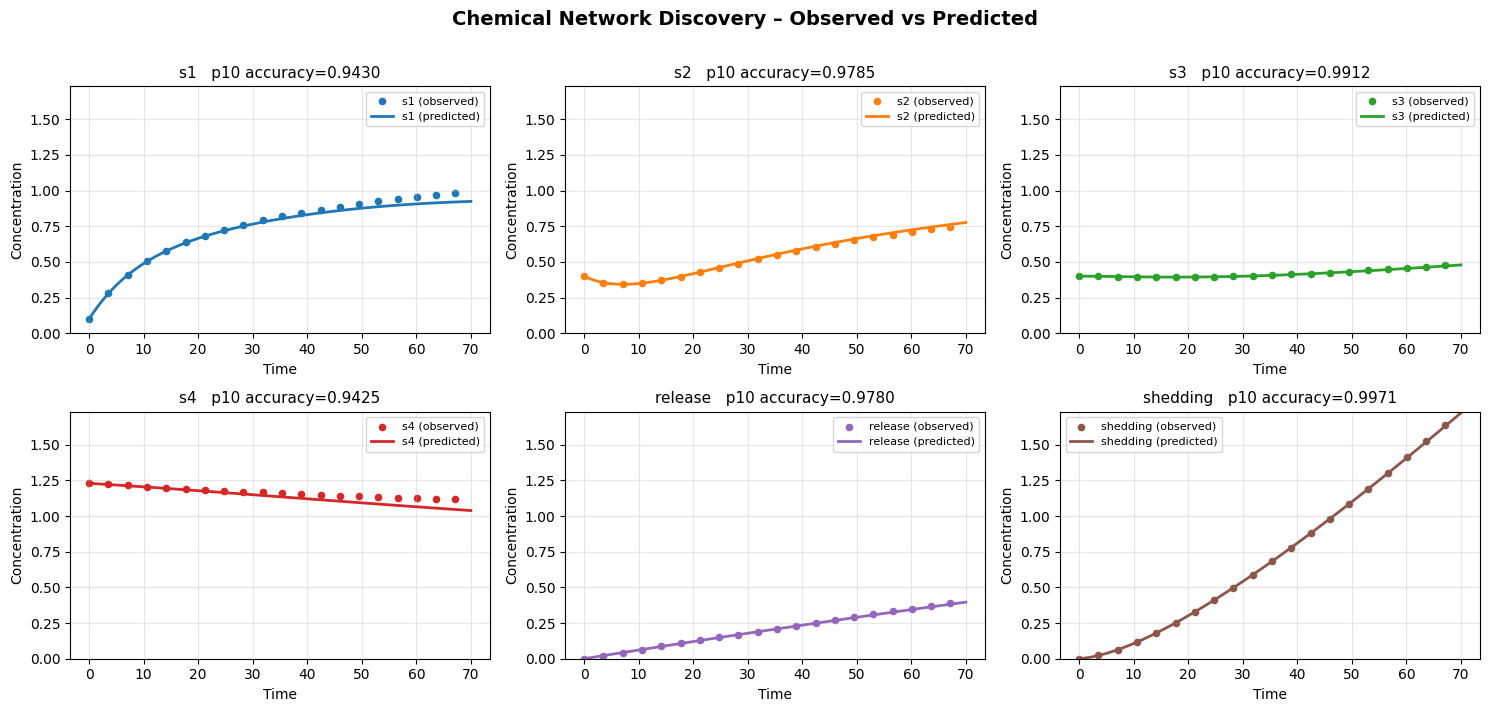

BIOMD0000000840

Poly_degree: 1, threshold: 0.001


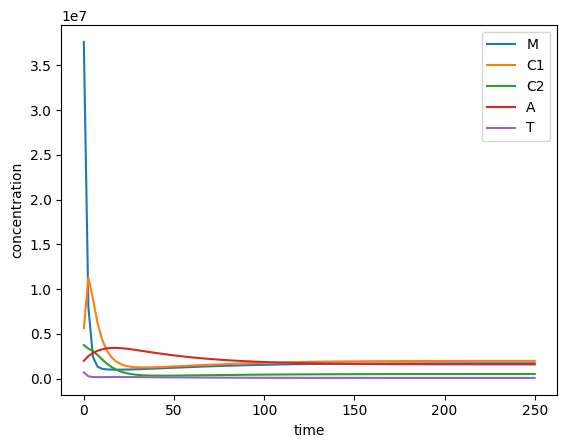

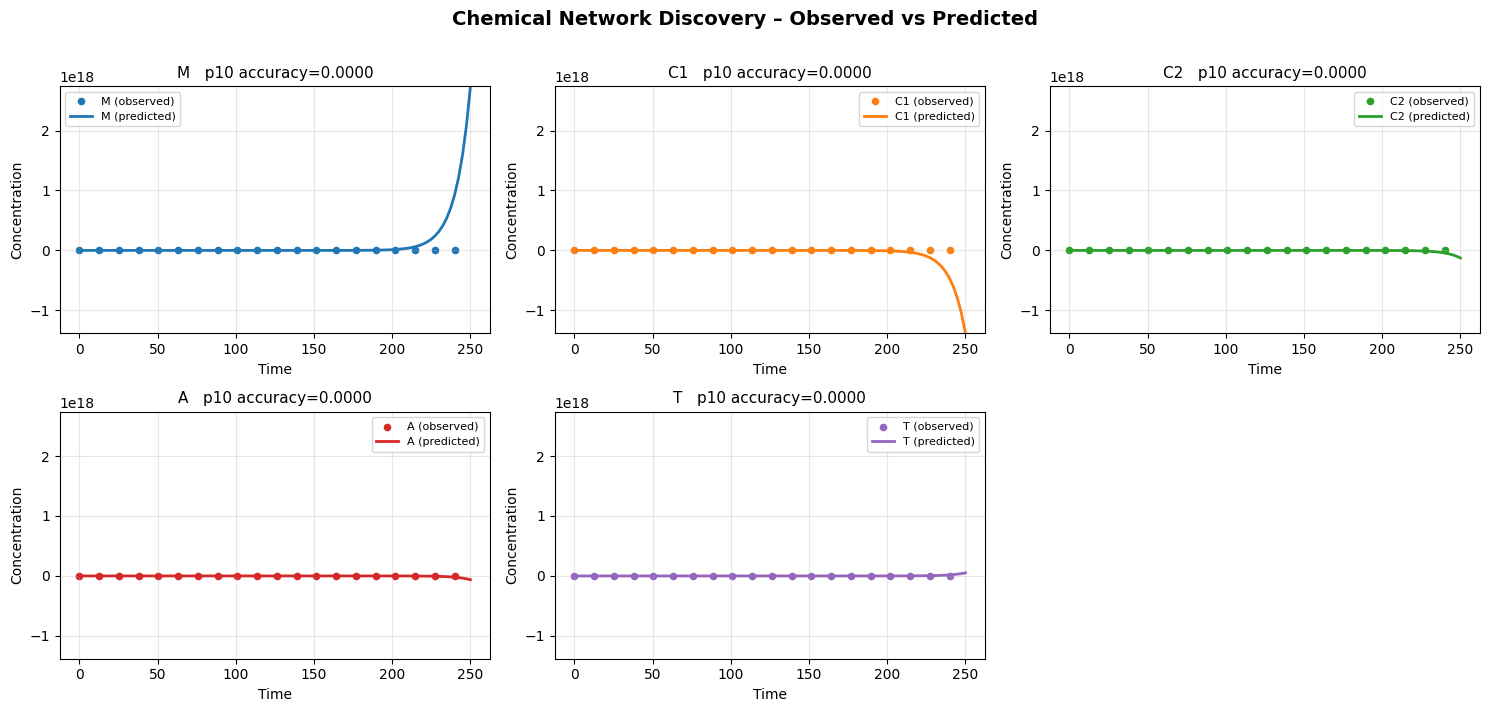

BIOMD0000000850

Poly_degree: 1, threshold: 0.001


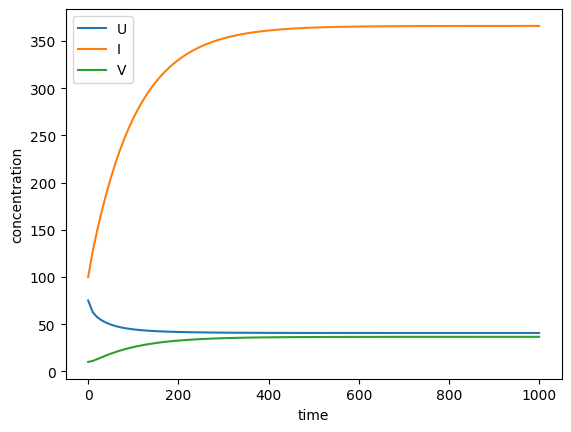

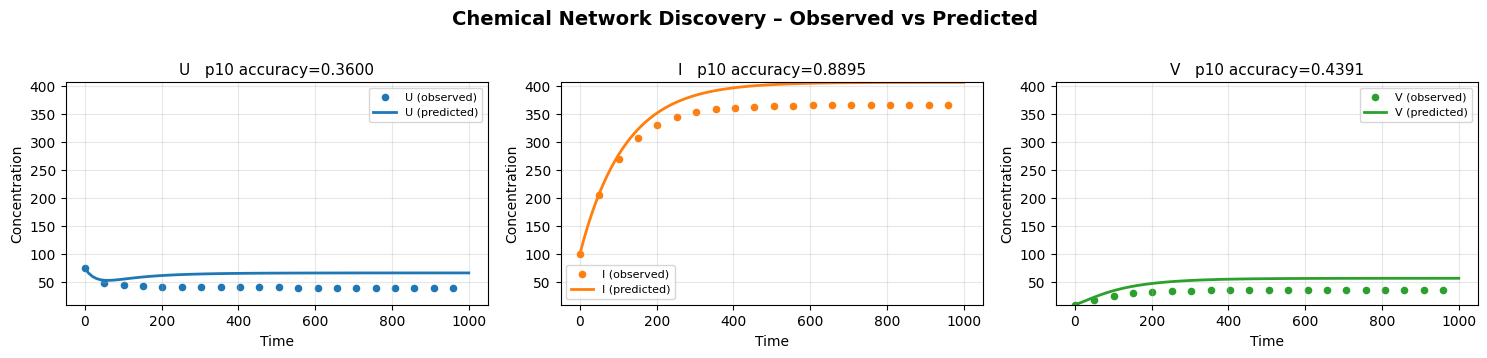

BIOMD0000000854

Poly_degree: 1, threshold: 0.001


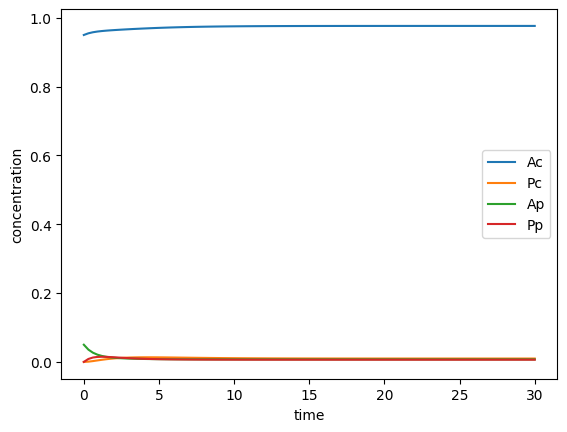

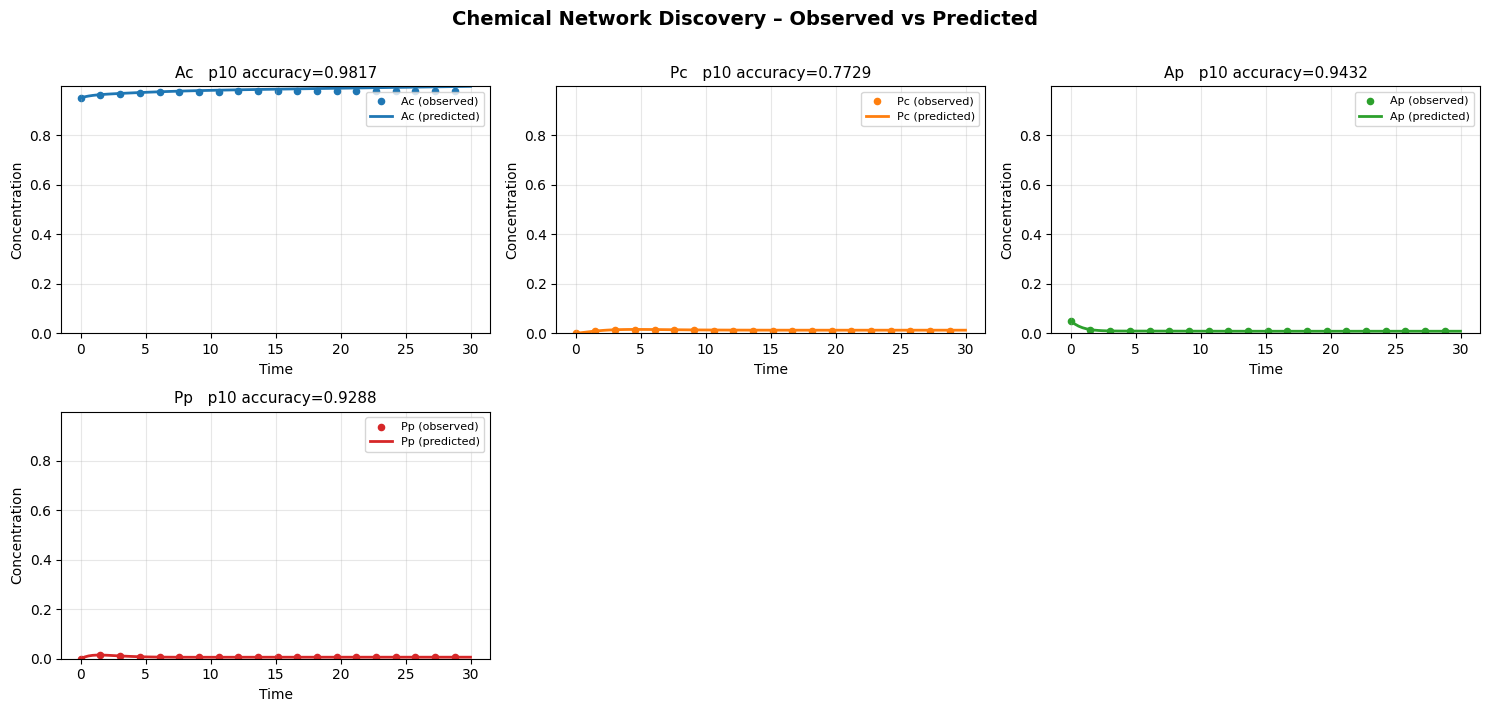

BIOMD0000000882

Poly_degree: 1, threshold: 0.001


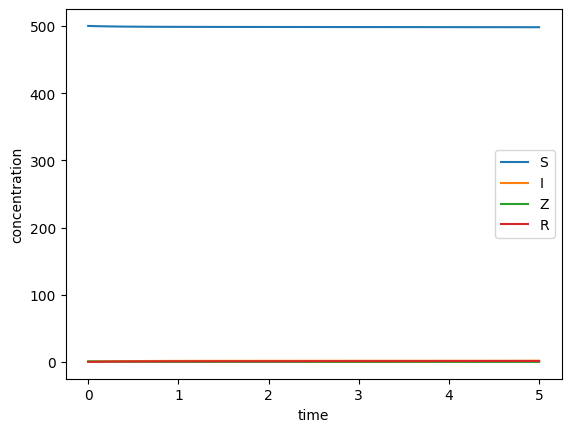

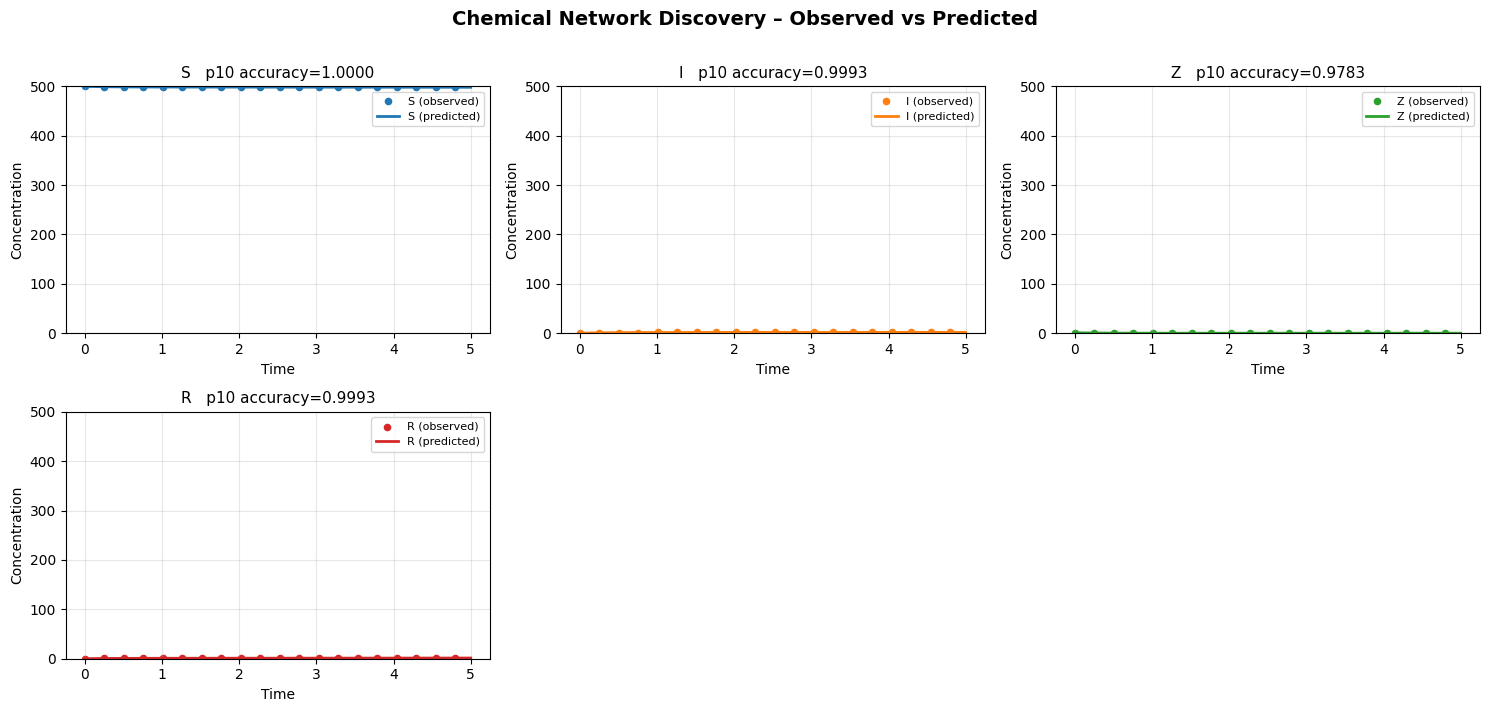

BIOMD0000000885

Poly_degree: 1, threshold: 0.001


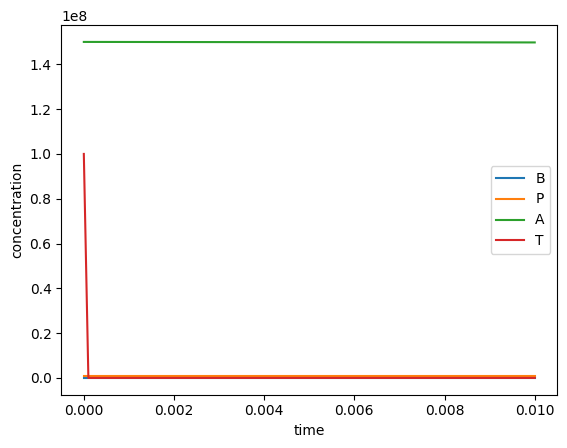

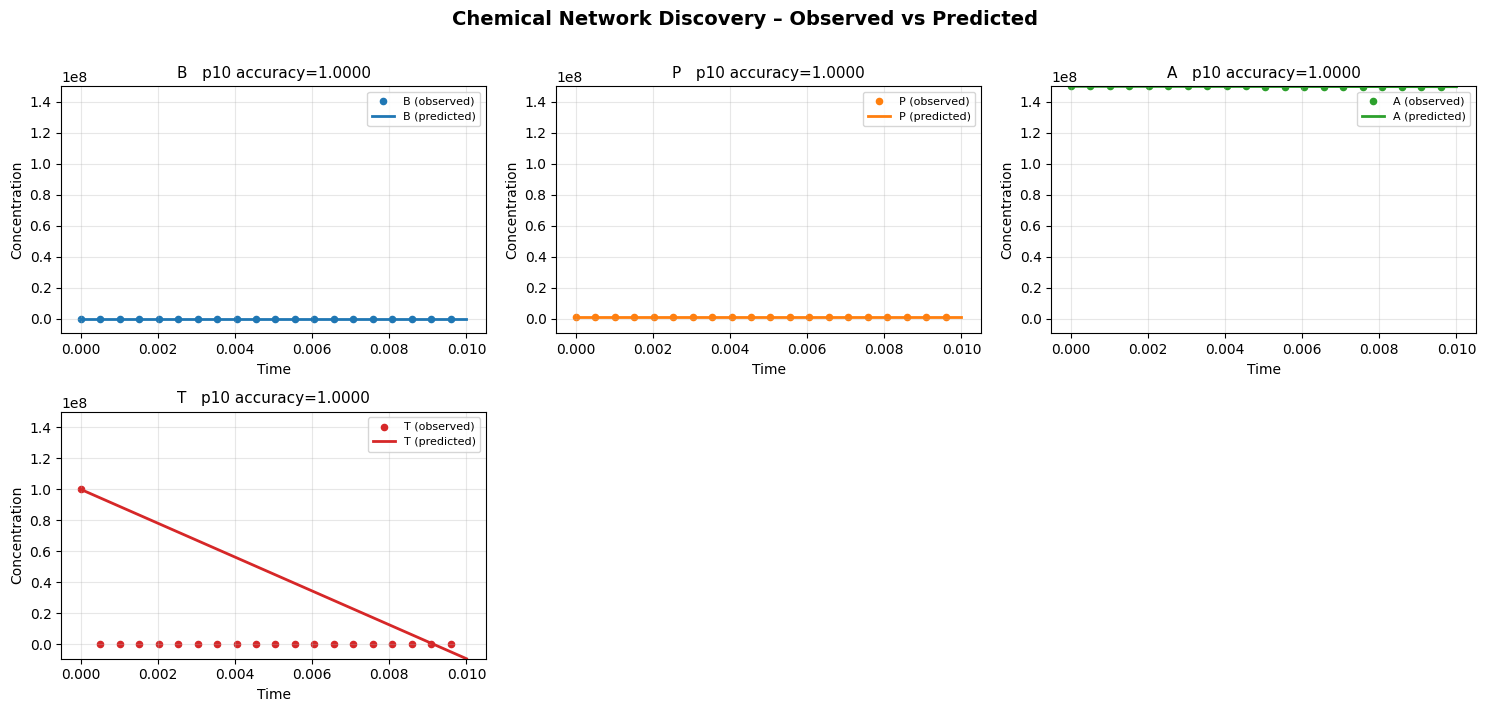

BIOMD0000000890

Poly_degree: 1, threshold: 0.001


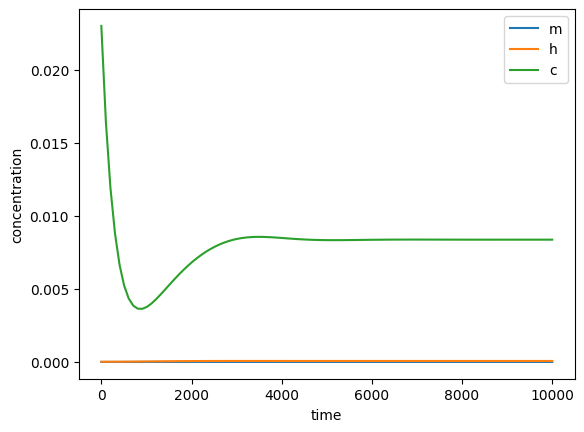

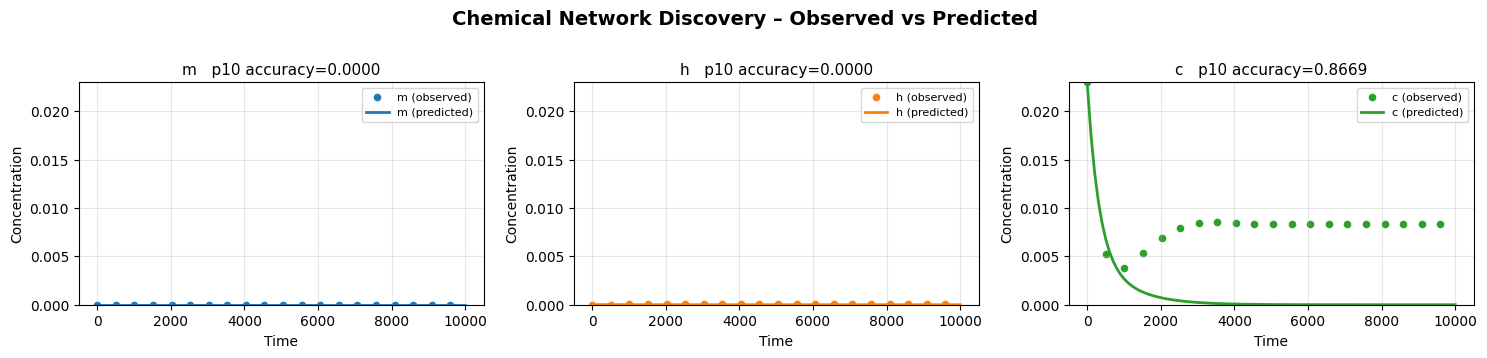

BIOMD0000000897

Poly_degree: 1, threshold: 0.001


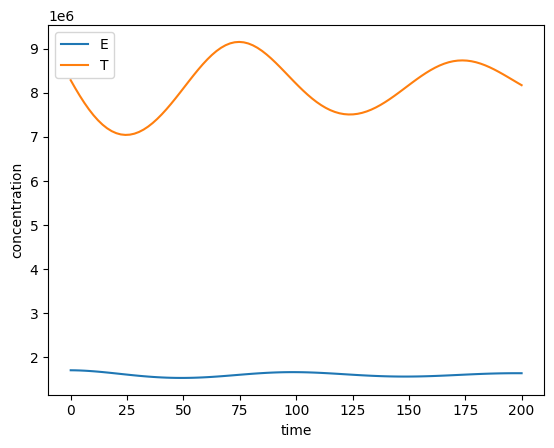

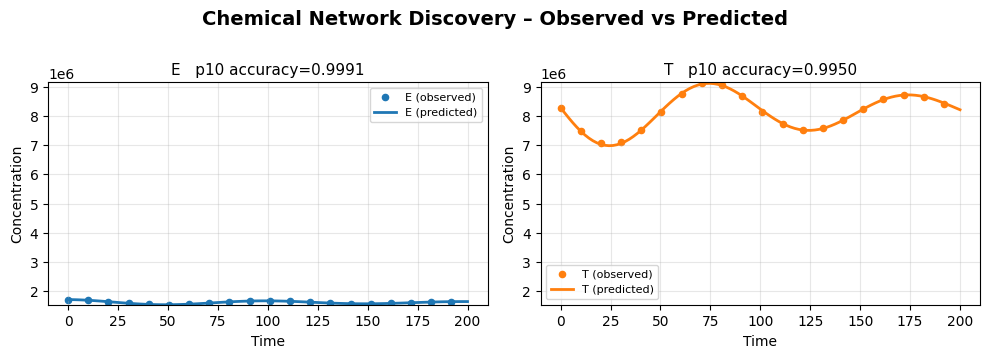

BIOMD0000000909

Poly_degree: 1, threshold: 0.001


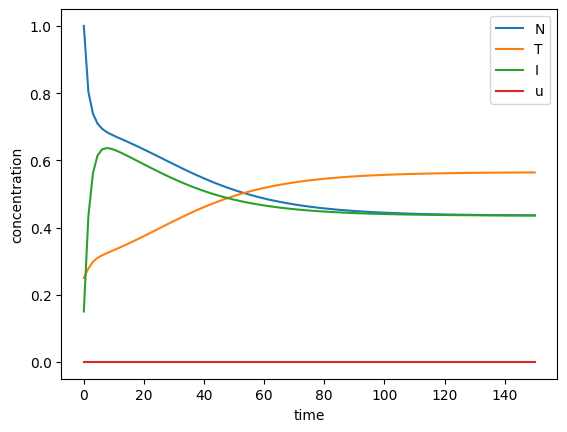

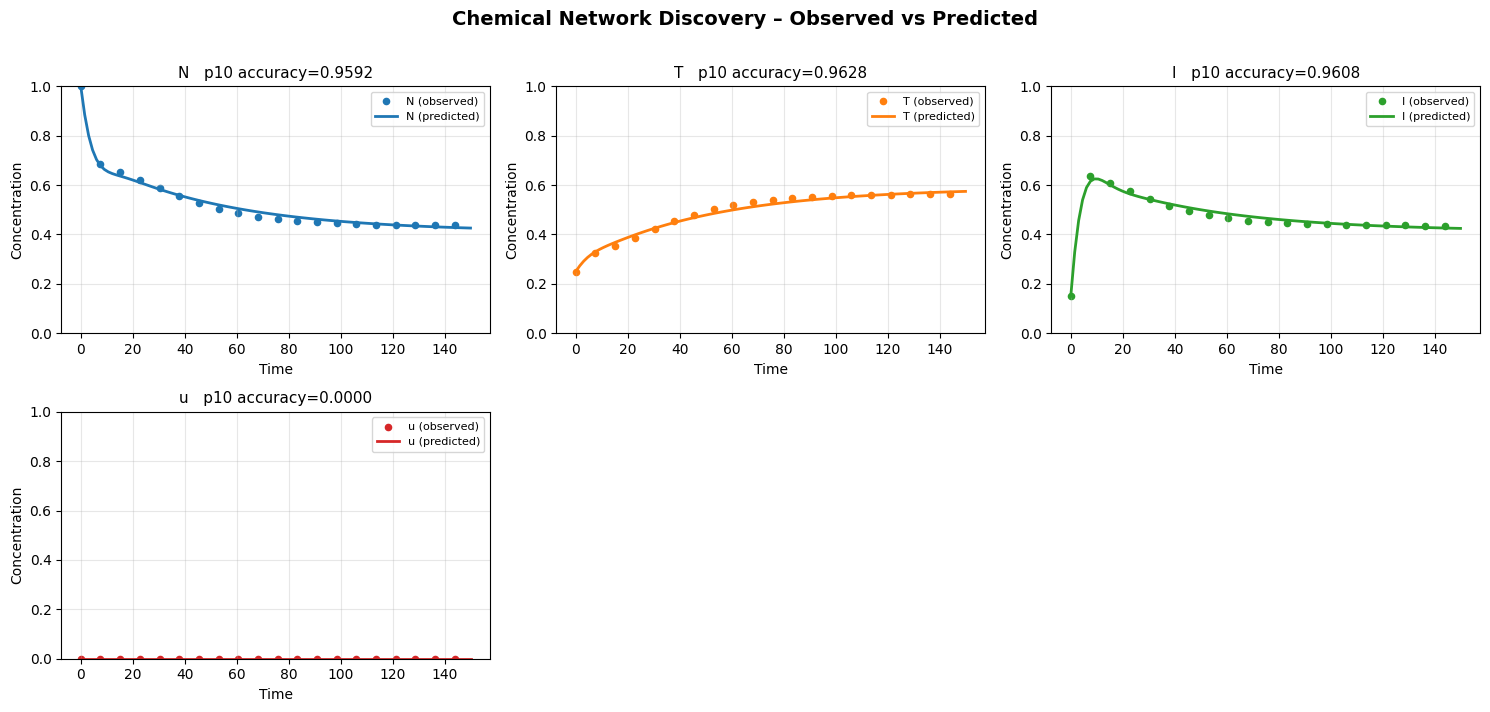

BIOMD0000000911

Poly_degree: 1, threshold: 0.001


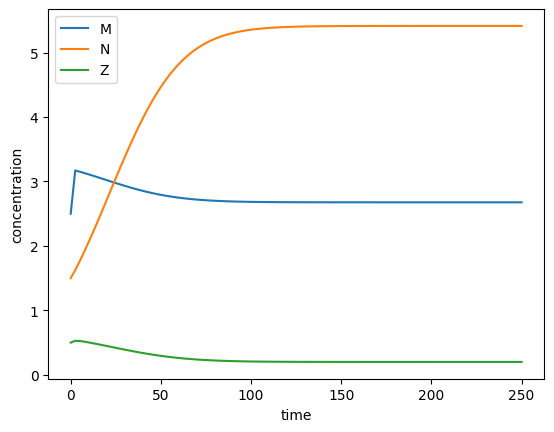

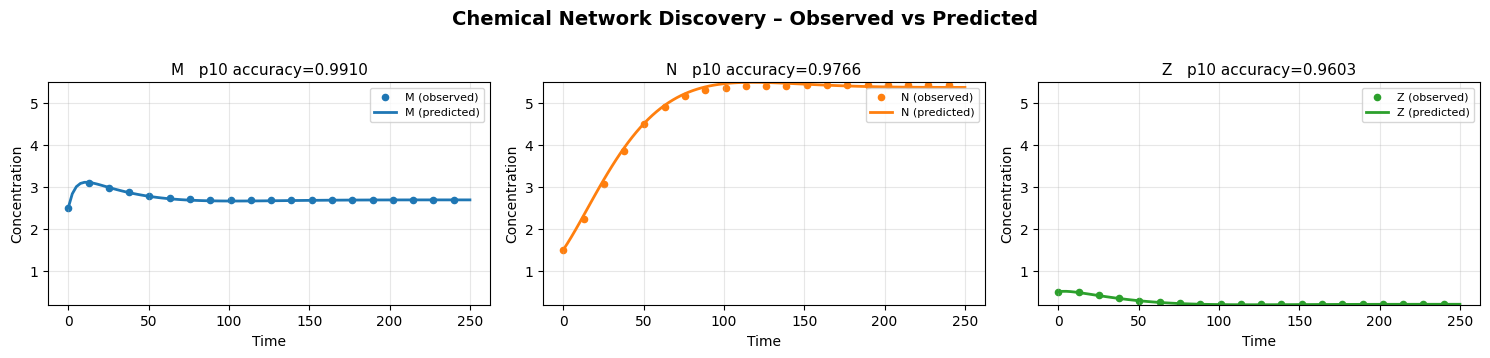

BIOMD0000000914

Poly_degree: 1, threshold: 0.001


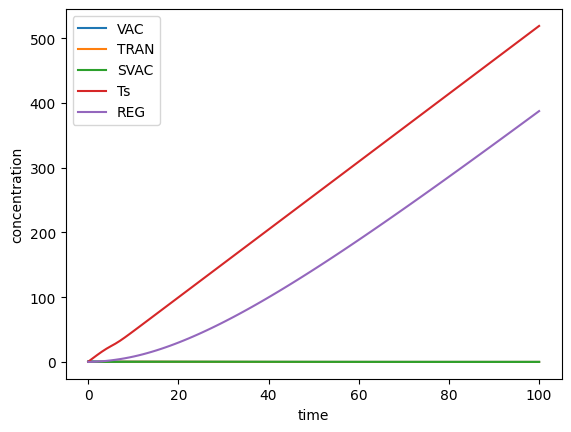

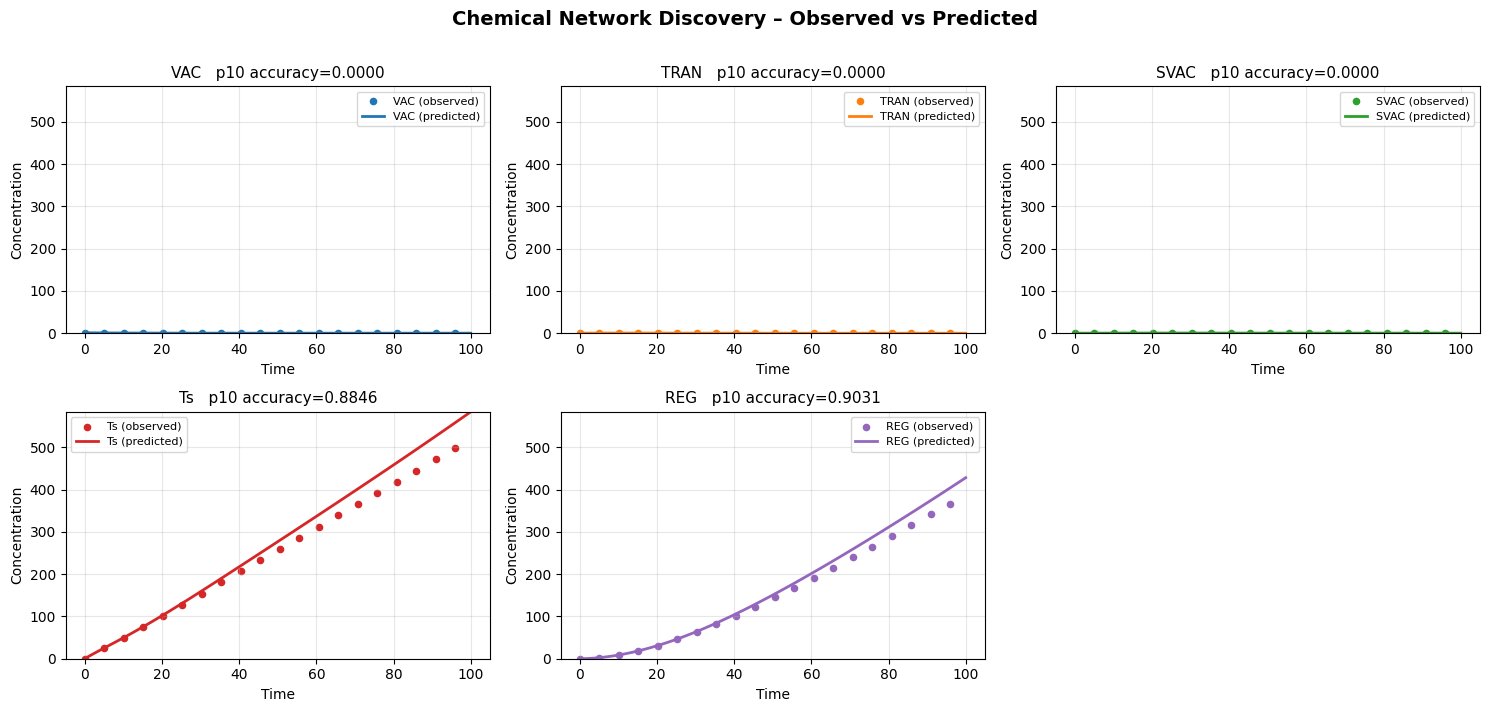

BIOMD0000000915

Poly_degree: 1, threshold: 0.001


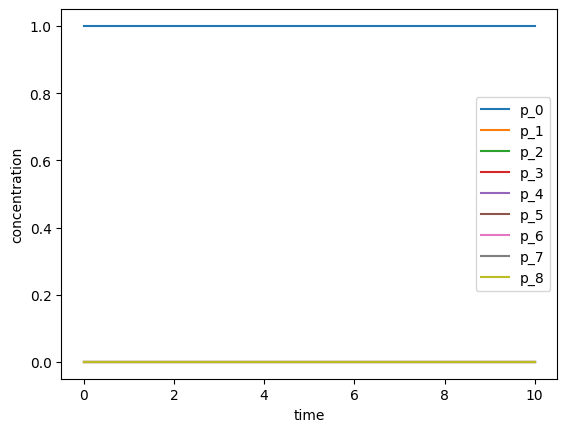

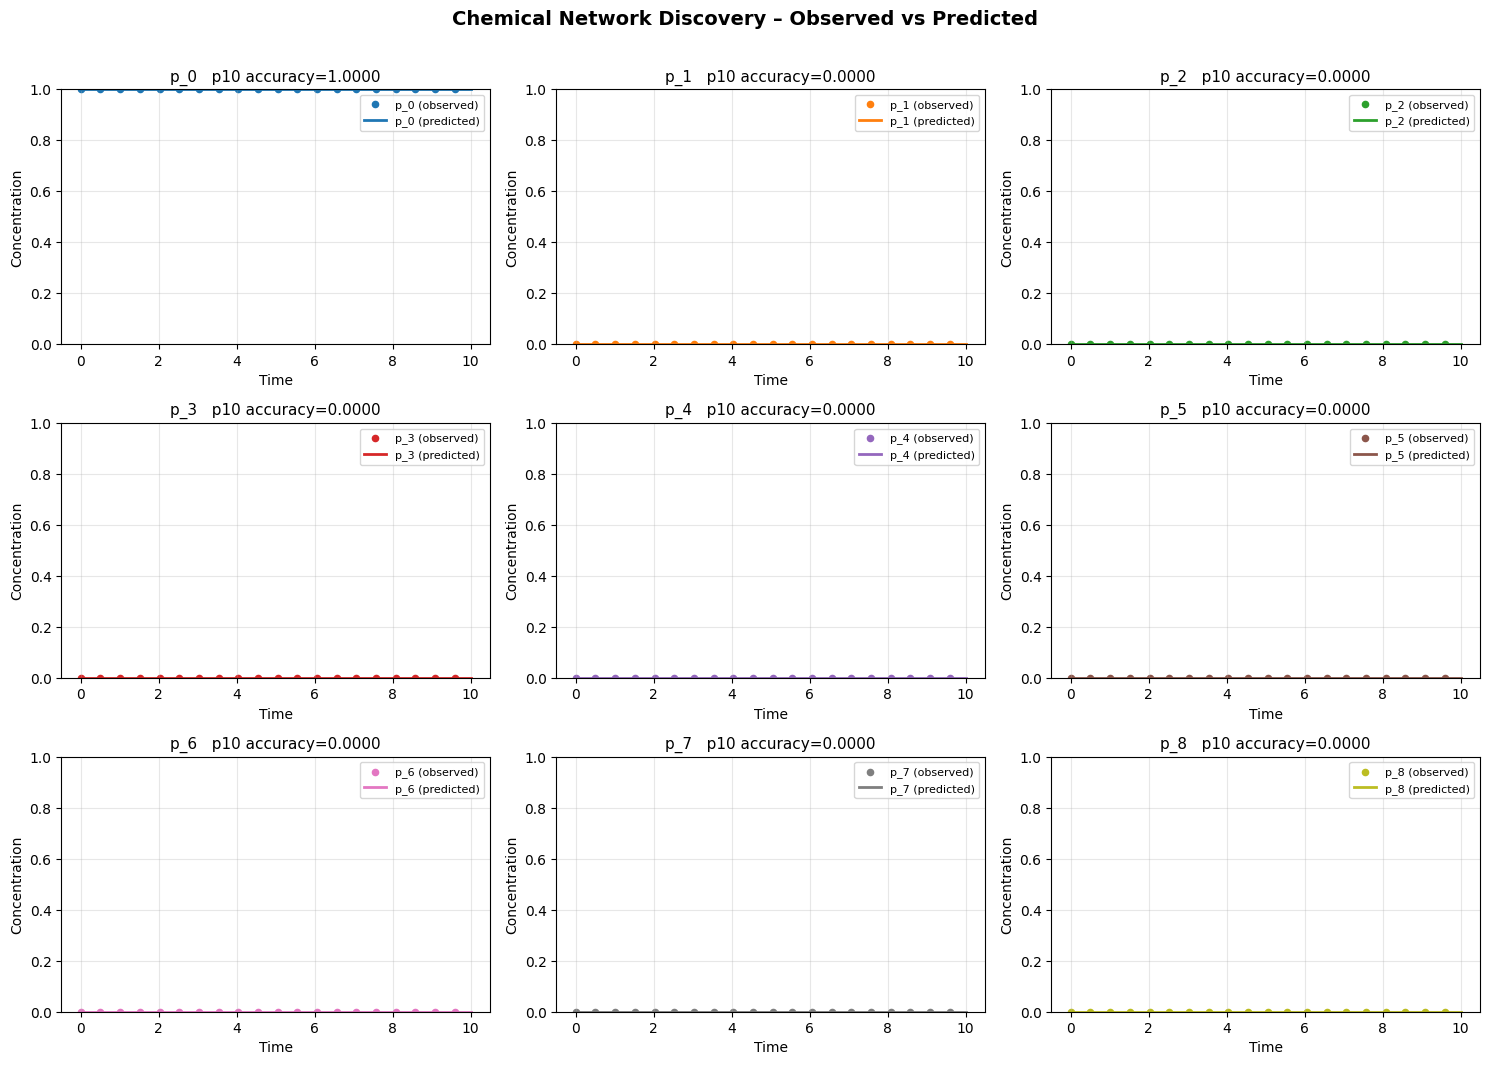

BIOMD0000000916

Poly_degree: 1, threshold: 0.001


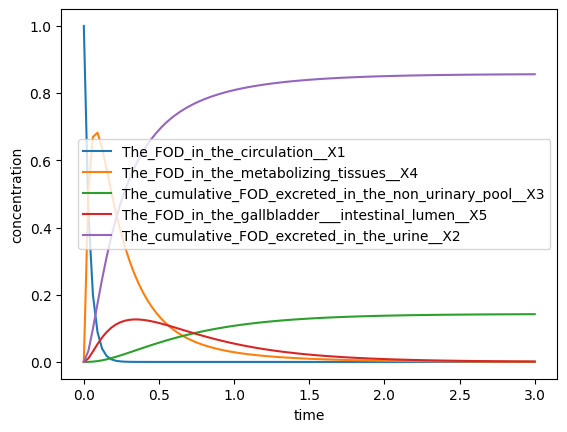

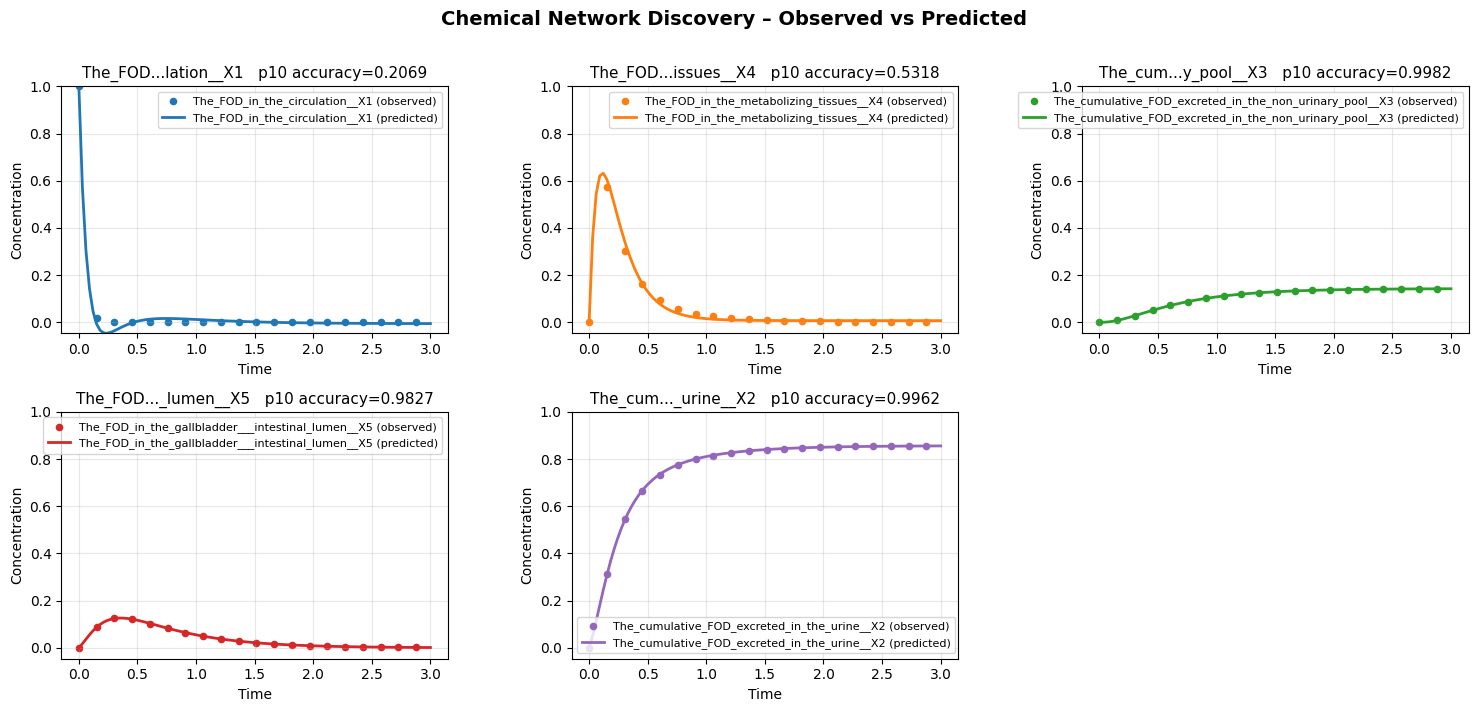

BIOMD0000000920

Poly_degree: 1, threshold: 0.001


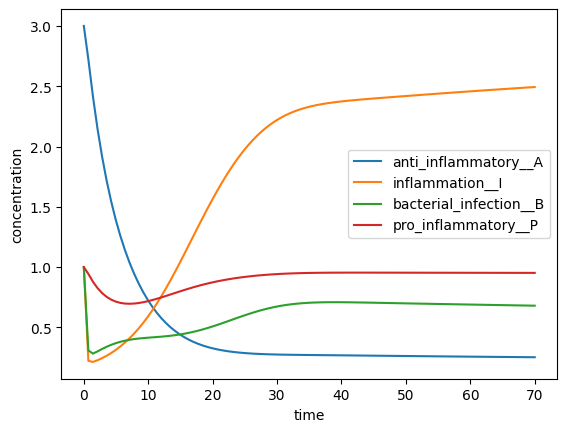

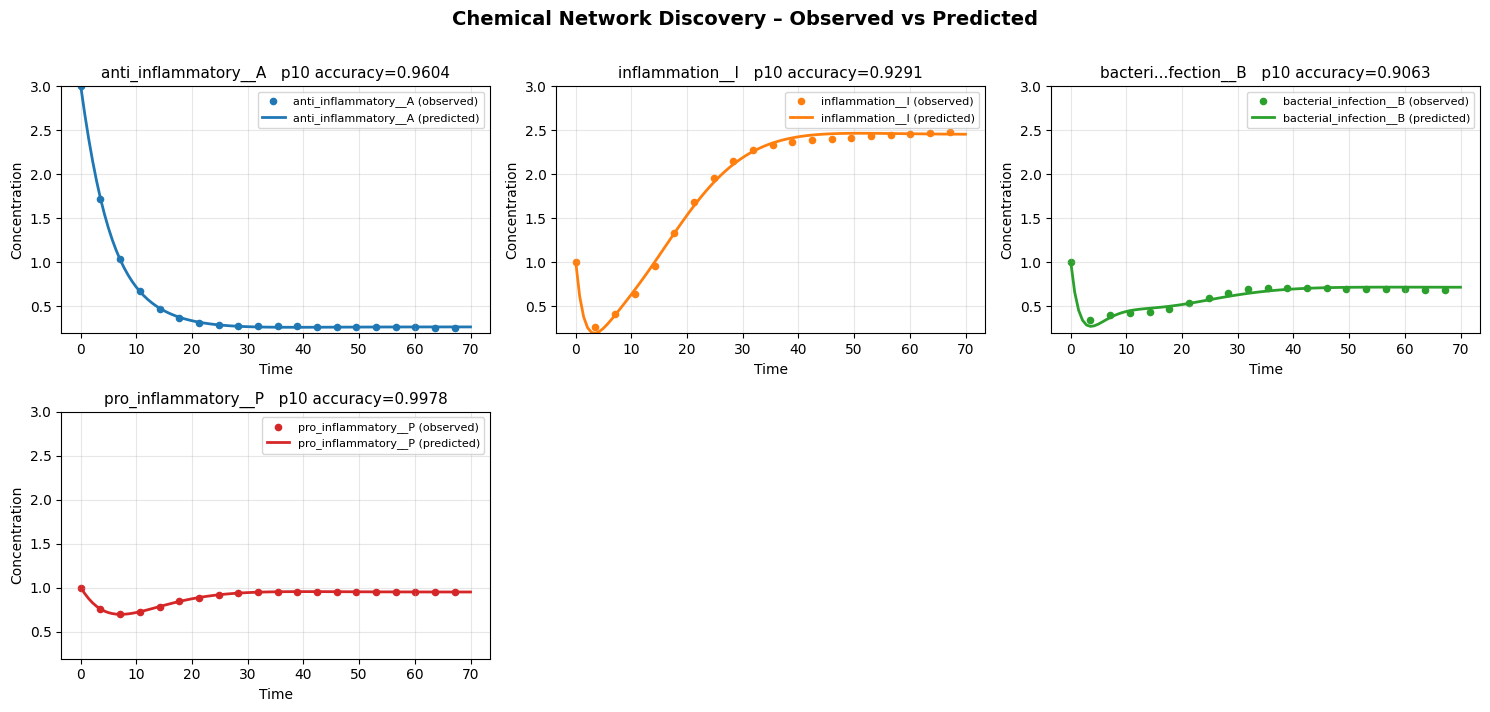

BIOMD0000000945

Poly_degree: 1, threshold: 0.001


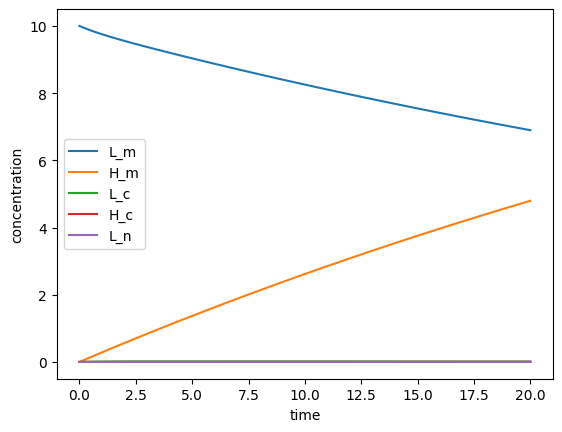

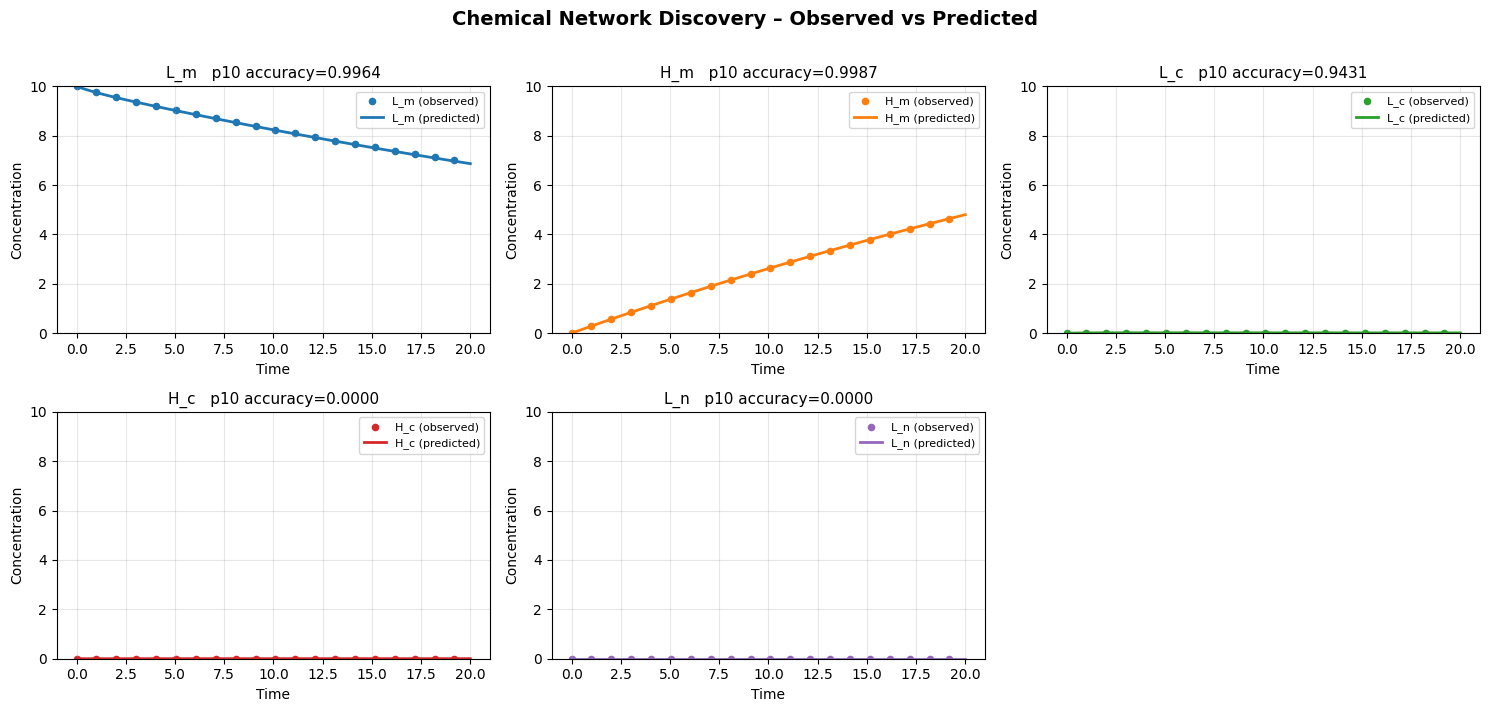

BIOMD0000000947

Poly_degree: 1, threshold: 0.001


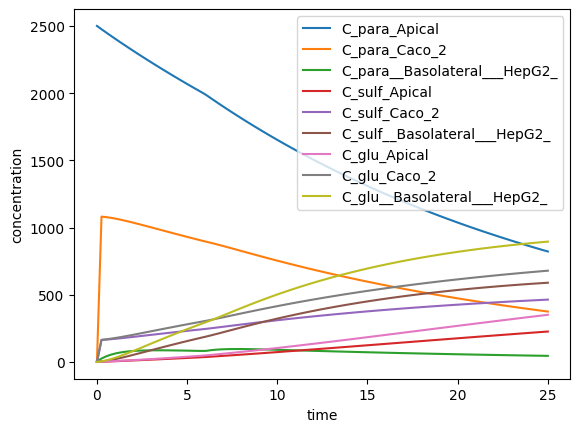

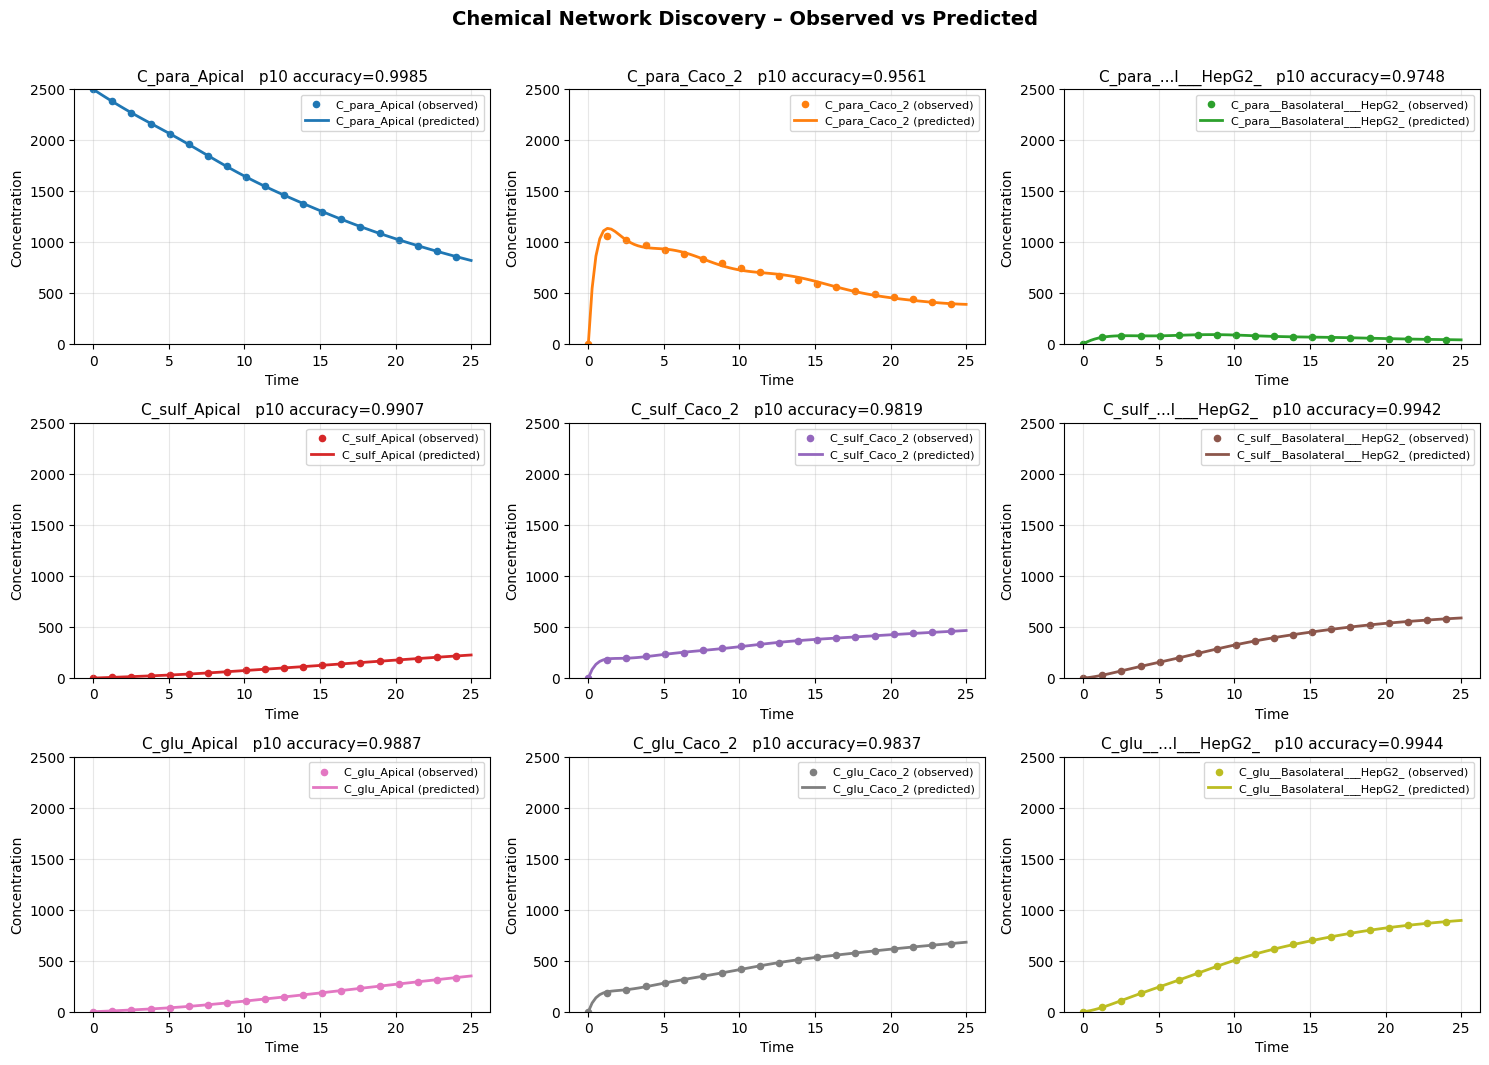

BIOMD0000000955

Poly_degree: 1, threshold: 0.001


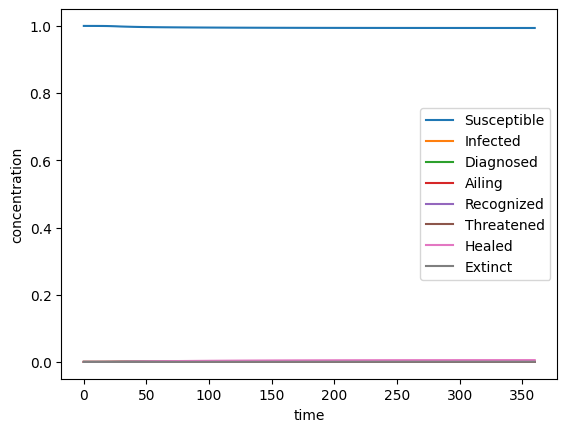

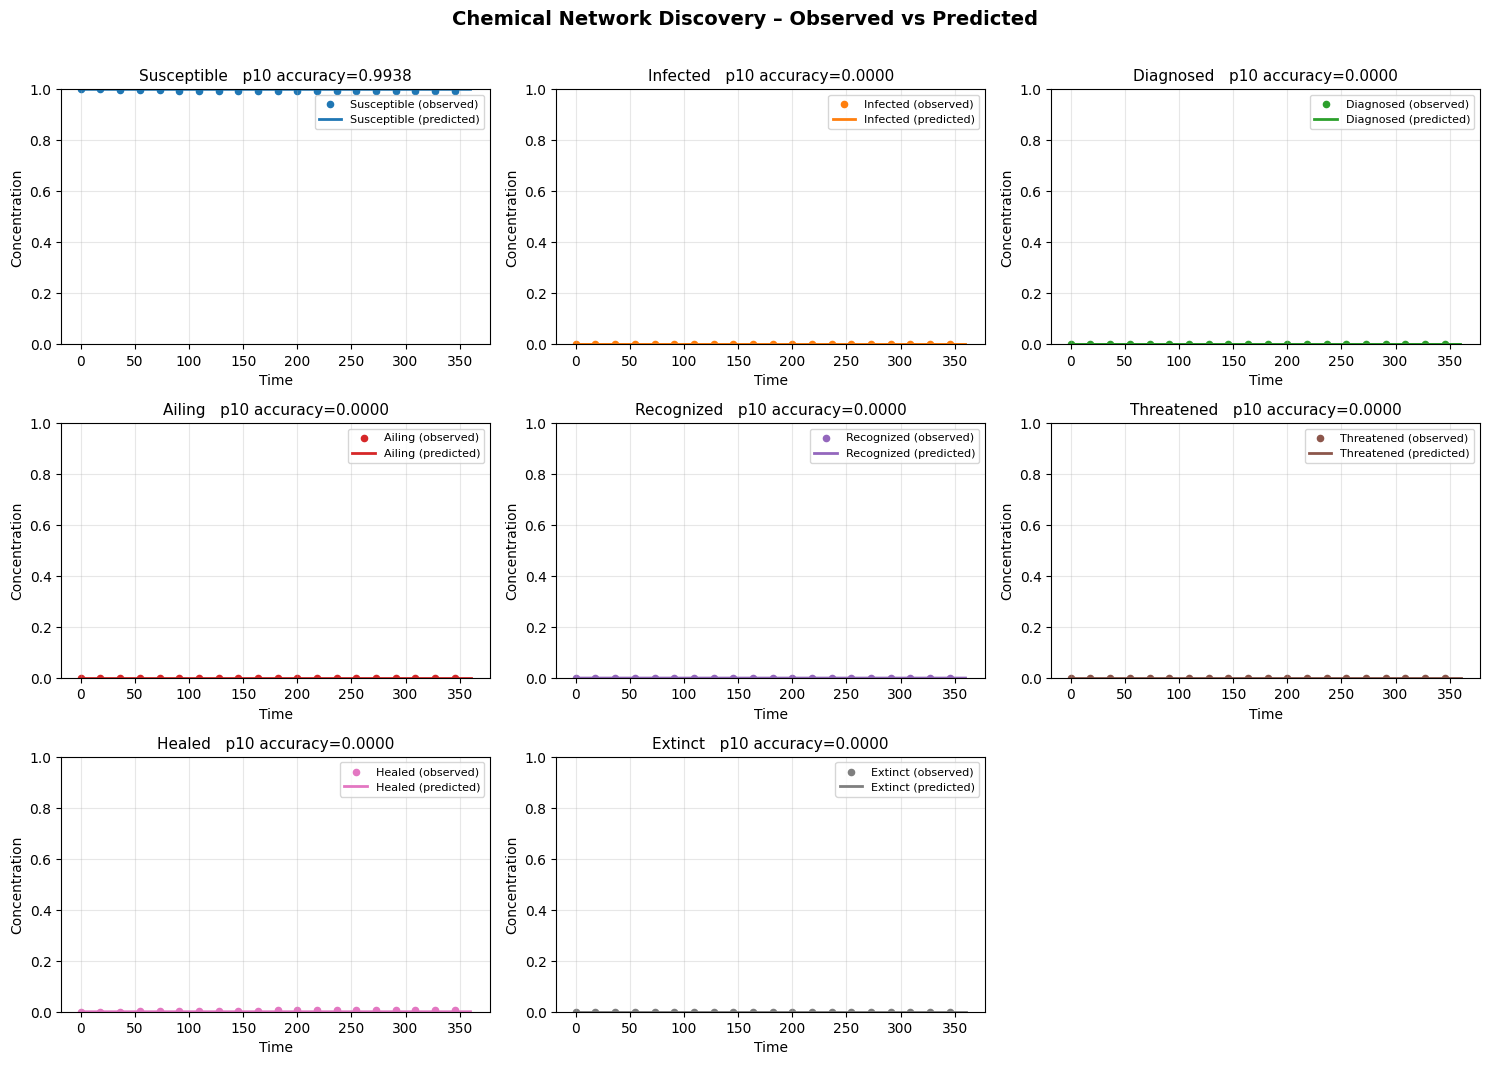

BIOMD0000000987

Poly_degree: 1, threshold: 0.001


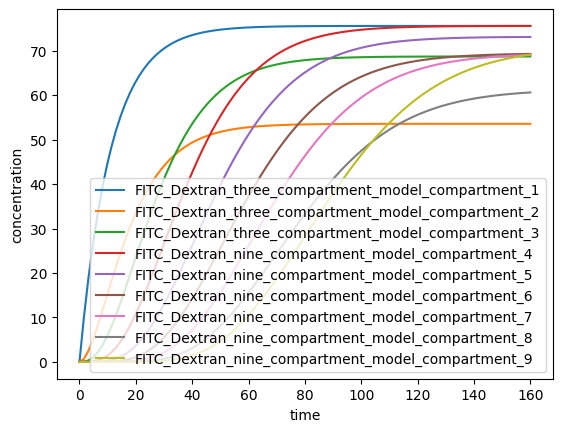

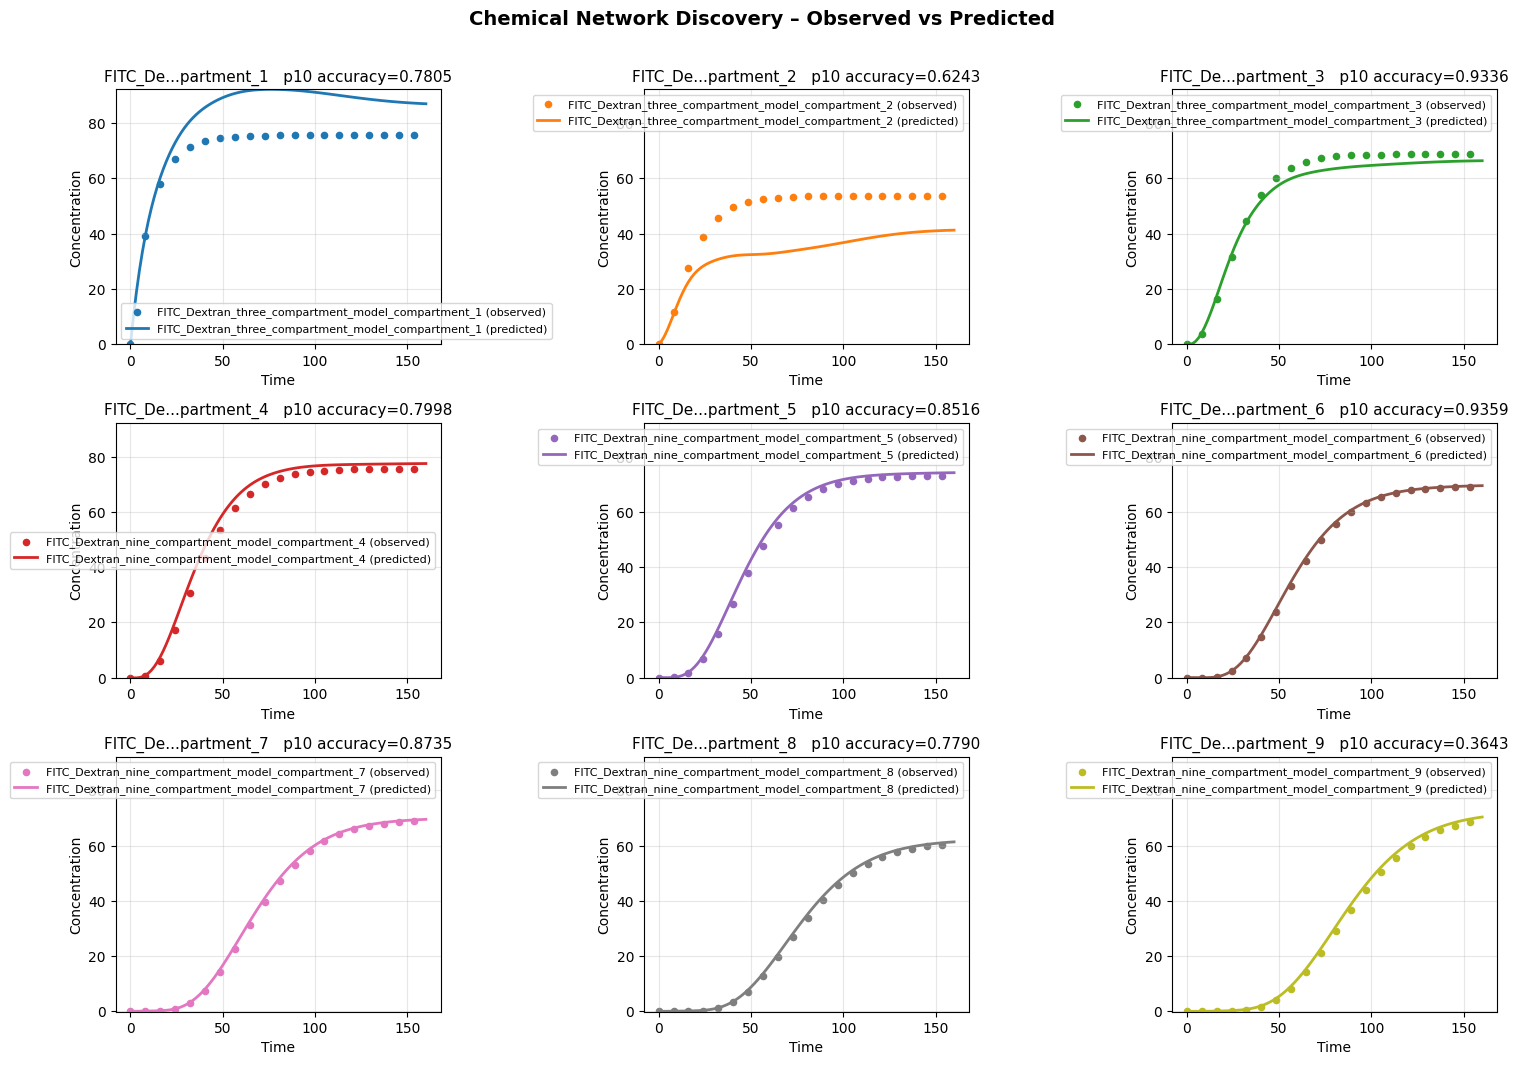

BIOMD0000000994

Poly_degree: 1, threshold: 0.001


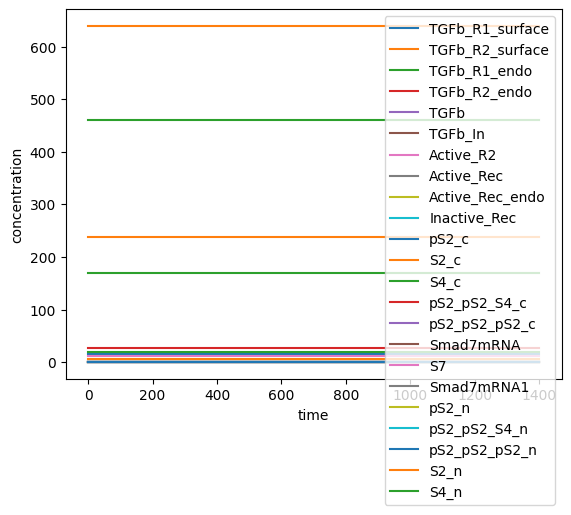

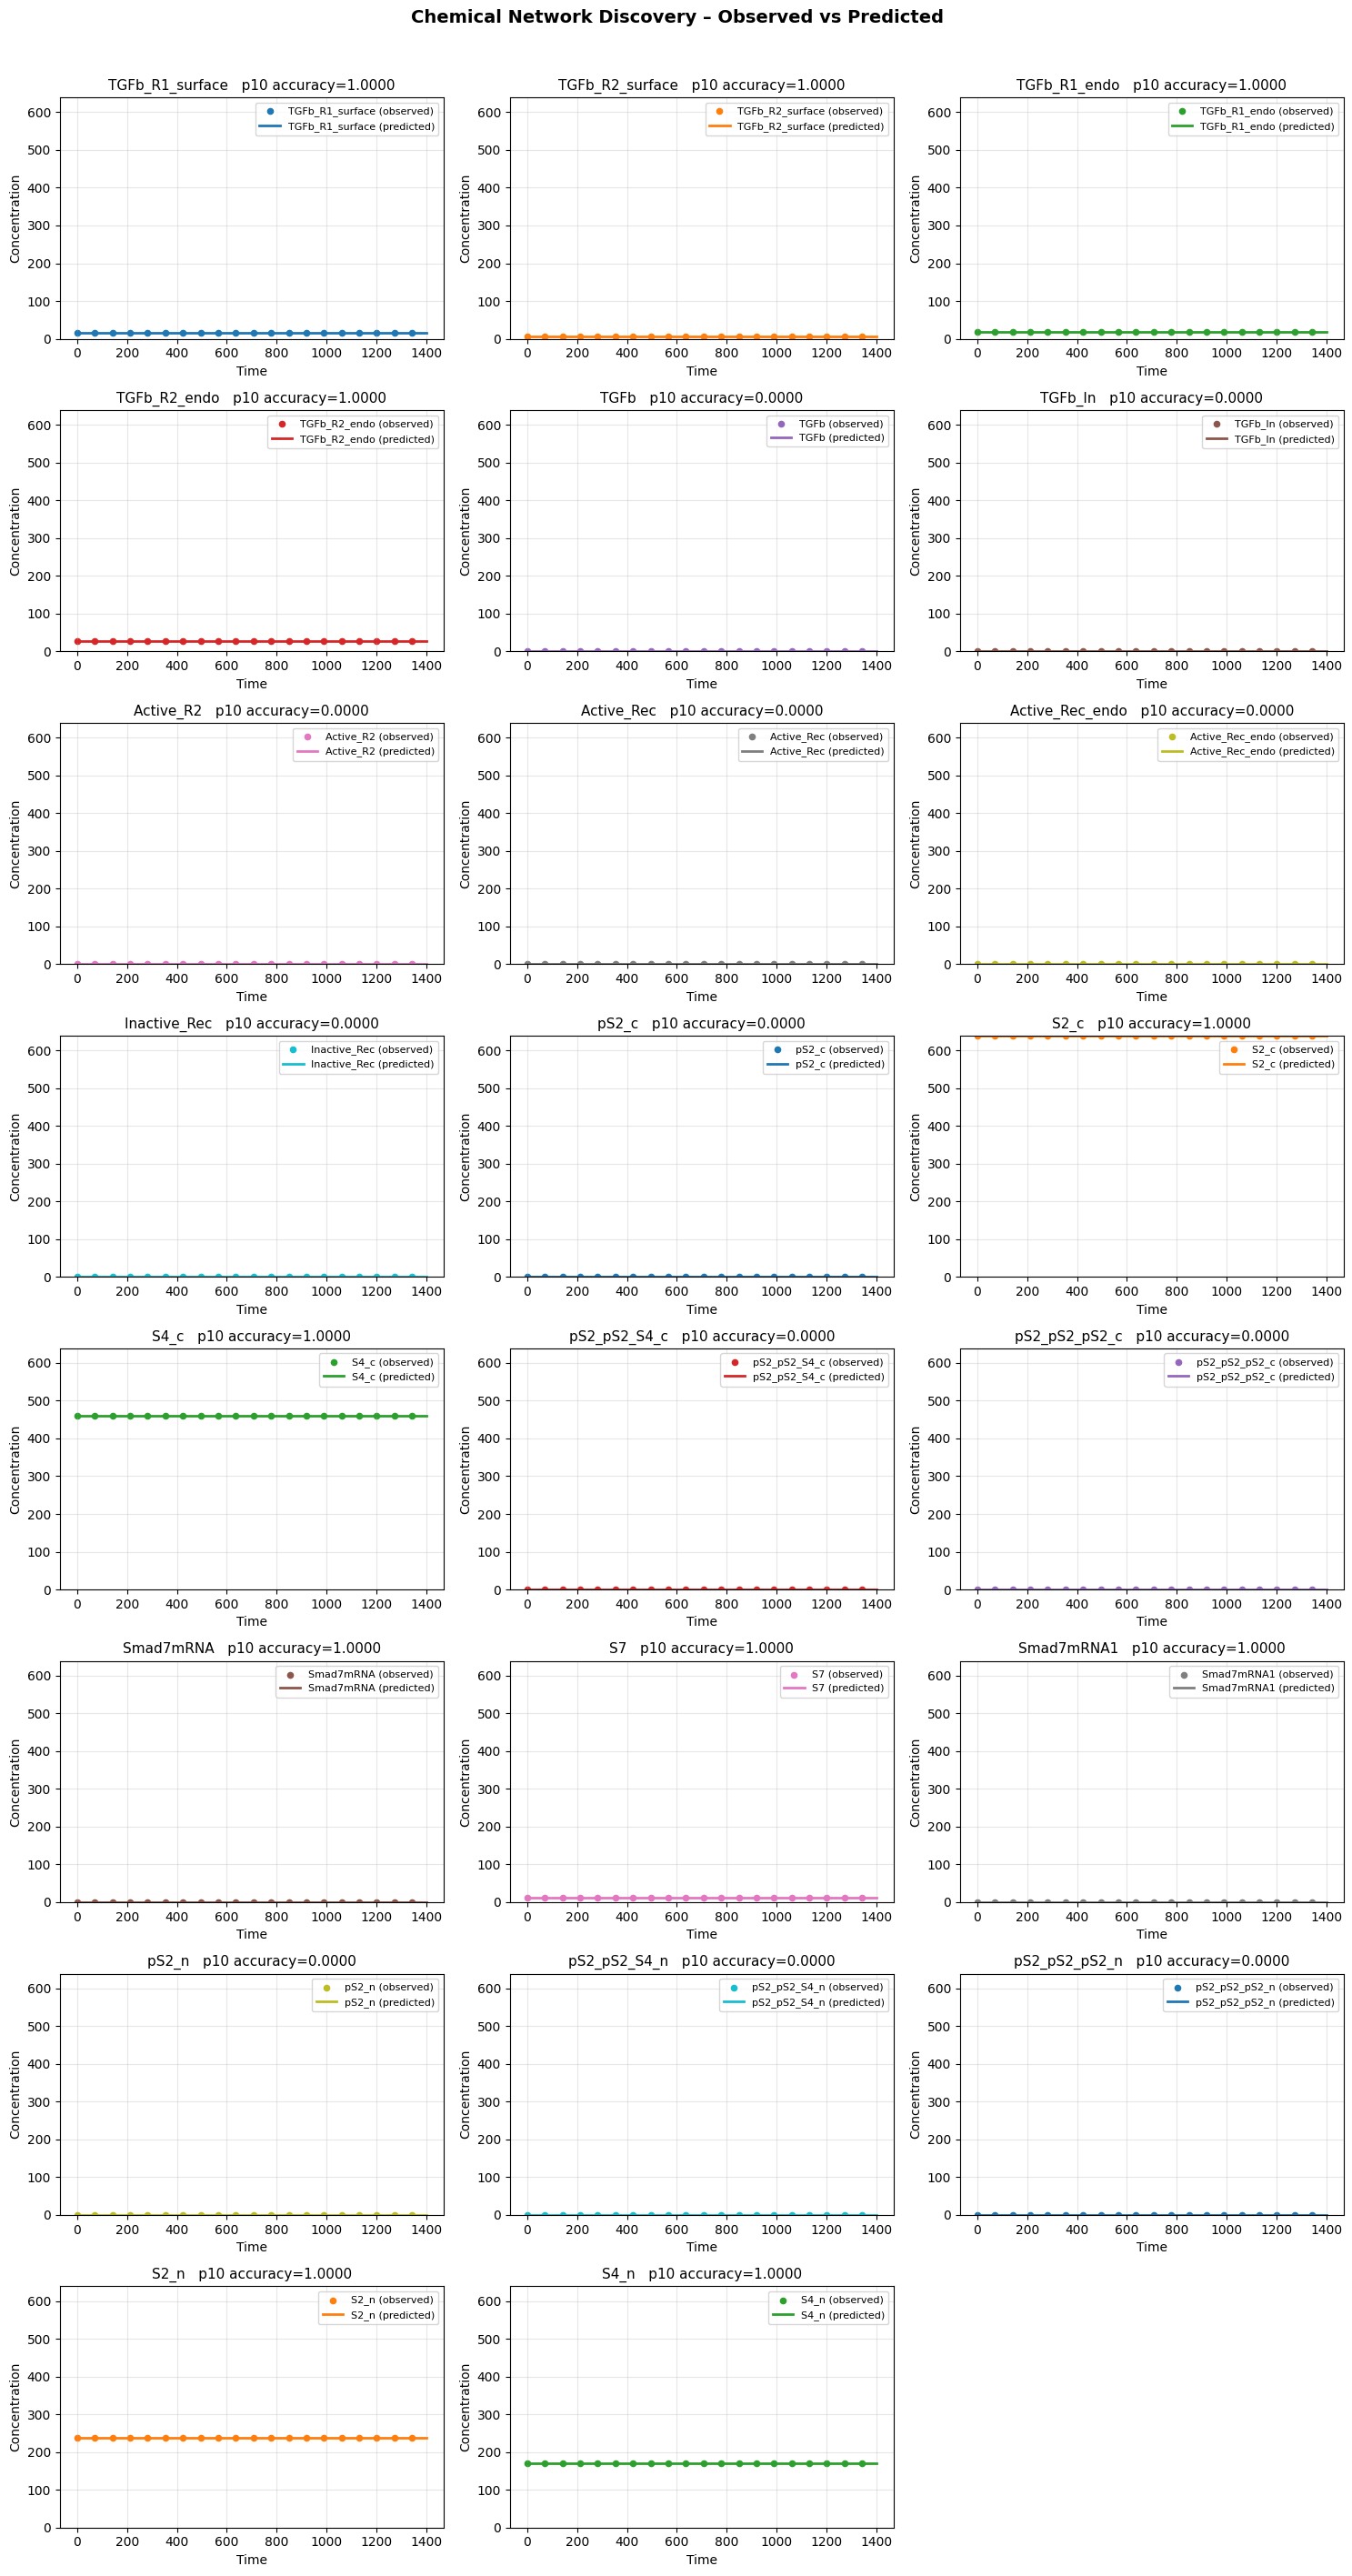

BIOMD0000000995

Poly_degree: 1, threshold: 0.001


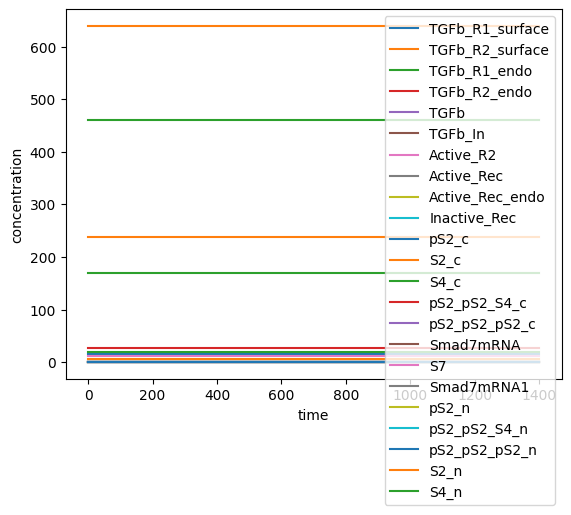

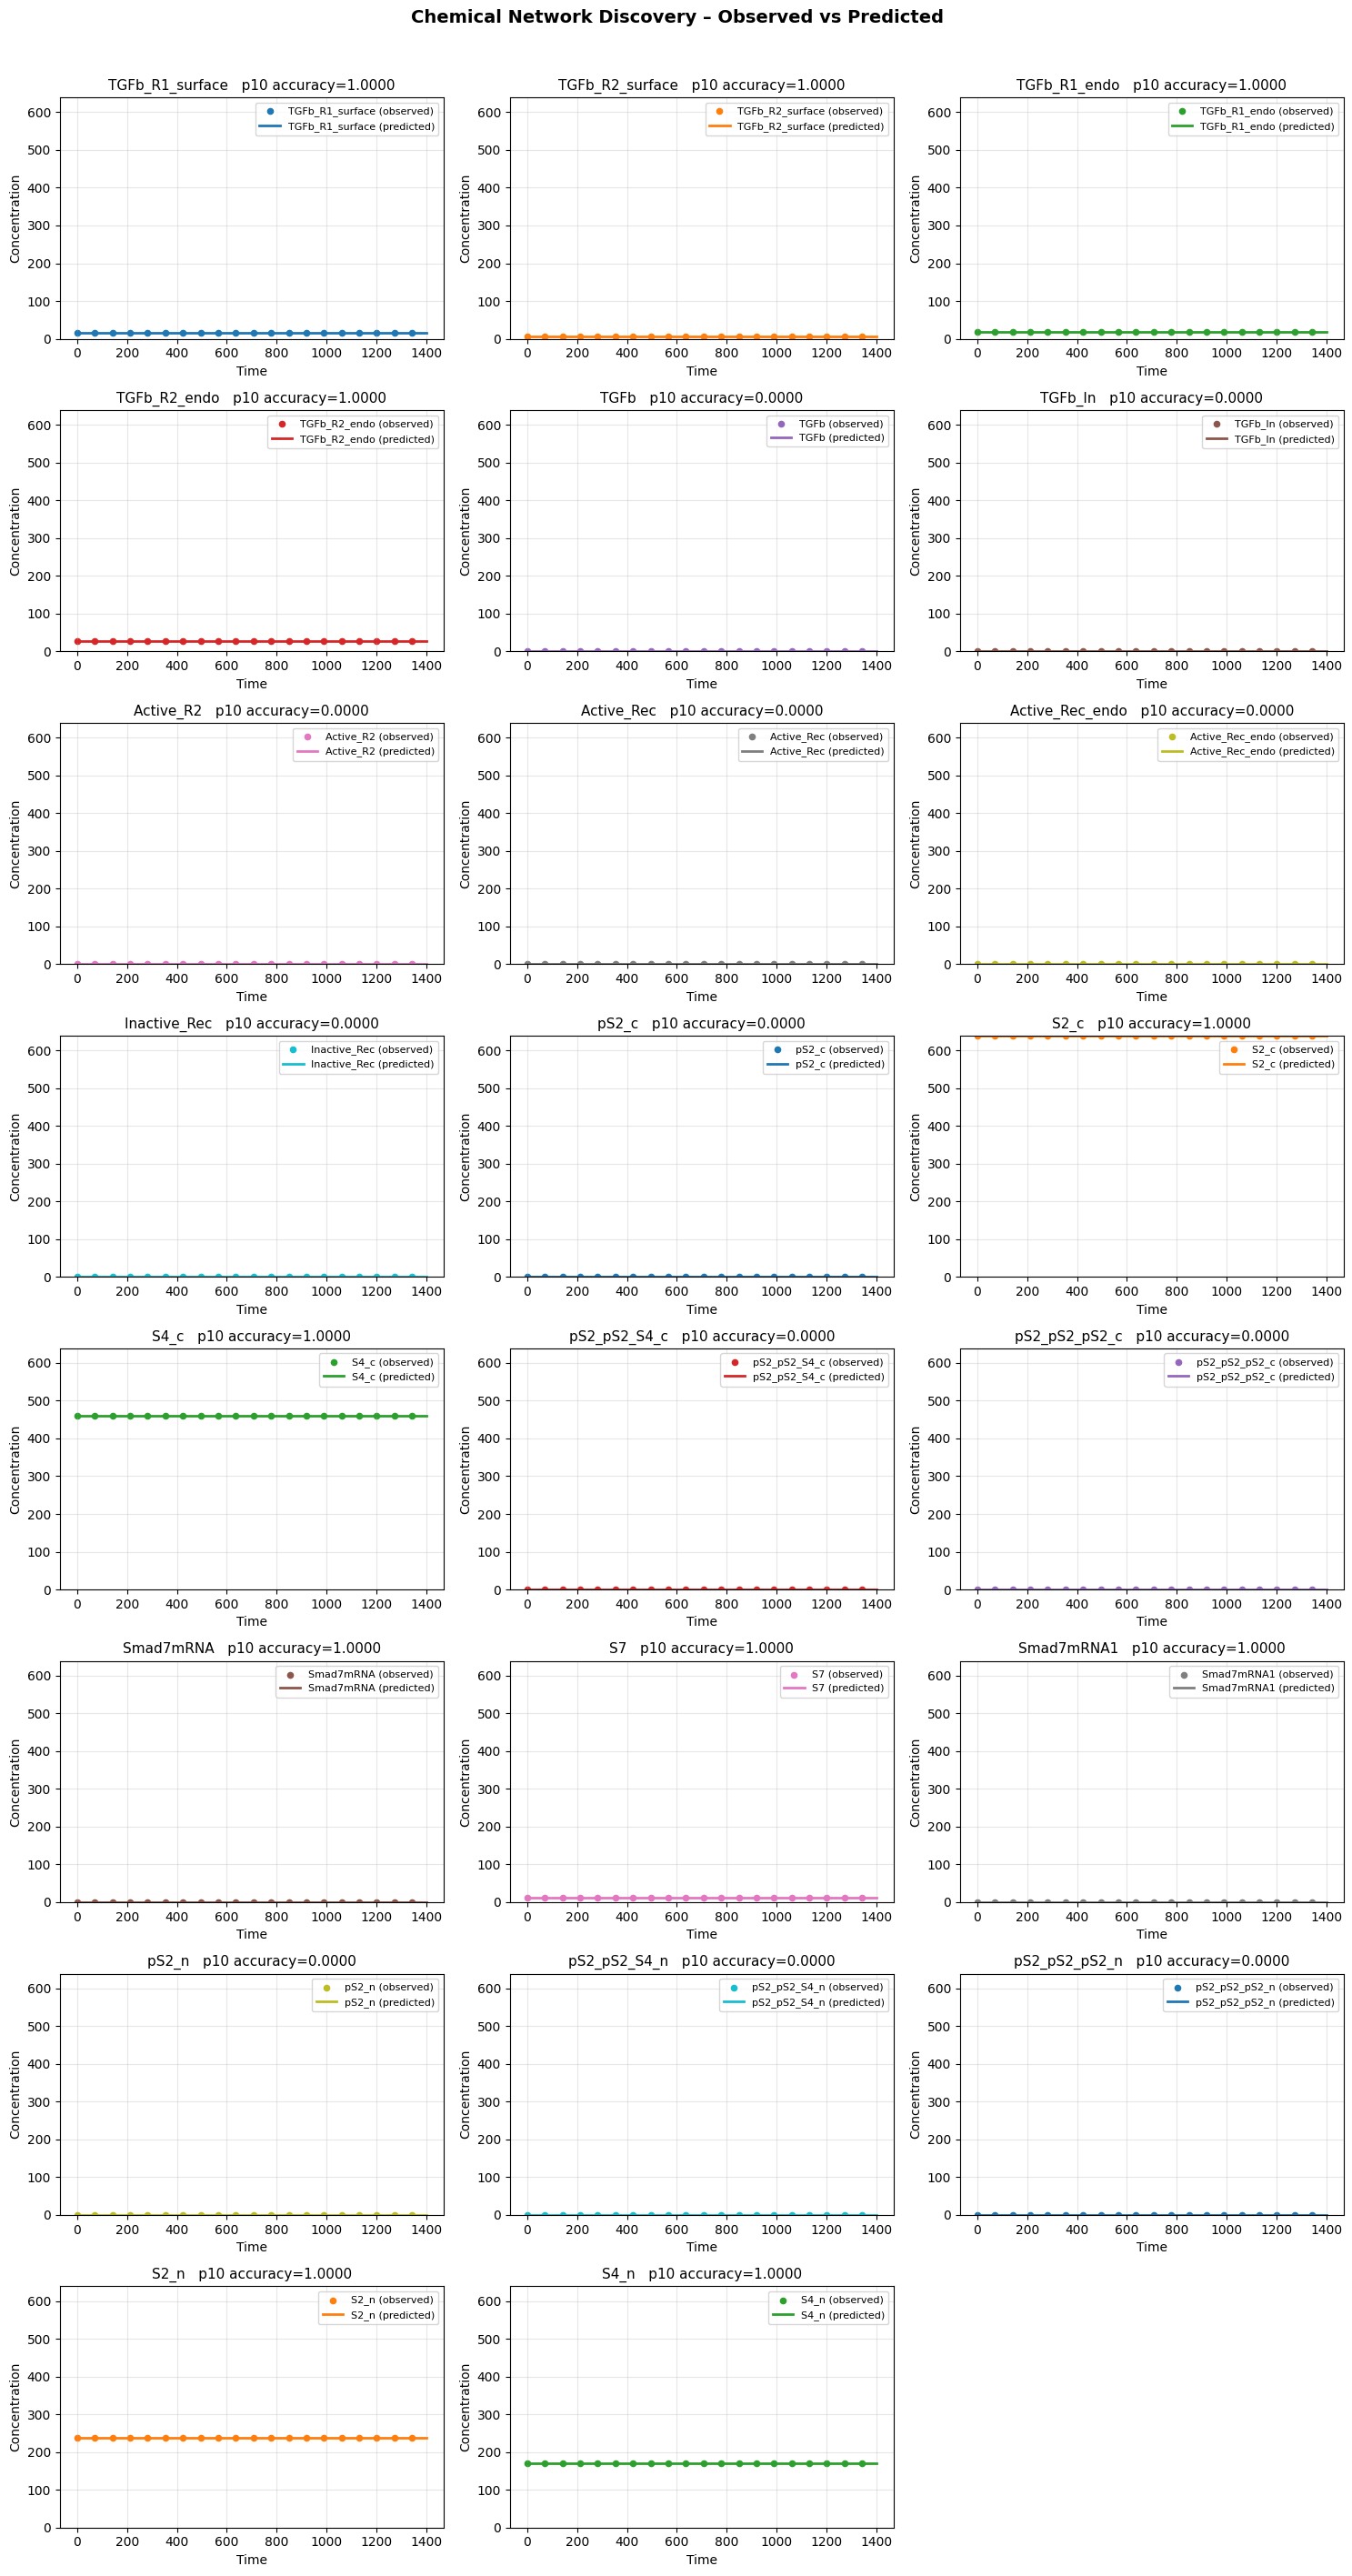

BIOMD0000000996

Poly_degree: 1, threshold: 0.001


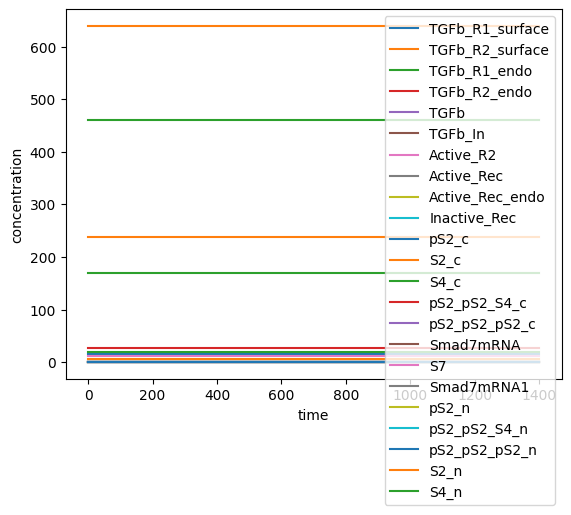

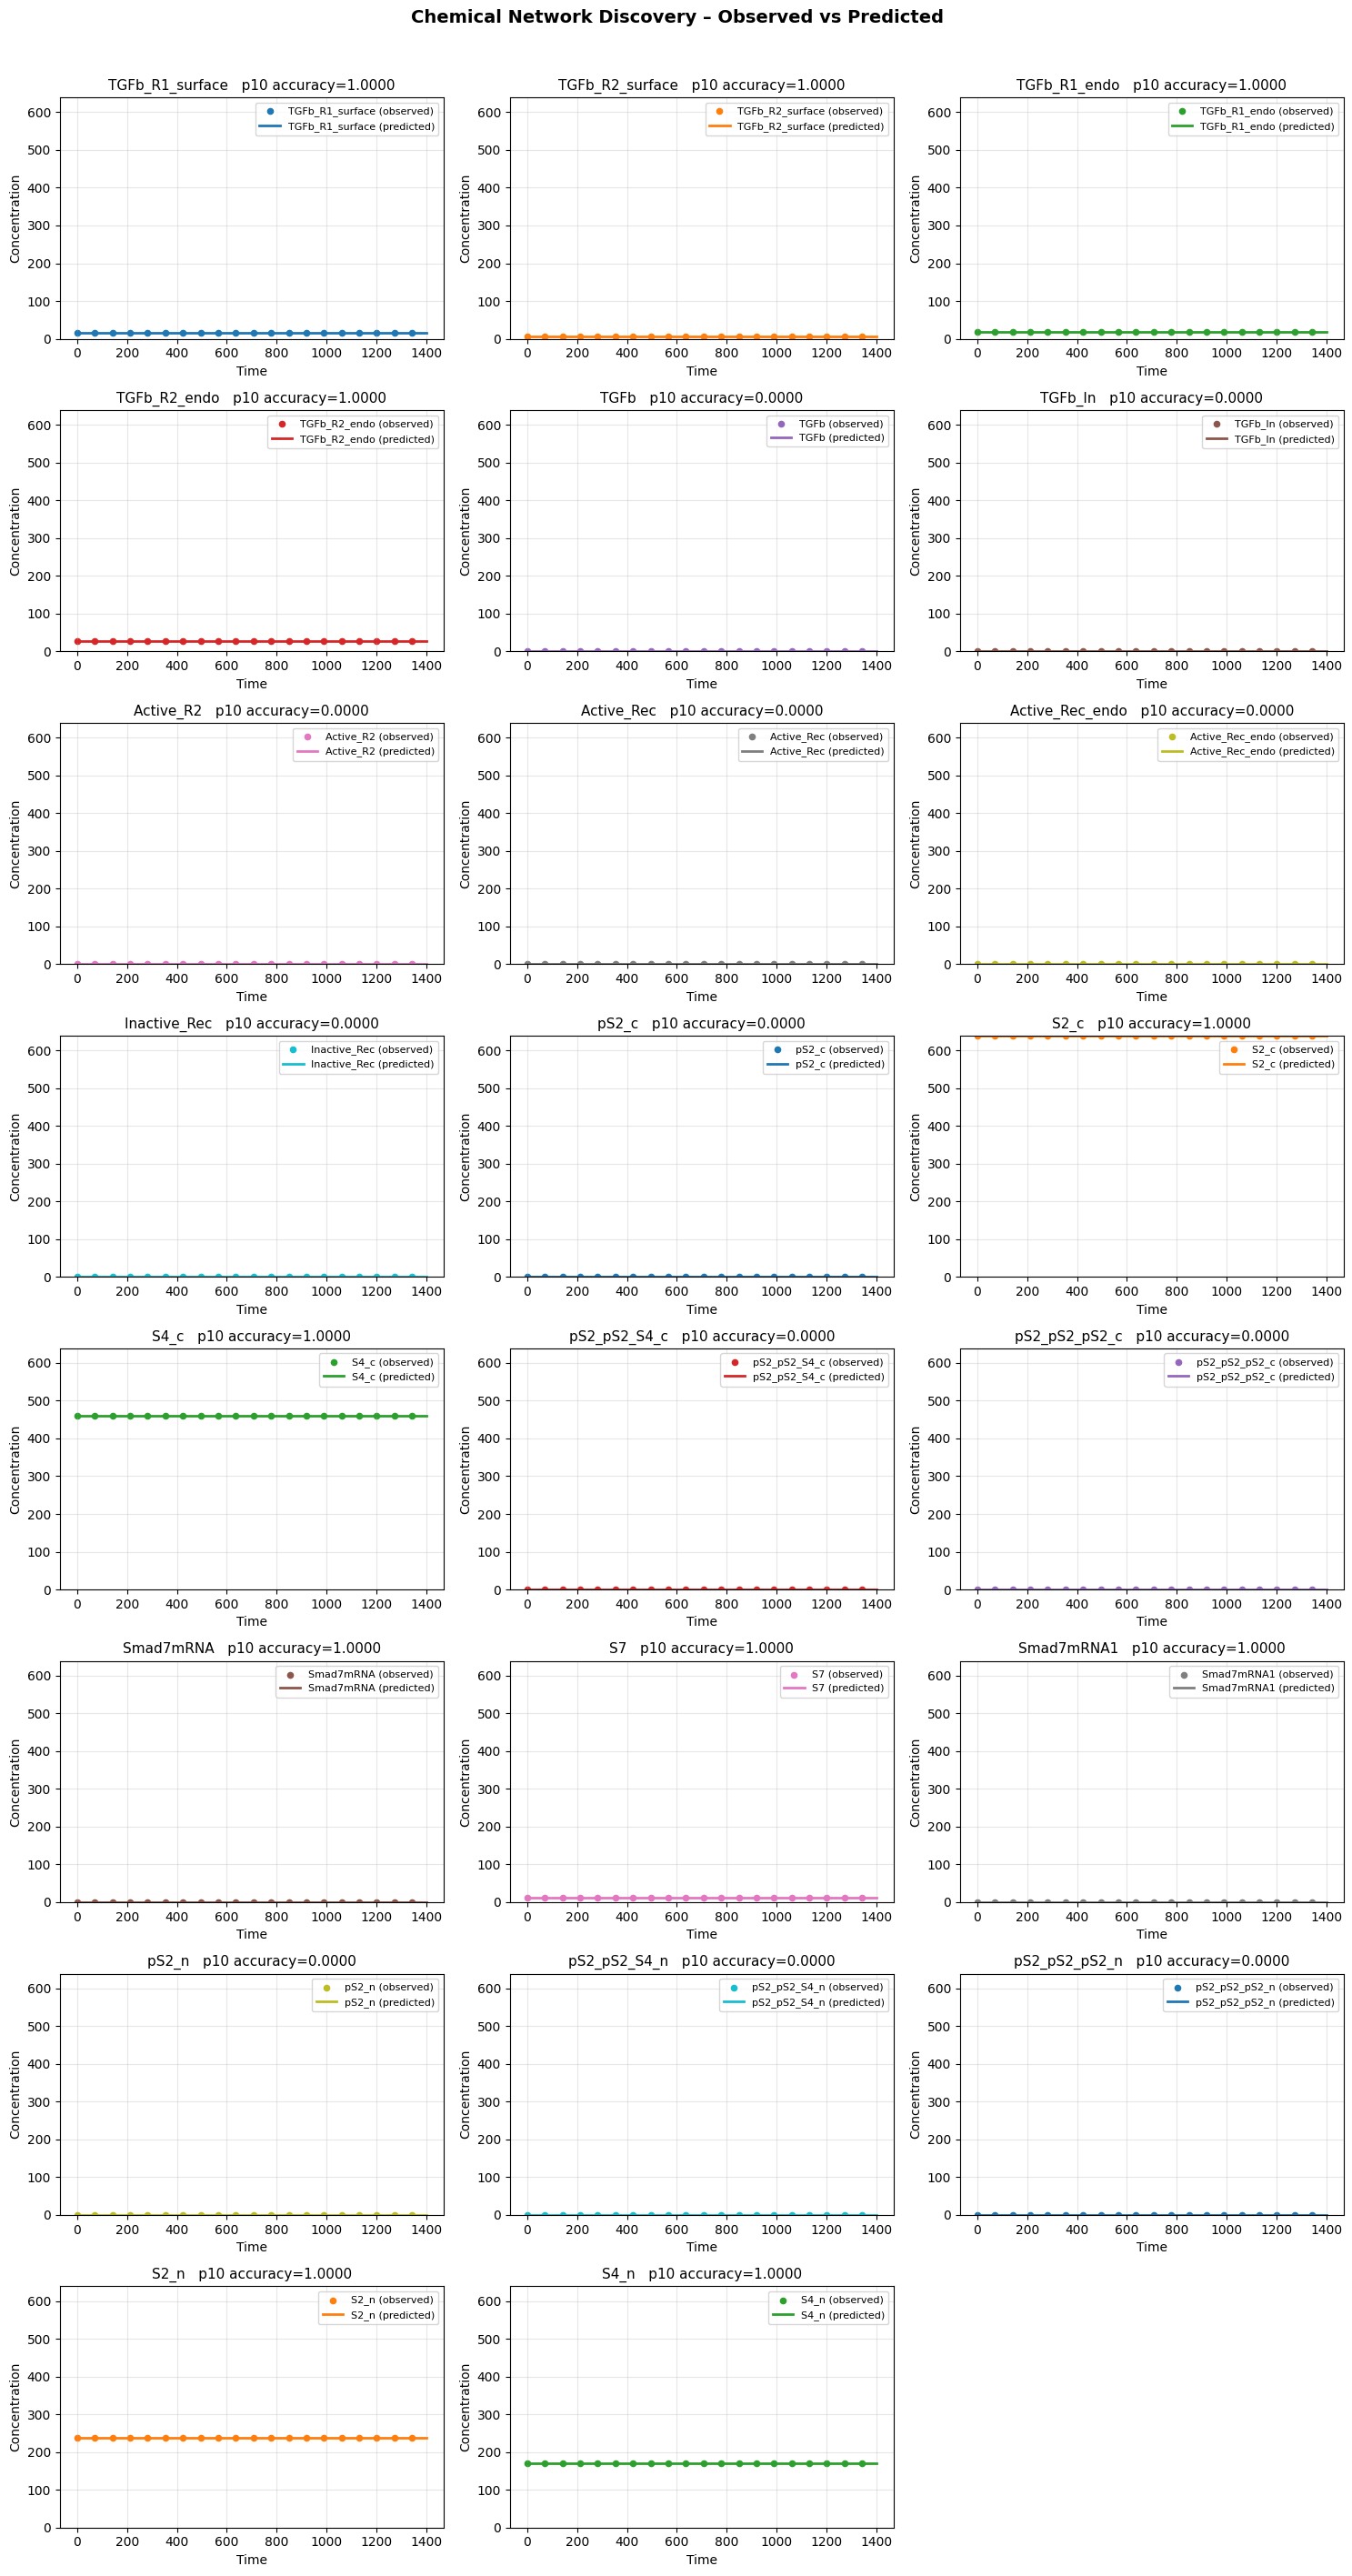

BIOMD0000001030

Poly_degree: 1, threshold: 0.001


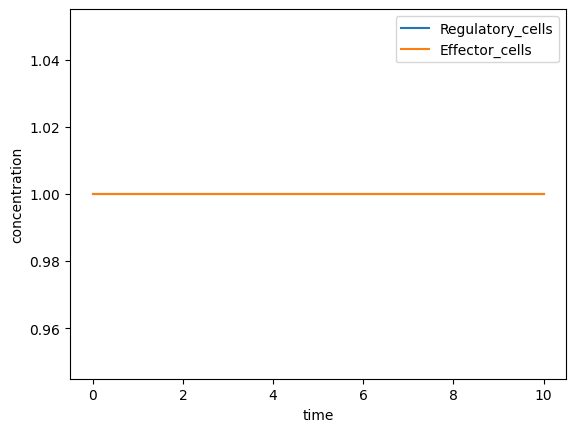

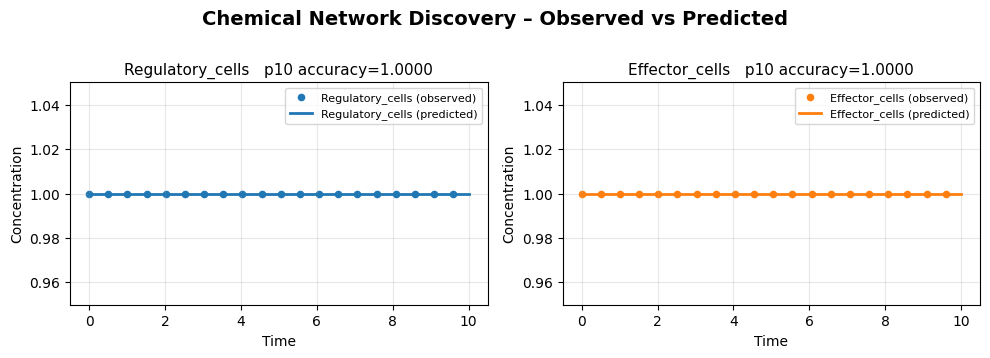

BIOMD0000001031

Poly_degree: 1, threshold: 0.001


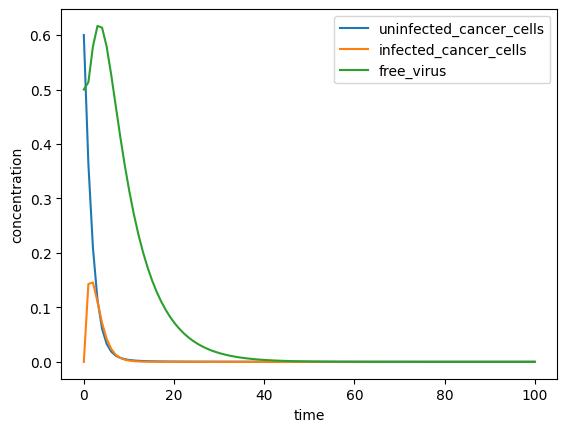

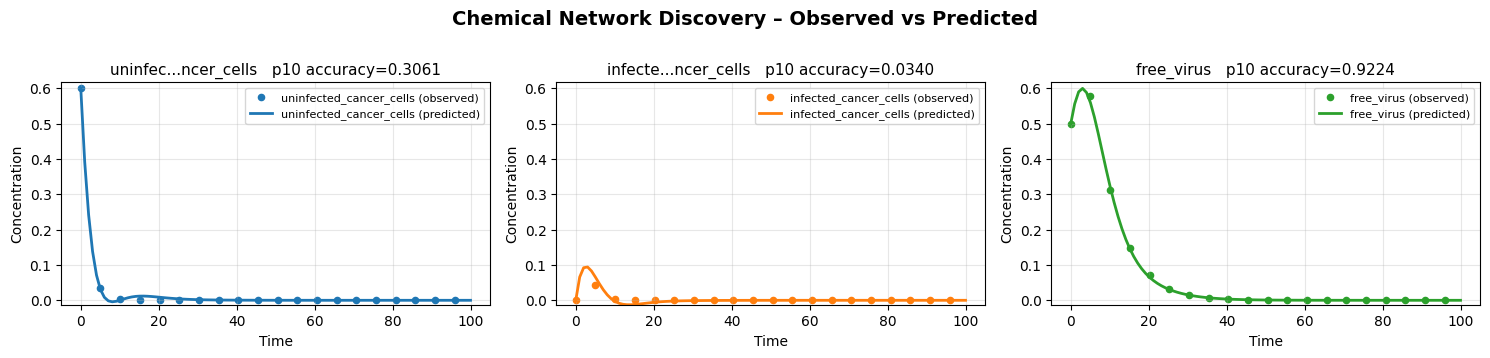

BIOMD0000001055

Poly_degree: 1, threshold: 0.001


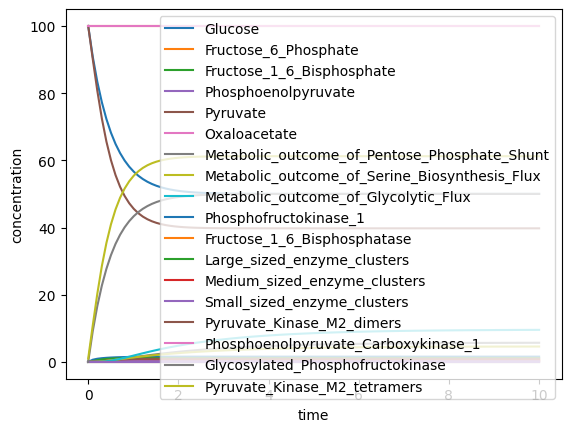

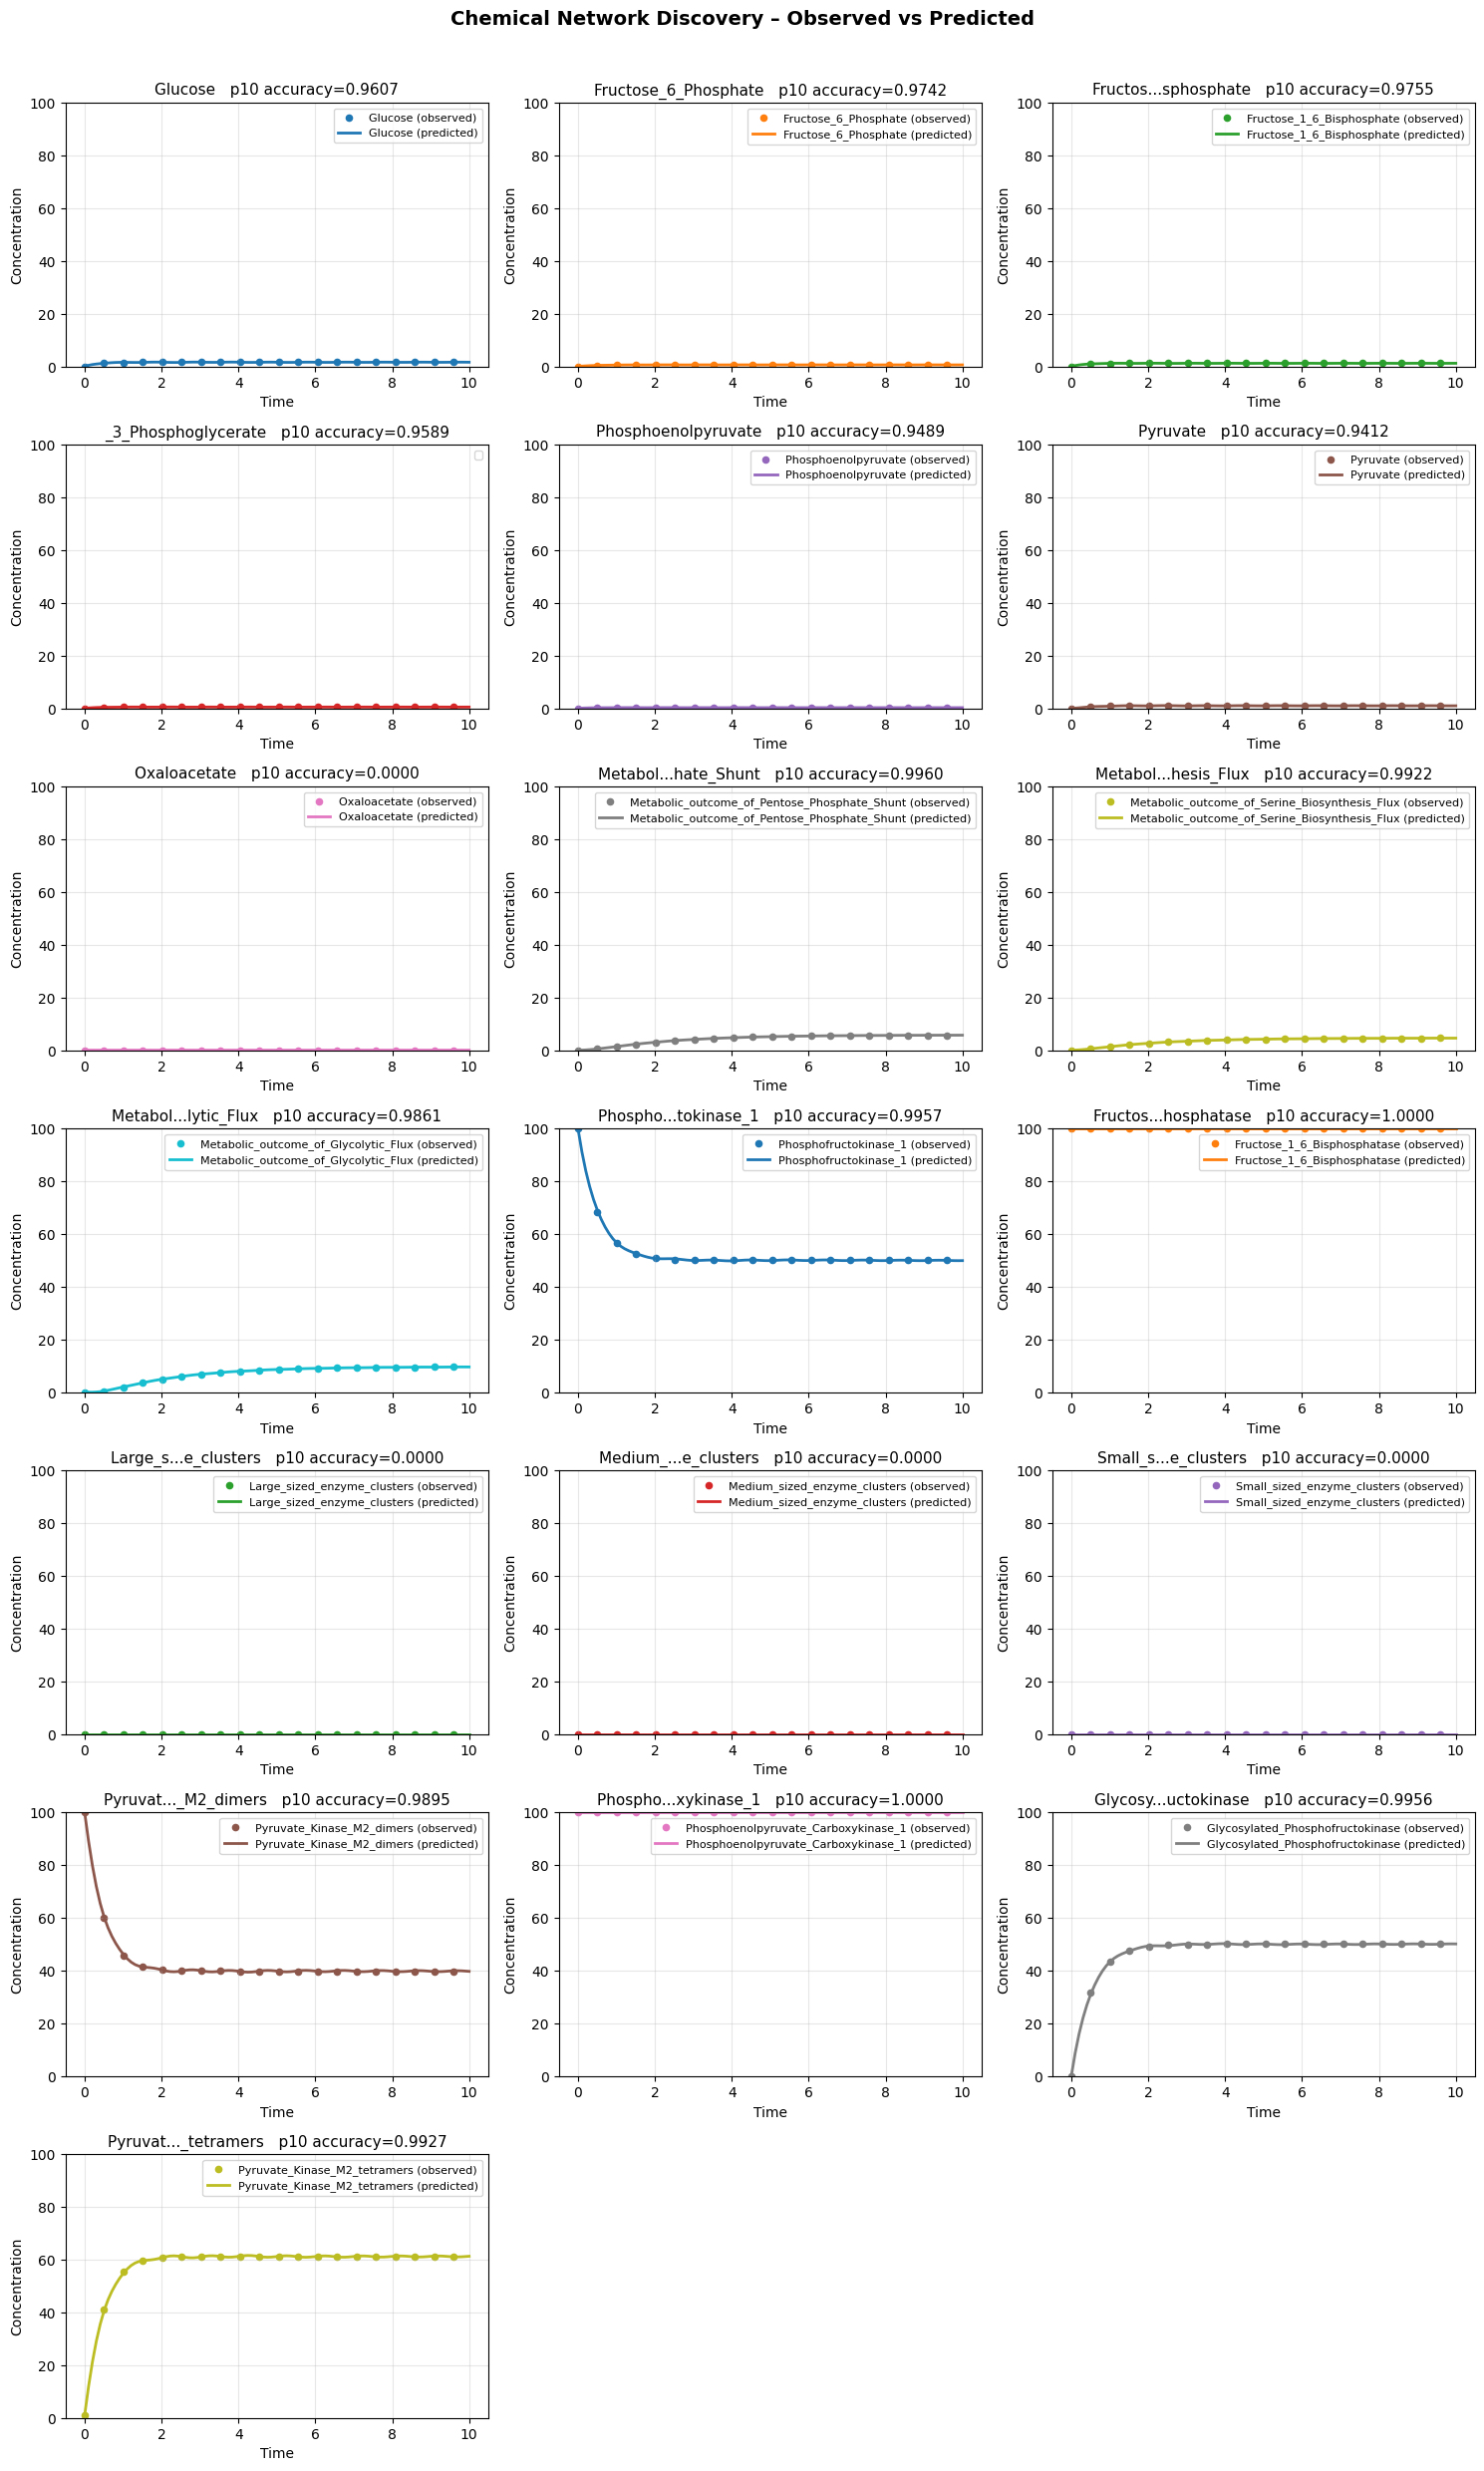

In [16]:
sel_model = SCORE_DF["aggregation_type"] == "model"
sel = sel_model & (SCORE_DF["p10"] > 0.9 )
for model_name in SCORE_DF[sel]["system_id"]:
    model_num = int(model_name[-4:])
    print(model_name + "\n")
    try:
        checkFit(model_num, threshold=0.001)
    except Exception as e:
        print(f"{model_name}: {e}")

In [ ]:
# SAMPE
xv = np.arange(0.8, 1.2, 0.01)
plt.plot(xv, 1 - (np.abs(1 - xv))/(1 + xv))

In [ ]:
xv = np.arange(0, 4, 0.01)
rmse = 1 - np.sqrt((1 - xv)**2)/np.max(np.abs(1 - xv))
plt.plot(xv, rmse)

# Perturbations

In [ ]:
tc = TimecourseIterator.getTimecourse(677)
training_df = tc.timecourse_df
defaults = {
    "model": Model.makeBiomodel(model_num=551),
    "training_df": training_df,
    "threshold": 0.01,
    "perturbations": [0, -1, 2, 3, 5],
    "is_plot": False,
}
SystemDiscovery.analyzePerturbations(**defaults)

## BioModels 181

In [ ]:
model = Model.makeBiomodel(model_num=181)
timecourse_df = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[0.1, 0.2, 0.5],
        perturbation_species_fraction=[1.0],
        is_plot=True
        
    )
#timecourse_df

In [ ]:
model_num =206
poly_degree = 1
threshold = 0.01
value_frc = 0.0
model = Model.makeBiomodel(model_num=model_num)
base_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        end_time=1,
        perturbation_value_fraction=[0.0],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
change_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        end_time=1,
        perturbation_value_fraction=[value_frc],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
sd = discoverNetwork(base_timecourse.timecourse_df,
        test_df=change_timecourse.timecourse_df,
        poly_degree=poly_degree, 
        threshold=threshold)

# Perturbation Analysis

In [ ]:
## Single Model Analysis

In [ ]:
model_num =181
poly_degree = 1
threshold = 0.01
value_frc = 0.0
model = Model.makeBiomodel(model_num=model_num)
base_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[0.0],
        perturbation_species_fraction=[1.0],
        is_plot=False
        
    )[0]
change_timecourse = Timecourse.makeTimecourses(
        model, num_point=1000,
        perturbation_value_fraction=[value_frc],
        perturbation_species_fraction=[1.0],
        is_plot=False)[0]
training_df = base_timecourse.timecourse_df
test_df = change_timecourse.timecourse_df    
SystemDiscovery.analyzePerturbations(model, training_df, threshold=threshold,
                    perturbations=[0.0, 0.05, 0.1, 0.2, 0.5])

## Multiple Model Analysis

In [ ]:
path = os.path.join(cn.DATA_DIR, "perturbation_study-0.01.csv")
PERTURBATION_DF = pd.read_csv(path)
PERTURBATION_DF.head()

In [ ]:
def plotPerturbationCDF(df: pd.DataFrame, r2_type:str = "med",
        ax=plt.gca(), is_plot: bool=True):
    """
    Plot CDFs for the changes present in the perturbation study.

    Args:
        df (pd.DataFrame): The DataFrame containing the perturbation data.
        r2_type (str, optional): _description_. Defaults to "med".
    """
    if not r2_type in ["med", "max", "min"]:
        raise ValueError("r2_type must be 'med', 'max', or 'min'")
    columns = [c for c in df.columns if r2_type in c]
    perturbation_column_dct = {c: c[3:-4] for c in columns}
    perturbation_value_dct = {perturbation_column_dct[c]: 
            df[c].sort_values().values for c in columns}
    length = len(df)
    frac_arr = np.arange(1, length + 1) / length
    for perturbation, values in perturbation_value_dct.items():
        if ax is None:
            plt.plot(values, frac_arr, label=perturbation) # type: ignore
        else:
            ax.plot(values, frac_arr, label=perturbation) # type: ignore
    ax.set_xlabel("r2")
    ax.set_ylabel("Cumulative Probability")
    ax.set_title("Perturbation CDF: " + r2_type)
    ax.legend()
    if is_plot:
        plt.show()

plotPerturbationCDF(PERTURBATION_DF, "min")

In [ ]:
def plotAllPerturbationCDFs(threshold: float=0.01, is_plot: bool=True):
    # Constrct the dataframe
    path = os.path.join(cn.DATA_DIR, "perturbation_study-" + str(threshold) + ".csv")
    df = pd.read_csv(path)
    # Create a 1 by 3 subplot for each r2 type
    if not is_plot:
        return
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for r2_type in ["min", "med", "max"]:
        plotPerturbationCDF(df, r2_type, ax=axes[["min", "med", "max"].index(r2_type)],
                is_plot=False)
        axes[["min", "med", "max"].index(r2_type)].set_title(f"R² {r2_type.capitalize()}")
    if not is_plot:
        return
    plt.show()

plotAllPerturbationCDFs(threshold=0.01)

In [ ]:
for threshold in [0.1, 0.01, 0.001]:
    _ = plt.figure()
    _ = plotAllPerturbationCDFs(threshold=0.01)

In [ ]:
PATH = "/Users/jlheller/home/Technical/repos/SBMLModel/data/BIOMD0000000680.xml"
rr = te.loadSBMLModel(PATH)
rr.simulate(0, 20, 200)
rr.plot()

# Notes

1. Annotate plot with R2 from predicted vs. actual
2. Do quality of fit analysis for just SEDML systems
3. Score values are not consistent with visuals.
4. Many of the supposedly linear models are unstable.
5. Use ARE for plot titles?
6. Key concerns: (a) better metrics so pictures look good with metric; (b) deep dive on unstable systems to beter assess fit qualities
7. Direction. Few models are linear across their entire dynamics. Find regions of linearity.